# Dise?o ?ptimo de campa?a experimental extendida

Este notebook documenta la extensi?n del modelo de fermentaci?n y el dise?o de una campa?a experimental de hasta 9 fermentaciones usando herramientas de `pyomo.contrib.doe`.

La campa?a parte desde el modelo reducido/identificable actual, pero extiende el espacio experimental con:

- composici?n de mosto sint?tico: `G0`, `F0`, `N0`, `E0`, `X0`;
- perfiles din?micos de temperatura por setpoints;
- pulsos de `N`, `G`, `F`, `E` y biomasa viable `X`;
- nuevo estado de biomasa no viable/muerta `Xd`;
- nuevo estado acumulado `CO2`, compatible con sensor online.

La selecci?n final se obtiene con un screening FIM de Pyomo DoE y una selecci?n greedy multi-experimento. Los resultados num?ricos fueron generados por `run_extended_campaign_doe.py`; este notebook deja el paso a paso y permite relanzar el an?lisis si se cambian hip?tesis operacionales.

## 1. Modelo base y motivaci?n

El modelo reducido actualmente aceptado estima siete par?metros:

\[
\theta_7 = \{\mu_0, q_N, \beta_{G0}, \beta_{F0}, q_{EG}, q_{EF}, i_G\}
\]

El diagn?stico previo dej? fijos:

\[
\{s_N, q_{XG}, q_{XF}, s_G, s_F, i_E, K_{d0}, m_0\}
\]

El objetivo de esta campa?a no es solo mejorar ajuste, sino **aumentar la cantidad de par?metros liberables**. Por eso el DOE extendido eval?a el vector completo efectivo:

\[
\theta_{15} = \{\mu_0, s_N, q_N, q_{XG}, q_{XF}, \beta_{G0}, s_G, \beta_{F0}, s_F, q_{EG}, q_{EF}, i_G, i_E, K_{d0}, m_0\}
\]

La idea es usar los ensayos hist?ricos como informaci?n previa y dise?ar fermentaciones nuevas que rompan las colinealidades actuales.

## 2. Extensi?n de estados

El modelo hist?rico trabaja con biomasa viable `X` solamente. Para poder identificar muerte/decaimiento se agrega biomasa no viable:

\[
\frac{dX}{dt} = (\mu - K_d)X + u_X(t)
\]

\[
\frac{dX_d}{dt} = K_d X
\]

Esto convierte `Kd0` desde una p?rdida invisible de biomasa viable hacia un flujo observable `X -> Xd`.

Tambi?n se agrega un estado acumulado de CO2:

\[
\frac{dCO_2}{dt} = \frac{44.01}{46.07}(\beta_G + \beta_F)X
\]

La raz?n `44.01/46.07` aproxima la conversi?n m?sica entre etanol producido y CO2 producido. Revis? `Zenteno_2010.pdf`: el art?culo incluye una capa de CO2 m?s rica, con producci?n asociada a crecimiento/fermentaci?n y transferencia gas-l?quido/saturaci?n. En este screening uso CO2 acumulado como surrogate conservador para dise?o FIM. Si el sensor entrega flujo gaseoso online, el paso siguiente es reemplazar esta salida por una capa de lectura tipo Zenteno antes de la calibraci?n final.

## 3. Inputs manipulables

Para cada fermentaci?n candidata se definen:

- setpoints de temperatura en 4 segmentos;
- condiciones iniciales `X0`, `N0`, `G0`, `F0`, `E0`, `Xd0`;
- pulsos gaussianos de ancho 3 h para `N`, `G`, `F`, `E` y `X`.

Cada pulso se representa como:

\[
u_j(t) = \sum_p a_{j,p}\,\frac{\exp[-((t - \tau_{j,p})/w)^2]}{\int \exp[-((t - \tau_{j,p})/w)^2]dt}
\]

con `j` en `{N, G, F, E, X}`. En el screening, los tiempos y dosis de cada candidato se fijan, y Pyomo DoE calcula la FIM para ese protocolo.

In [1]:
from pathlib import Path
import sys
import subprocess

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if ROOT.name != "pyomo-doe":
    # Ejecutar desde dentro de fermentation_model tambi?n funciona.
    ROOT = ROOT.parent
FERM = ROOT / "fermentation_model"
RESULTS = FERM / "results" / "extended_campaign_doe"
SCRIPT = FERM / "run_extended_campaign_doe.py"

sys.path.insert(0, str(FERM))
import run_extended_campaign_doe as doe

print("Runner:", SCRIPT)
print("Results:", RESULTS)

Runner: C:\Users\ctorrealba\OneDrive - Viña Concha y Toro S.A\Documentos\Doctorado\Artículos\Artículo - Estimación_dFBA\pyomo-doe\fermentation_model\run_extended_campaign_doe.py
Results: C:\Users\ctorrealba\OneDrive - Viña Concha y Toro S.A\Documentos\Doctorado\Artículos\Artículo - Estimación_dFBA\pyomo-doe\fermentation_model\results\extended_campaign_doe


## 4. Relanzar o cargar resultados

El DOE largo ya fue ejecutado. Por defecto este notebook carga CSVs existentes. Si se cambian l?mites, candidatos, intervalos de muestreo o pesos de medici?n, poner `RUN_LONG_DOE = True` para recalcular.

La llamada usa:

```bash
python fermentation_model/run_extended_campaign_doe.py --campaign-size 9
```

Internamente se usa `DesignOfExperiments.compute_FIM(method="sequential")` con diferencias finitas relativas (`step=1e-2`) y escalamiento por valor nominal del par?metro.

In [2]:
RUN_LONG_DOE = False

if RUN_LONG_DOE:
    subprocess.run([sys.executable, str(SCRIPT), "--campaign-size", "9"], cwd=str(ROOT), check=True)

selected = pd.read_csv(RESULTS / "extended_campaign_selected.csv")
ranking = pd.read_csv(RESULTS / "extended_candidate_ranking.csv")
protocols = pd.read_csv(RESULTS / "extended_campaign_protocols.csv")
pulses = pd.read_csv(RESULTS / "extended_campaign_pulses.csv")
param_reduction = pd.read_csv(RESULTS / "extended_campaign_parameter_reduction.csv")
metadata = pd.read_json(RESULTS / "extended_campaign_metadata.json", typ="series")

metadata

prior_batches                                   [25026, 25086, 25150, 25170]
campaign_size                                                              9
step                                                                    0.01
pulse_slots                                                                3
liquid_interval_h                                                       12.0
co2_interval_h                                                           6.0
parameters                 [mu0, sN, qN, qXG, qXF, betaG0, sG, betaF0, sF...
n_candidates                                                              12
n_successful_candidates                                                   12
forced_x_pulse_coverage                                                 True
dtype: object

## 5. Criterio FIM y selecci?n multi-experimento

Para cada experimento candidato `e`, Pyomo DoE entrega una matriz de informaci?n de Fisher:

\[
F_e = J_e^T W_e J_e
\]

donde `J_e` son sensibilidades de las salidas medidas respecto de par?metros efectivos y `W_e` contiene los pesos derivados de errores de medici?n.

Los ensayos hist?ricos se usan como prior:

\[
F_{prior} = \sum_{b \in \text{hist?ricos}} F_b
\]

La campa?a se construye greedily:

\[
F_k = F_{prior} + \sum_{i=1}^{k} F_{e_i}
\]

En cada paso se agrega el experimento que mejora m?s un score basado en logdet, eigenvalor m?nimo relativo y reducci?n de varianza posterior en los par?metros actualmente fijados/corregibles.

La covarianza local aproximada se estima como:

\[
\Sigma_k \approx F_k^{-1}
\]

La reducci?n de varianza para un par?metro `p` es:

\[
R_p = 1 - \frac{\Sigma_{k,pp}}{\Sigma_{prior,pp}}
\]

Este criterio no prueba identificabilidad global final; prioriza experimentos que deber?an hacer viable una recalibraci?n posterior con perfiles likelihood y chequeo Bayes/Laplace.

In [3]:
cols = [
    "campaign_order", "candidate", "family", "horizon_h", "temperature_c",
    "correctable_mean_var_reduction", "correctable_worst_var_reduction",
    "campaign_min_relative_eigenvalue", "campaign_condition_number", "rationale",
]
selected[cols]

,campaign_order,candidate,family,horizon_h,temperature_c,correctable_mean_var_reduction,correctable_worst_var_reduction,campaign_min_relative_eigenvalue,campaign_condition_number,rationale
0,1,combined_stress_long_horizon,integrated,240.0,"15, 22, 25, 18",0.721955,0.157033,0.000004,277059.647133,Broad stress/input design for integrated all-p...
1,2,fructose_rich_iG_probe,sugar_initial,192.0,"18, 20, 24, 22",0.834450,0.368519,0.000003,300801.567007,Fructose-rich must plus glucose pulse separate...
2,3,glucose_rich_growth_yield,sugar_initial,168.0,"18, 22, 24, 20",0.888583,0.452026,0.000007,153346.455873,High glucose must isolates glucose growth/ferm...
3,4,high_biomass_low_N_maintenance,maintenance,168.0,"16, 18, 20, 18",0.896305,0.457960,0.000009,111189.495897,High biomass and low N create low-growth sugar...
4,5,low_temp_growth_separation_plus_co2,legacy_plus,168.0,"15, 17, 20, 22",0.910785,0.524680,0.000011,92228.904074,"Previous robust N/T design, now measured with ..."
5,6,ethanol_pulse_death_probe,death,216.0,"20, 25, 25, 22",0.920432,0.546496,0.000010,99146.003002,Late ethanol stress with Xd observation target...
6,7,ethanol_initial_challenge,ethanol,192.0,"18, 22, 25, 22",0.927214,0.578202,0.000010,99204.995652,Initial ethanol decouples ethanol inhibition i...
7,8,glucose_pulse_after_N_depletion,pulse_separation,192.0,"17, 20, 24, 22",0.933967,0.609940,0.000012,82904.508090,Glucose pulse after likely N limitation separa...
8,9,viable_biomass_step,biomass_input,168.0,"18, 22, 22, 18",0.936081,0.618248,0.000011,87557.853440,Known viable biomass addition tests whether ra...


## 6. Lectura de la campa?a seleccionada

La campa?a final contiene 9 fermentaciones. No son 9 r?plicas de un mismo patr?n: cubren familias experimentales distintas.

- `integrated`: combina estr?s, temperatura, az?car, etanol y N.
- `sugar_initial`: mostos ricos en glucosa o fructosa para separar `qXG/qXF/sG/sF/iG`.
- `maintenance`: alta biomasa y bajo N para atacar `m0`.
- `legacy_plus`: conserva el mejor dise?o temperatura/YAN anterior, ahora con CO2 y `Xd`.
- `death/ethanol`: separa `iE` y `Kd0` usando etanol externo.
- `pulse_separation`: pulsos de az?car despu?s de limitaci?n de N para separar crecimiento vs fermentaci?n/mantenimiento.

In [4]:
protocol_cols = [
    "candidate", "family", "horizon_h", "temperature_c",
    "X0", "N0", "G0", "F0", "E0", "Xd0", "rationale",
]
protocols[protocol_cols]

,candidate,family,horizon_h,temperature_c,X0,N0,G0,F0,E0,Xd0,rationale
0,combined_stress_long_horizon,integrated,240.0,"15, 22, 25, 18",0.70,0.200,110.0,110.0,15.0,0.0,Broad stress/input design for integrated all-p...
1,fructose_rich_iG_probe,sugar_initial,192.0,"18, 20, 24, 22",0.45,0.260,25.0,150.0,0.0,0.0,Fructose-rich must plus glucose pulse separate...
2,glucose_rich_growth_yield,sugar_initial,168.0,"18, 22, 24, 20",0.45,0.260,150.0,25.0,0.0,0.0,High glucose must isolates glucose growth/ferm...
3,high_biomass_low_N_maintenance,maintenance,168.0,"16, 18, 20, 18",2.20,0.025,70.0,70.0,15.0,0.0,High biomass and low N create low-growth sugar...
4,low_temp_growth_separation_plus_co2,legacy_plus,168.0,"15, 17, 20, 22",0.55,0.240,75.0,70.0,0.0,0.0,"Previous robust N/T design, now measured with ..."
5,ethanol_pulse_death_probe,death,216.0,"20, 25, 25, 22",0.75,0.180,80.0,80.0,5.0,0.0,Late ethanol stress with Xd observation target...
6,ethanol_initial_challenge,ethanol,192.0,"18, 22, 25, 22",0.60,0.220,90.0,90.0,35.0,0.0,Initial ethanol decouples ethanol inhibition i...
7,glucose_pulse_after_N_depletion,pulse_separation,192.0,"17, 20, 24, 22",0.55,0.055,45.0,85.0,0.0,0.0,Glucose pulse after likely N limitation separa...
8,viable_biomass_step,biomass_input,168.0,"18, 22, 22, 18",0.30,0.220,90.0,90.0,0.0,0.0,Known viable biomass addition tests whether ra...


In [5]:
pulses.sort_values(["candidate", "channel", "time_h"])

,candidate,family,channel,time_h,amount
4,combined_stress_long_horizon,integrated,E,120.0,20.000
3,combined_stress_long_horizon,integrated,F,96.0,25.000
2,combined_stress_long_horizon,integrated,G,72.0,25.000
0,combined_stress_long_horizon,integrated,N,0.0,0.050
1,combined_stress_long_horizon,integrated,N,60.0,0.050
19,ethanol_initial_challenge,ethanol,N,0.0,0.070
20,ethanol_initial_challenge,ethanol,N,48.0,0.050
18,ethanol_pulse_death_probe,death,E,96.0,25.000
17,ethanol_pulse_death_probe,death,N,0.0,0.050
7,fructose_rich_iG_probe,sugar_initial,G,72.0,35.000


## 7. Par?metros esperadamente recuperables

La tabla siguiente muestra la reducci?n de varianza posterior aproximada luego de sumar los 9 experimentos al prior hist?rico. Un valor cercano a 1 indica que la campa?a agrega mucha informaci?n para ese par?metro.

Punto importante: estos son diagn?sticos locales FIM. Despu?s de ejecutar la campa?a real, hay que recalibrar y volver a correr:

1. FIM/Q sobre el nuevo dataset;
2. perfiles likelihood;
3. chequeo Bayes/Laplace con priors d?biles;
4. si procede, PSO multi-start + ajuste local.

In [6]:
param_reduction.sort_values("campaign_var_reduction", ascending=False)

,parameter,group,campaign_var_ratio,campaign_var_reduction
13,Kd0,currently_fixed_target,0.000945,0.999055
11,iG,accepted_current,0.002715,0.997285
7,betaF0,accepted_current,0.003451,0.996549
10,qEF,accepted_current,0.003569,0.996431
5,betaG0,accepted_current,0.013245,0.986755
12,iE,currently_fixed_target,0.016098,0.983902
6,sG,currently_fixed_target,0.018067,0.981933
4,qXF,currently_fixed_target,0.018446,0.981554
3,qXG,currently_fixed_target,0.018612,0.981388
9,qEG,accepted_current,0.019565,0.980435


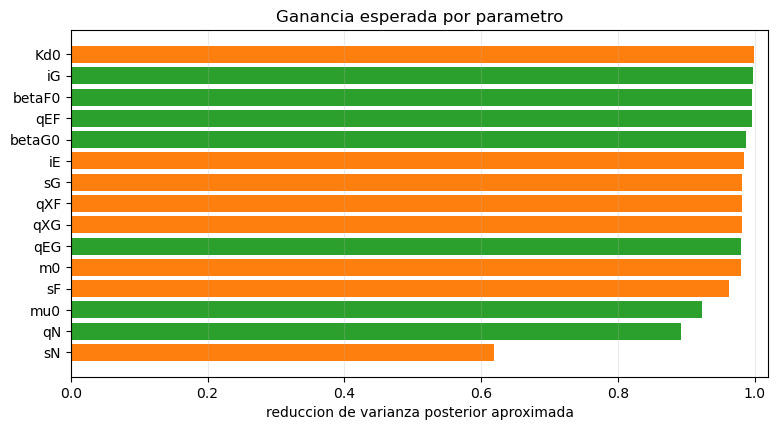

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))
plot_df = param_reduction.sort_values("campaign_var_reduction")
colors = ["tab:green" if g == "accepted_current" else "tab:orange" for g in plot_df["group"]]
ax.barh(plot_df["parameter"], plot_df["campaign_var_reduction"], color=colors)
ax.set_xlabel("reduccion de varianza posterior aproximada")
ax.set_xlim(0, 1.02)
ax.grid(axis="x", alpha=0.25)
ax.set_title("Ganancia esperada por parametro")
plt.show()

## 8. Ranking de candidatos individuales

Antes de la selecci?n greedy, cada dise?o se evalu? individualmente contra el prior hist?rico. Este ranking muestra que el mejor candidato individual no necesariamente es el noveno m?s ?til al final: la campa?a busca complementariedad, no repetir la misma direcci?n informativa.

In [8]:
ranking_cols = [
    "candidate", "family", "horizon_h", "combined_logdet",
    "combined_min_relative_eigenvalue", "combined_condition_number",
    "correctable_mean_var_reduction", "correctable_worst_var_reduction", "status",
]
ranking[ranking_cols].head(12)

,candidate,family,horizon_h,combined_logdet,combined_min_relative_eigenvalue,combined_condition_number,correctable_mean_var_reduction,correctable_worst_var_reduction,status
0,glucose_rich_growth_yield,sugar_initial,168.0,85.789812,0.000003,342880.238817,0.761066,0.332089,ok
1,fructose_rich_iG_probe,sugar_initial,192.0,86.165358,0.000004,275721.017879,0.739823,0.293045,ok
2,combined_stress_long_horizon,integrated,240.0,86.568248,0.000004,277059.647133,0.721955,0.157033,ok
3,ethanol_initial_challenge,ethanol,192.0,81.708317,0.000007,152955.240988,0.698356,0.122962,ok
4,low_temp_growth_separation_plus_co2,legacy_plus,168.0,75.404367,0.000003,330887.169195,0.570269,0.402870,ok
5,ethanol_pulse_death_probe,death,216.0,77.048902,0.000002,578929.510501,0.522228,0.072530,ok
6,viable_biomass_step,biomass_input,168.0,74.822943,0.000002,615597.855456,0.506829,0.289874,ok
7,low_sugar_saturation_scan,saturation,144.0,70.745225,0.000003,349343.338596,0.456491,0.111601,ok
8,glucose_pulse_after_N_depletion,pulse_separation,192.0,72.155918,0.000002,550862.150954,0.444821,0.057715,ok
9,high_biomass_low_N_maintenance,maintenance,168.0,74.638074,0.000002,423934.393274,0.430751,0.014466,ok


## 9. Plots de inputs manipulados

Cada figura muestra:

1. perfil de temperatura;
2. composici?n inicial;
3. pulsos de `N`, `G`, `F`, `E`, `X`.

Estas figuras son las recetas operacionales de campa?a.

extended_campaign_inputs_combined_stress_long_horizon.png


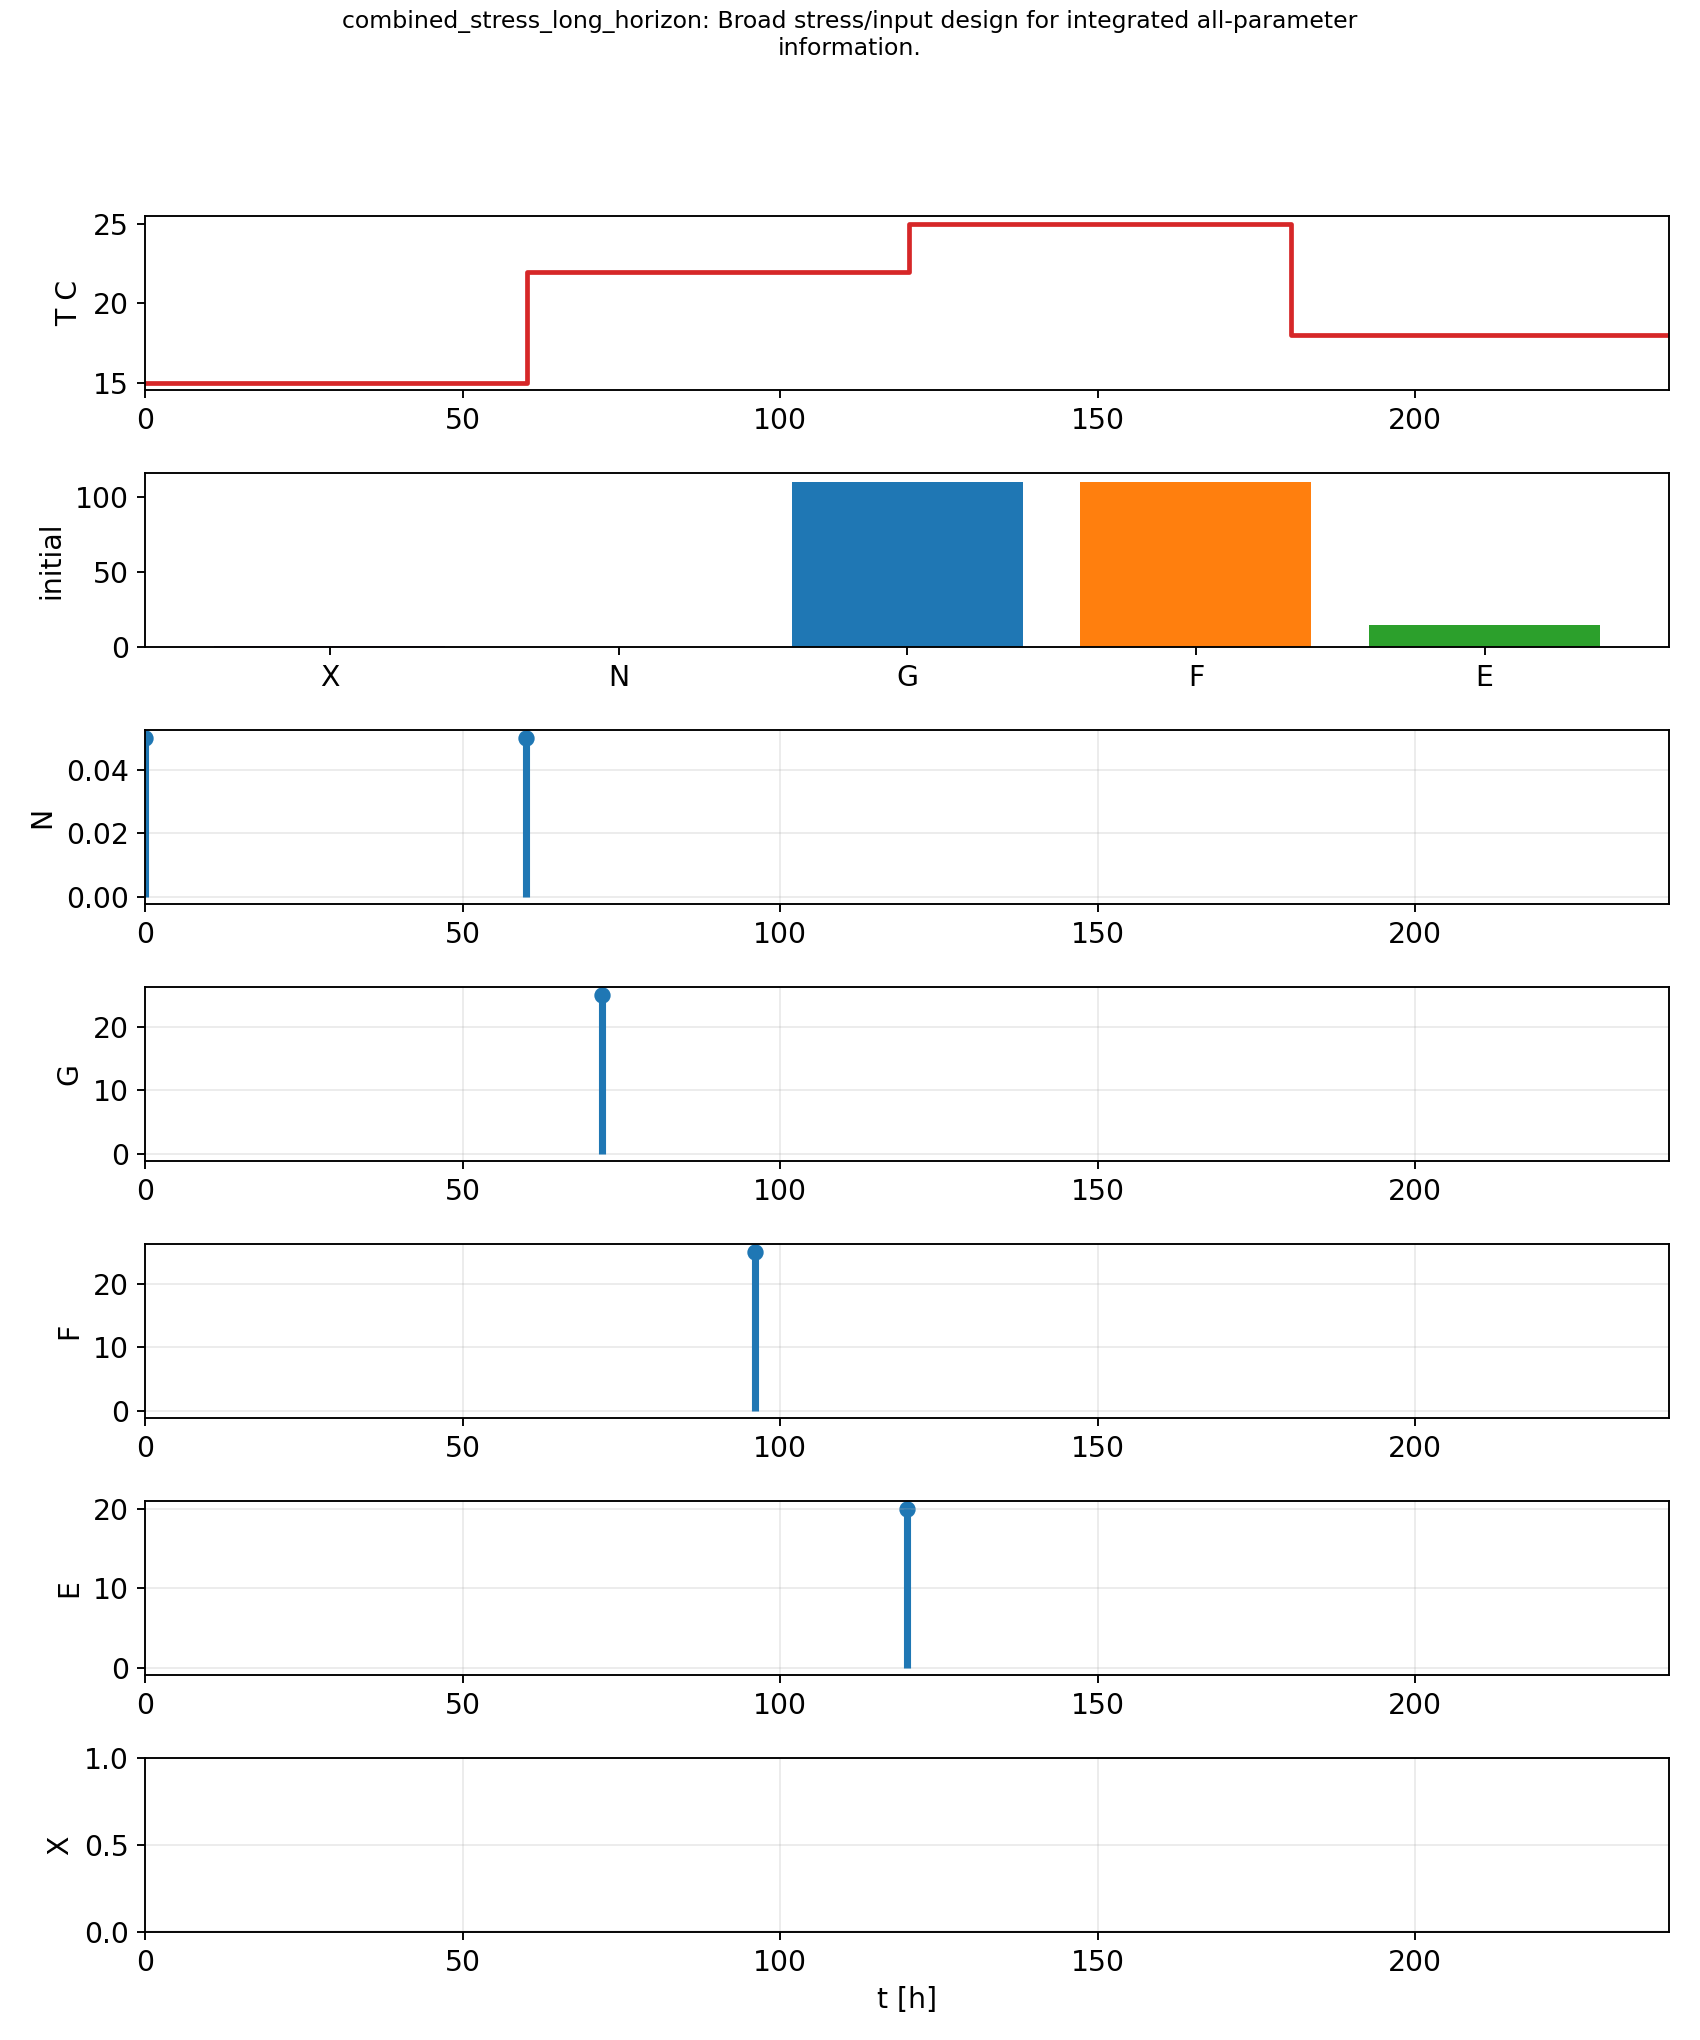

extended_campaign_inputs_fructose_rich_iG_probe.png


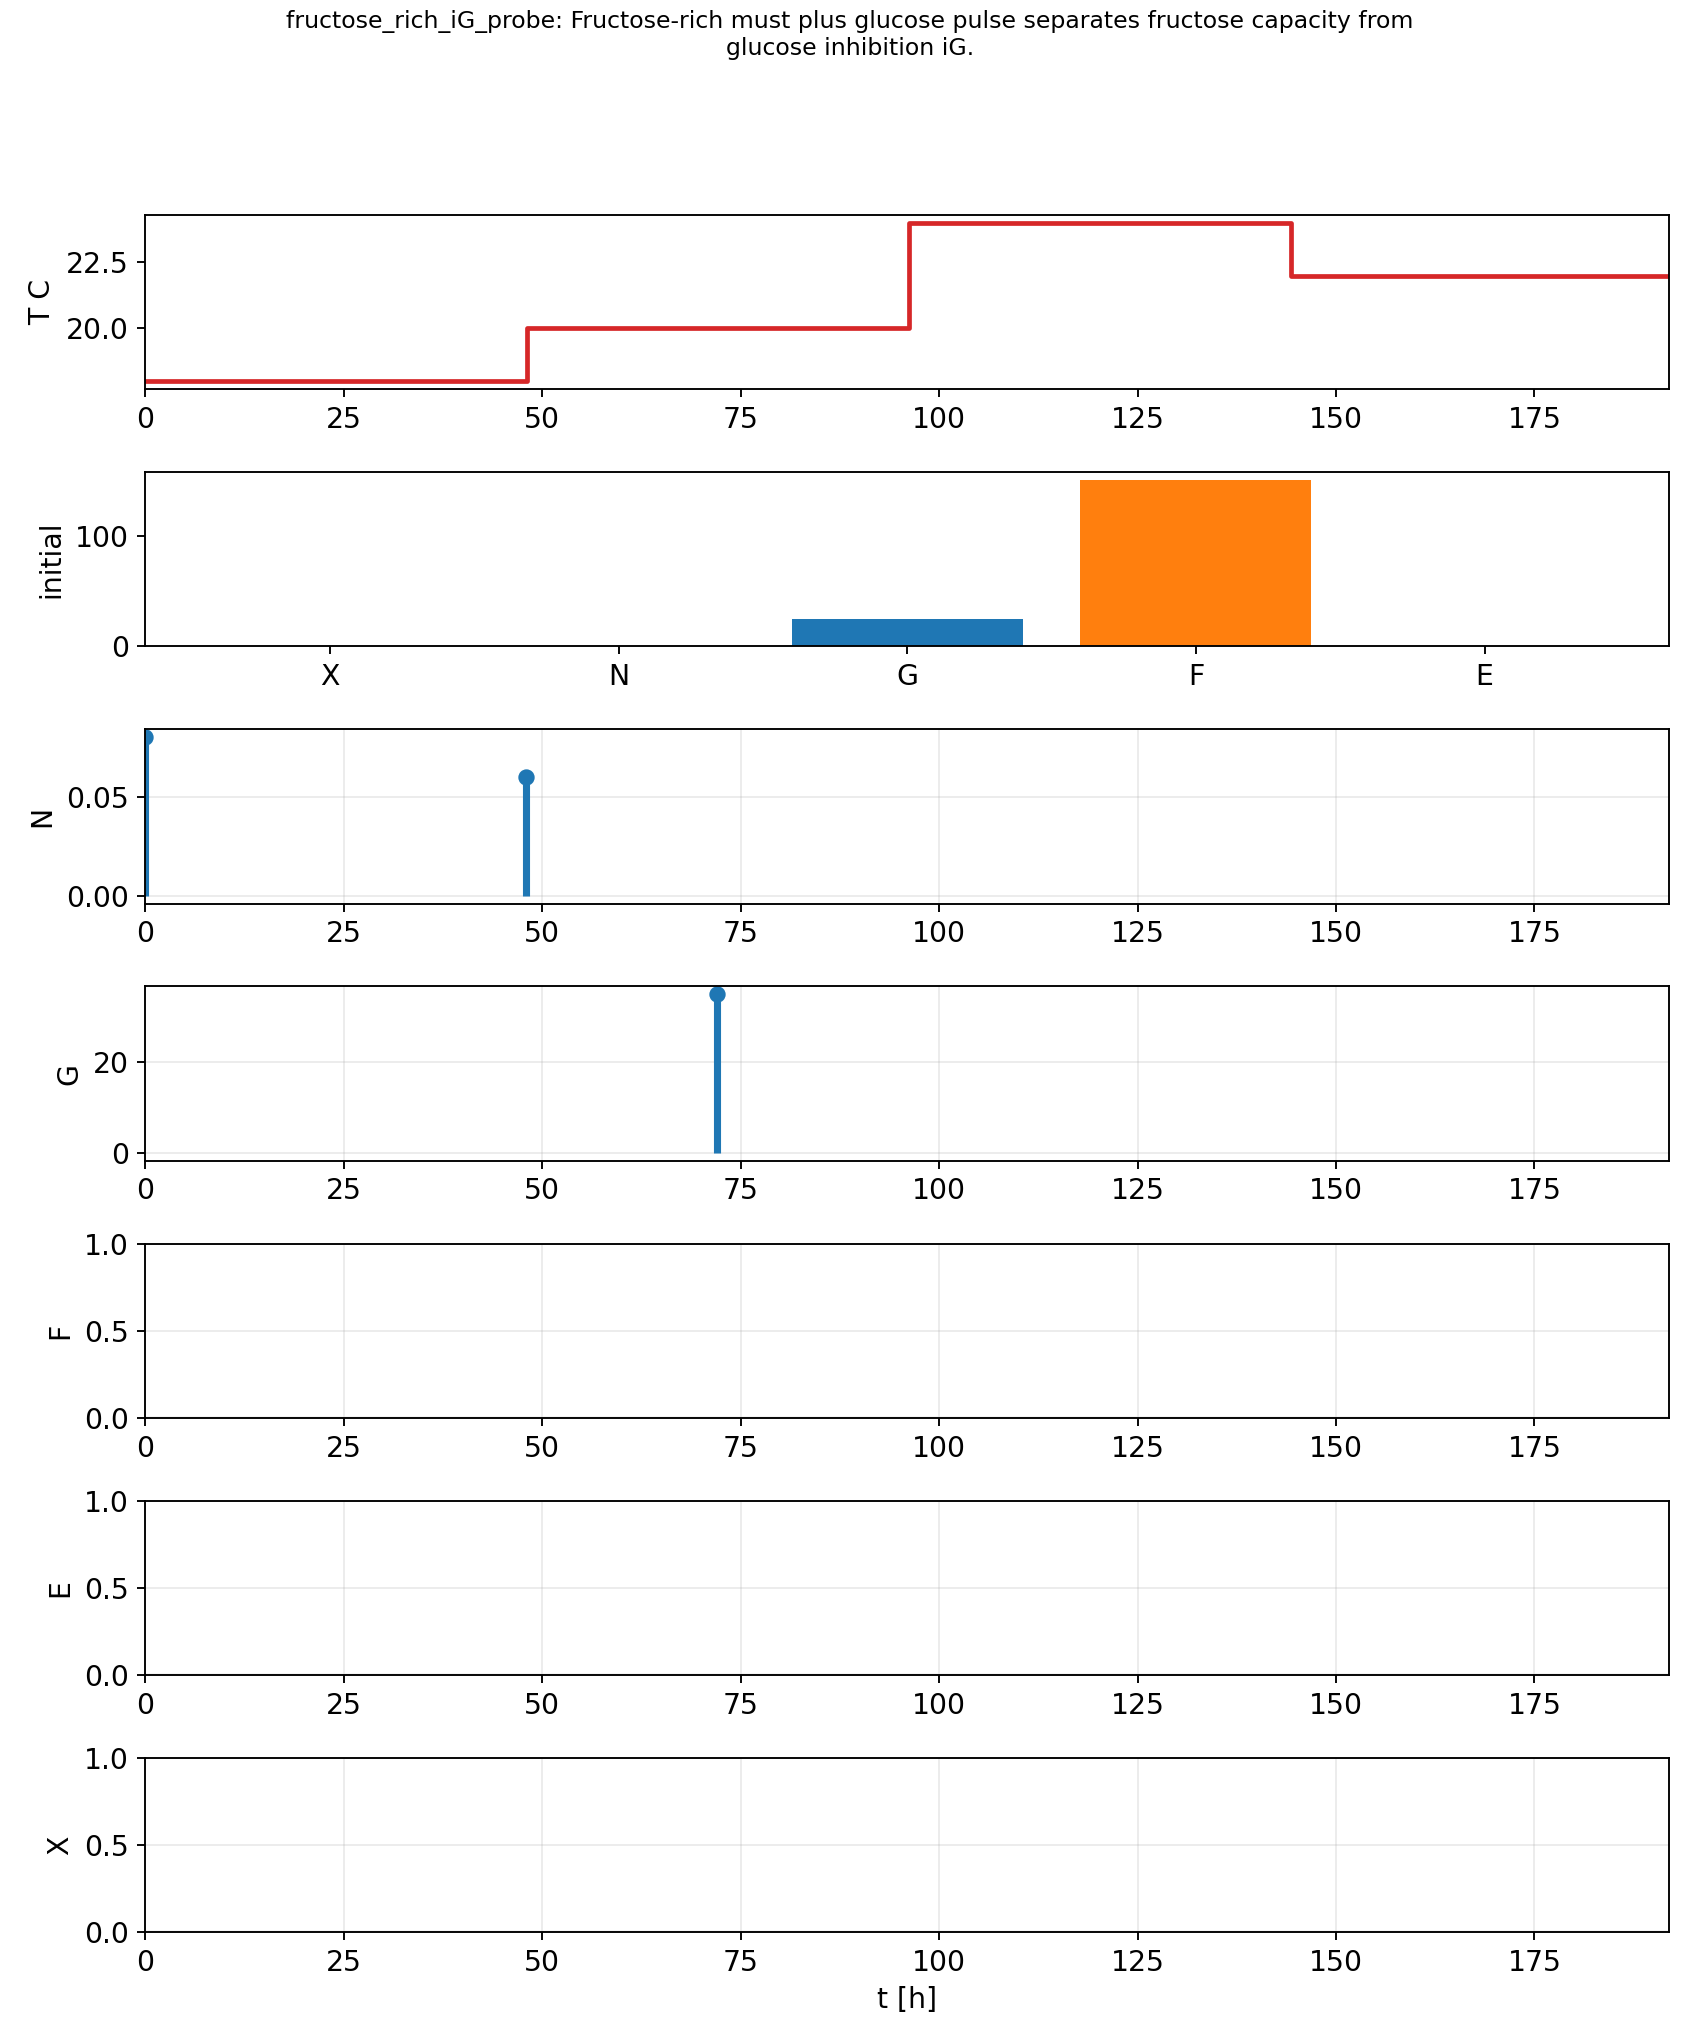

extended_campaign_inputs_glucose_rich_growth_yield.png


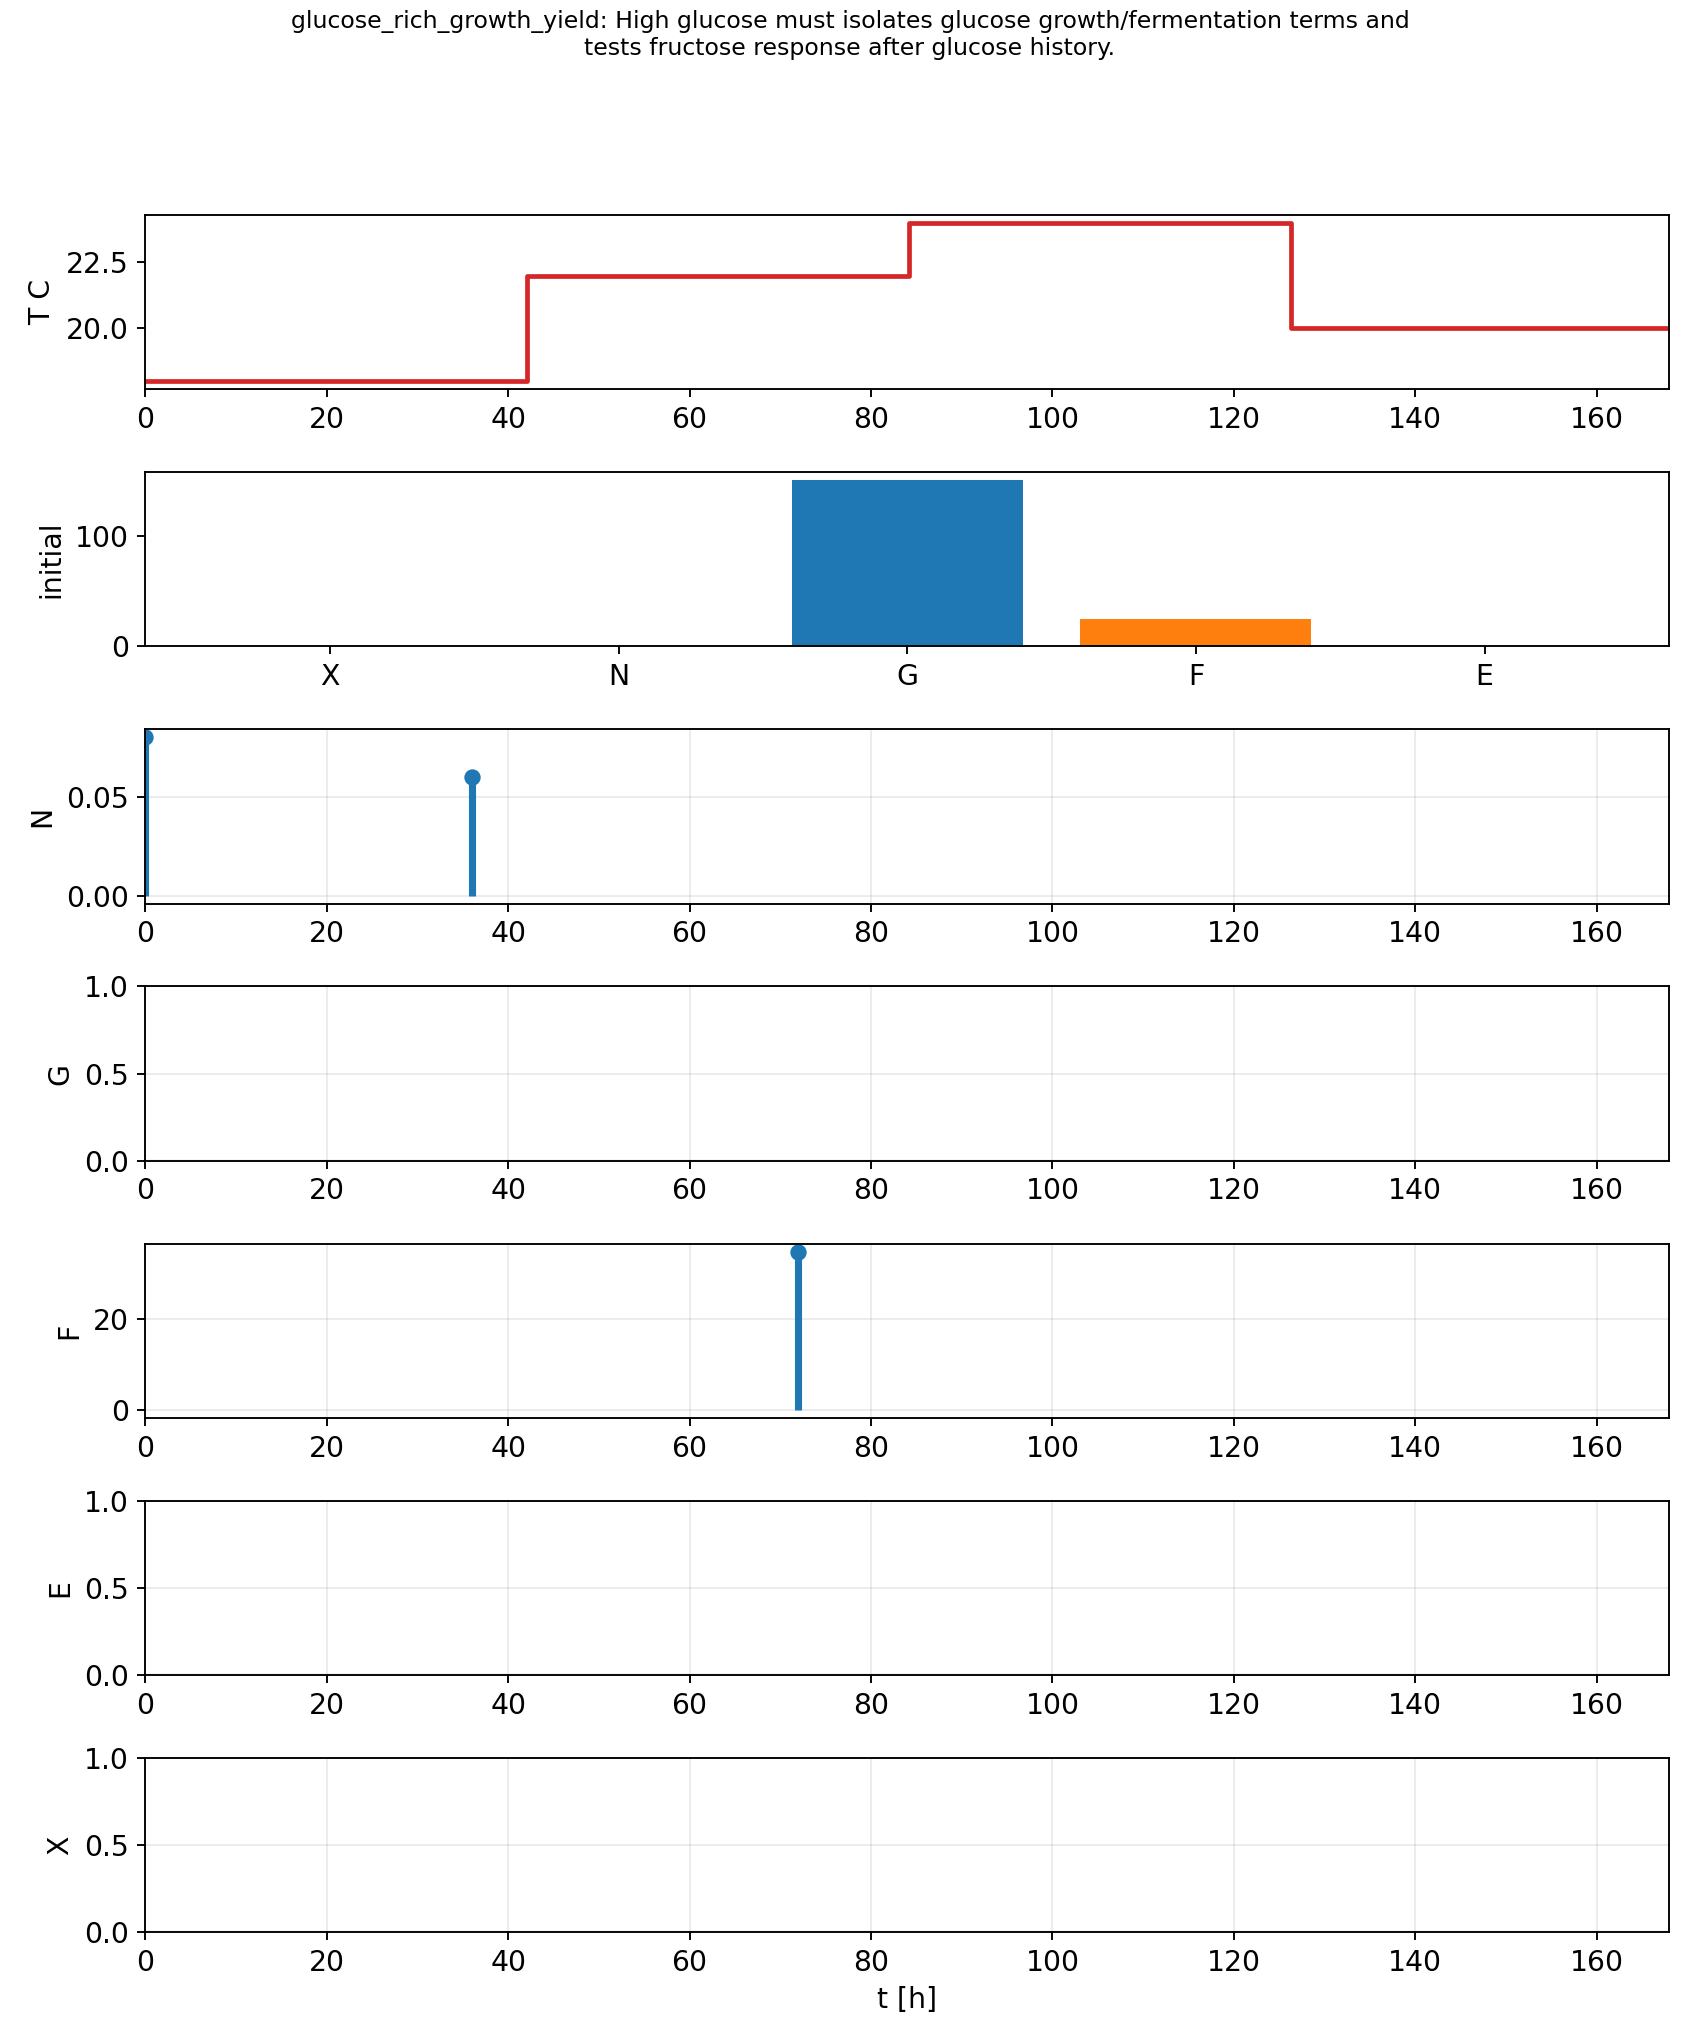

extended_campaign_inputs_high_biomass_low_N_maintenance.png


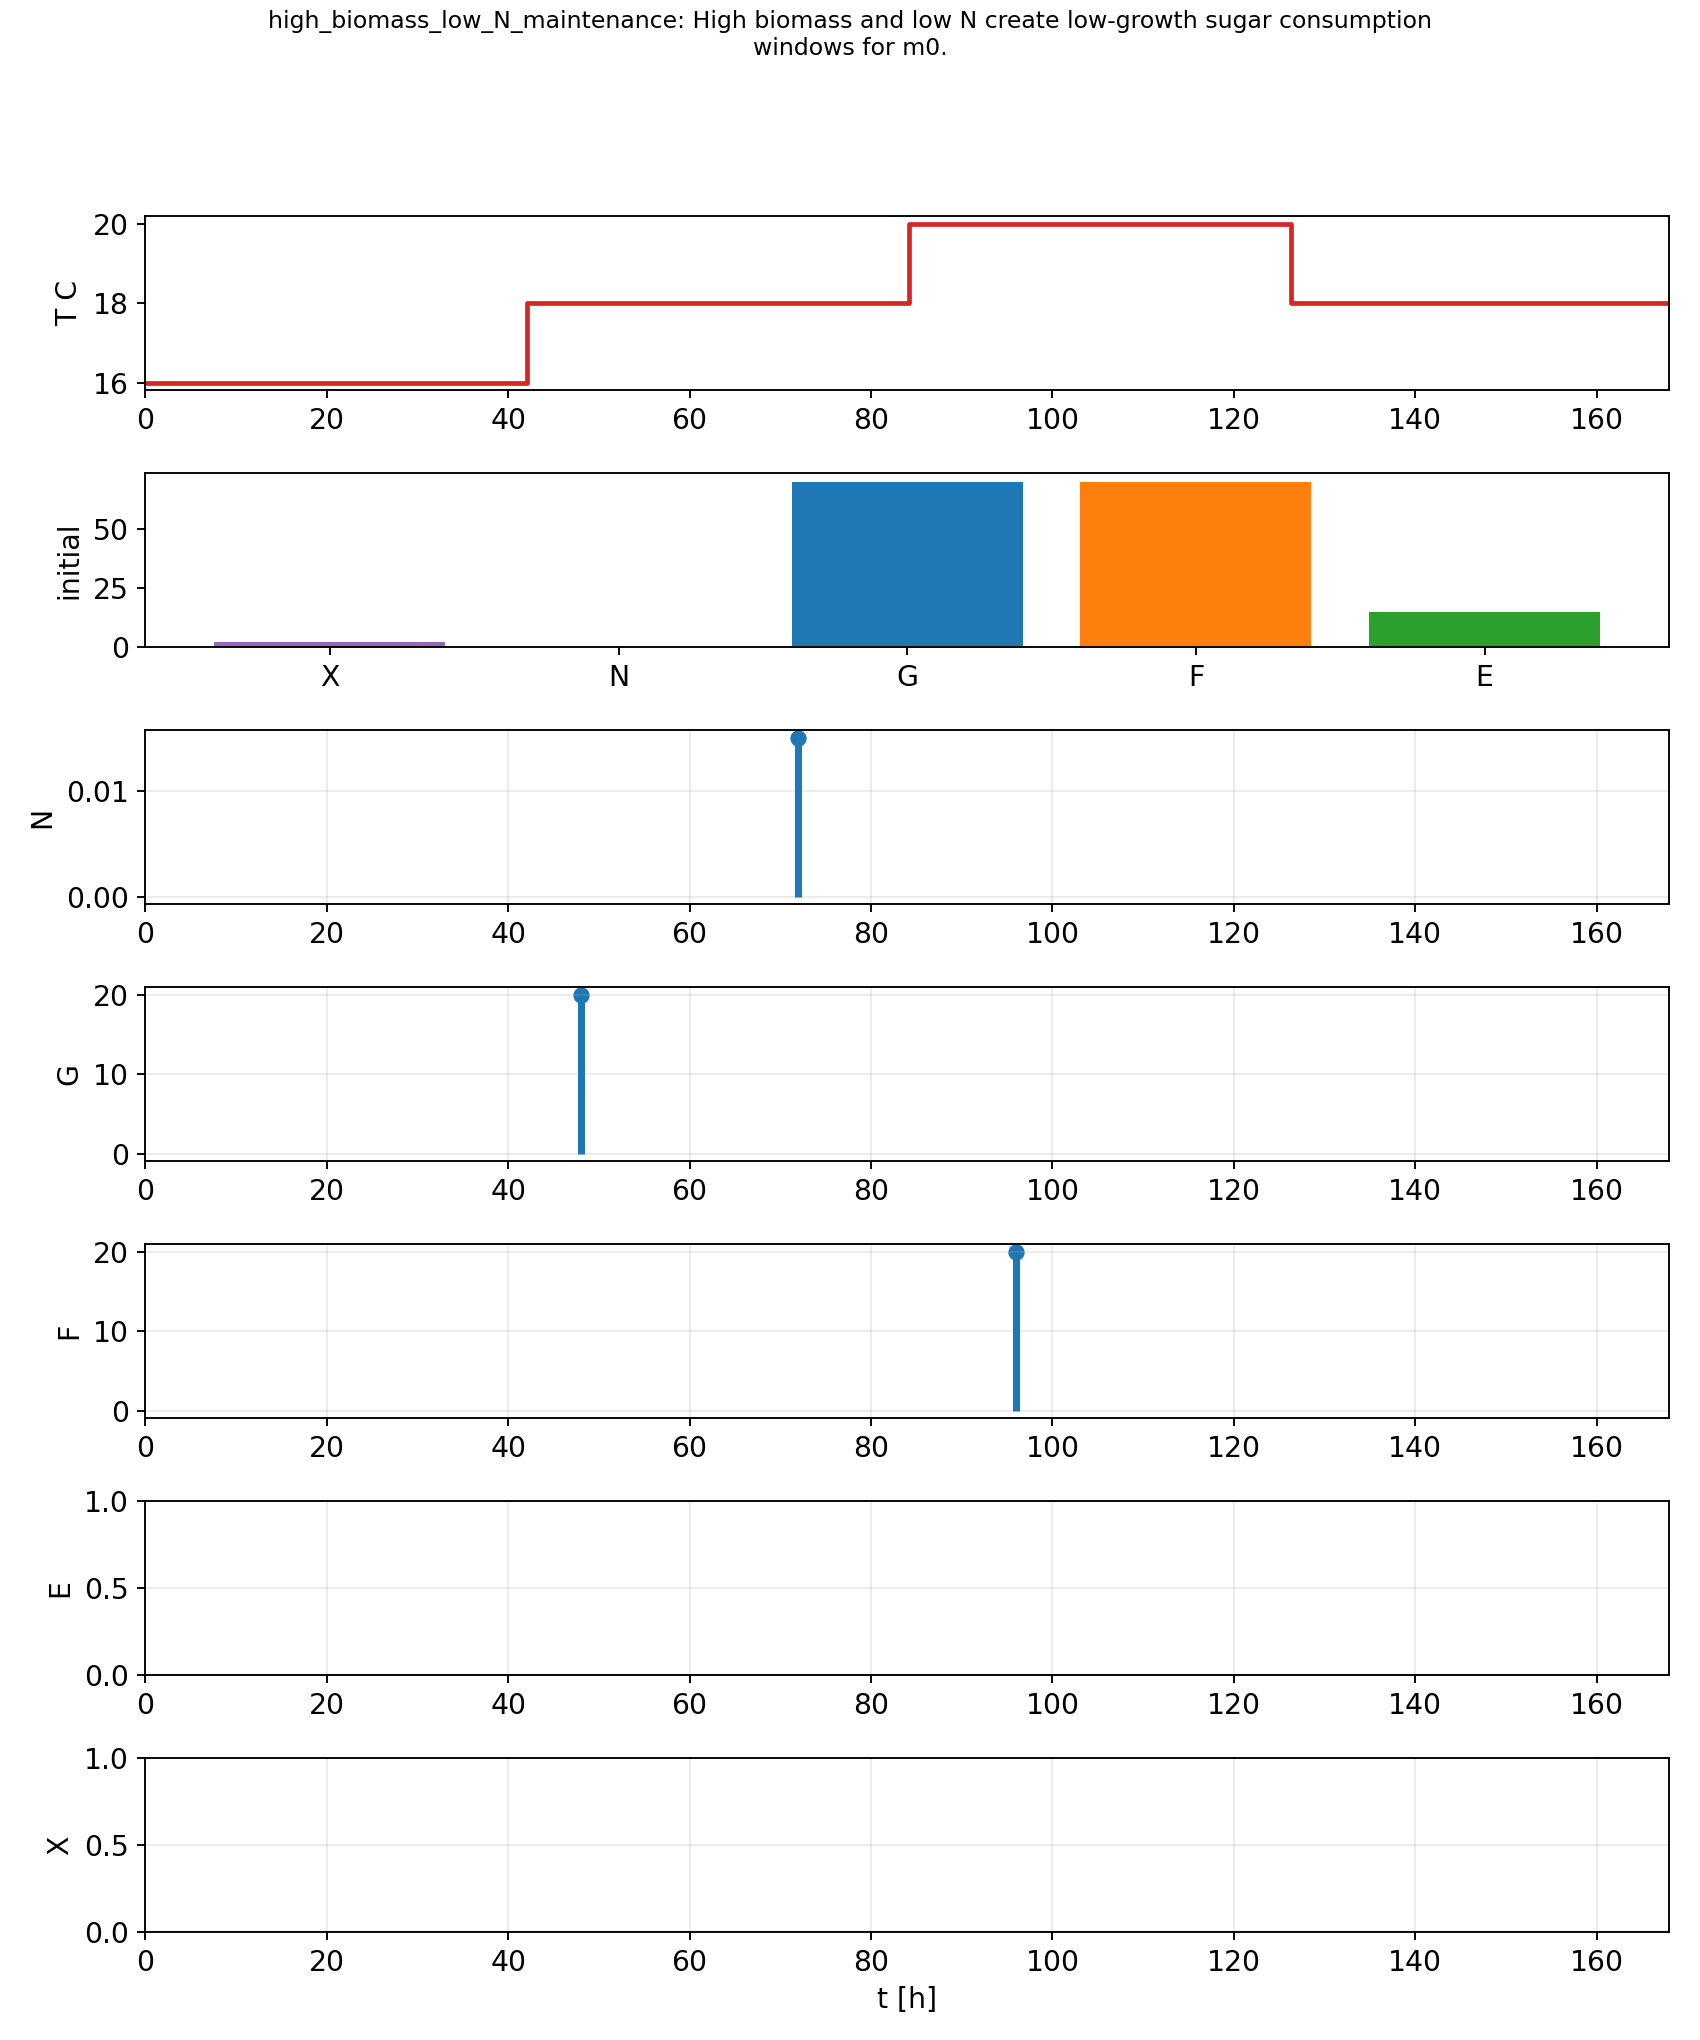

extended_campaign_inputs_low_temp_growth_separation_plus_co2.png


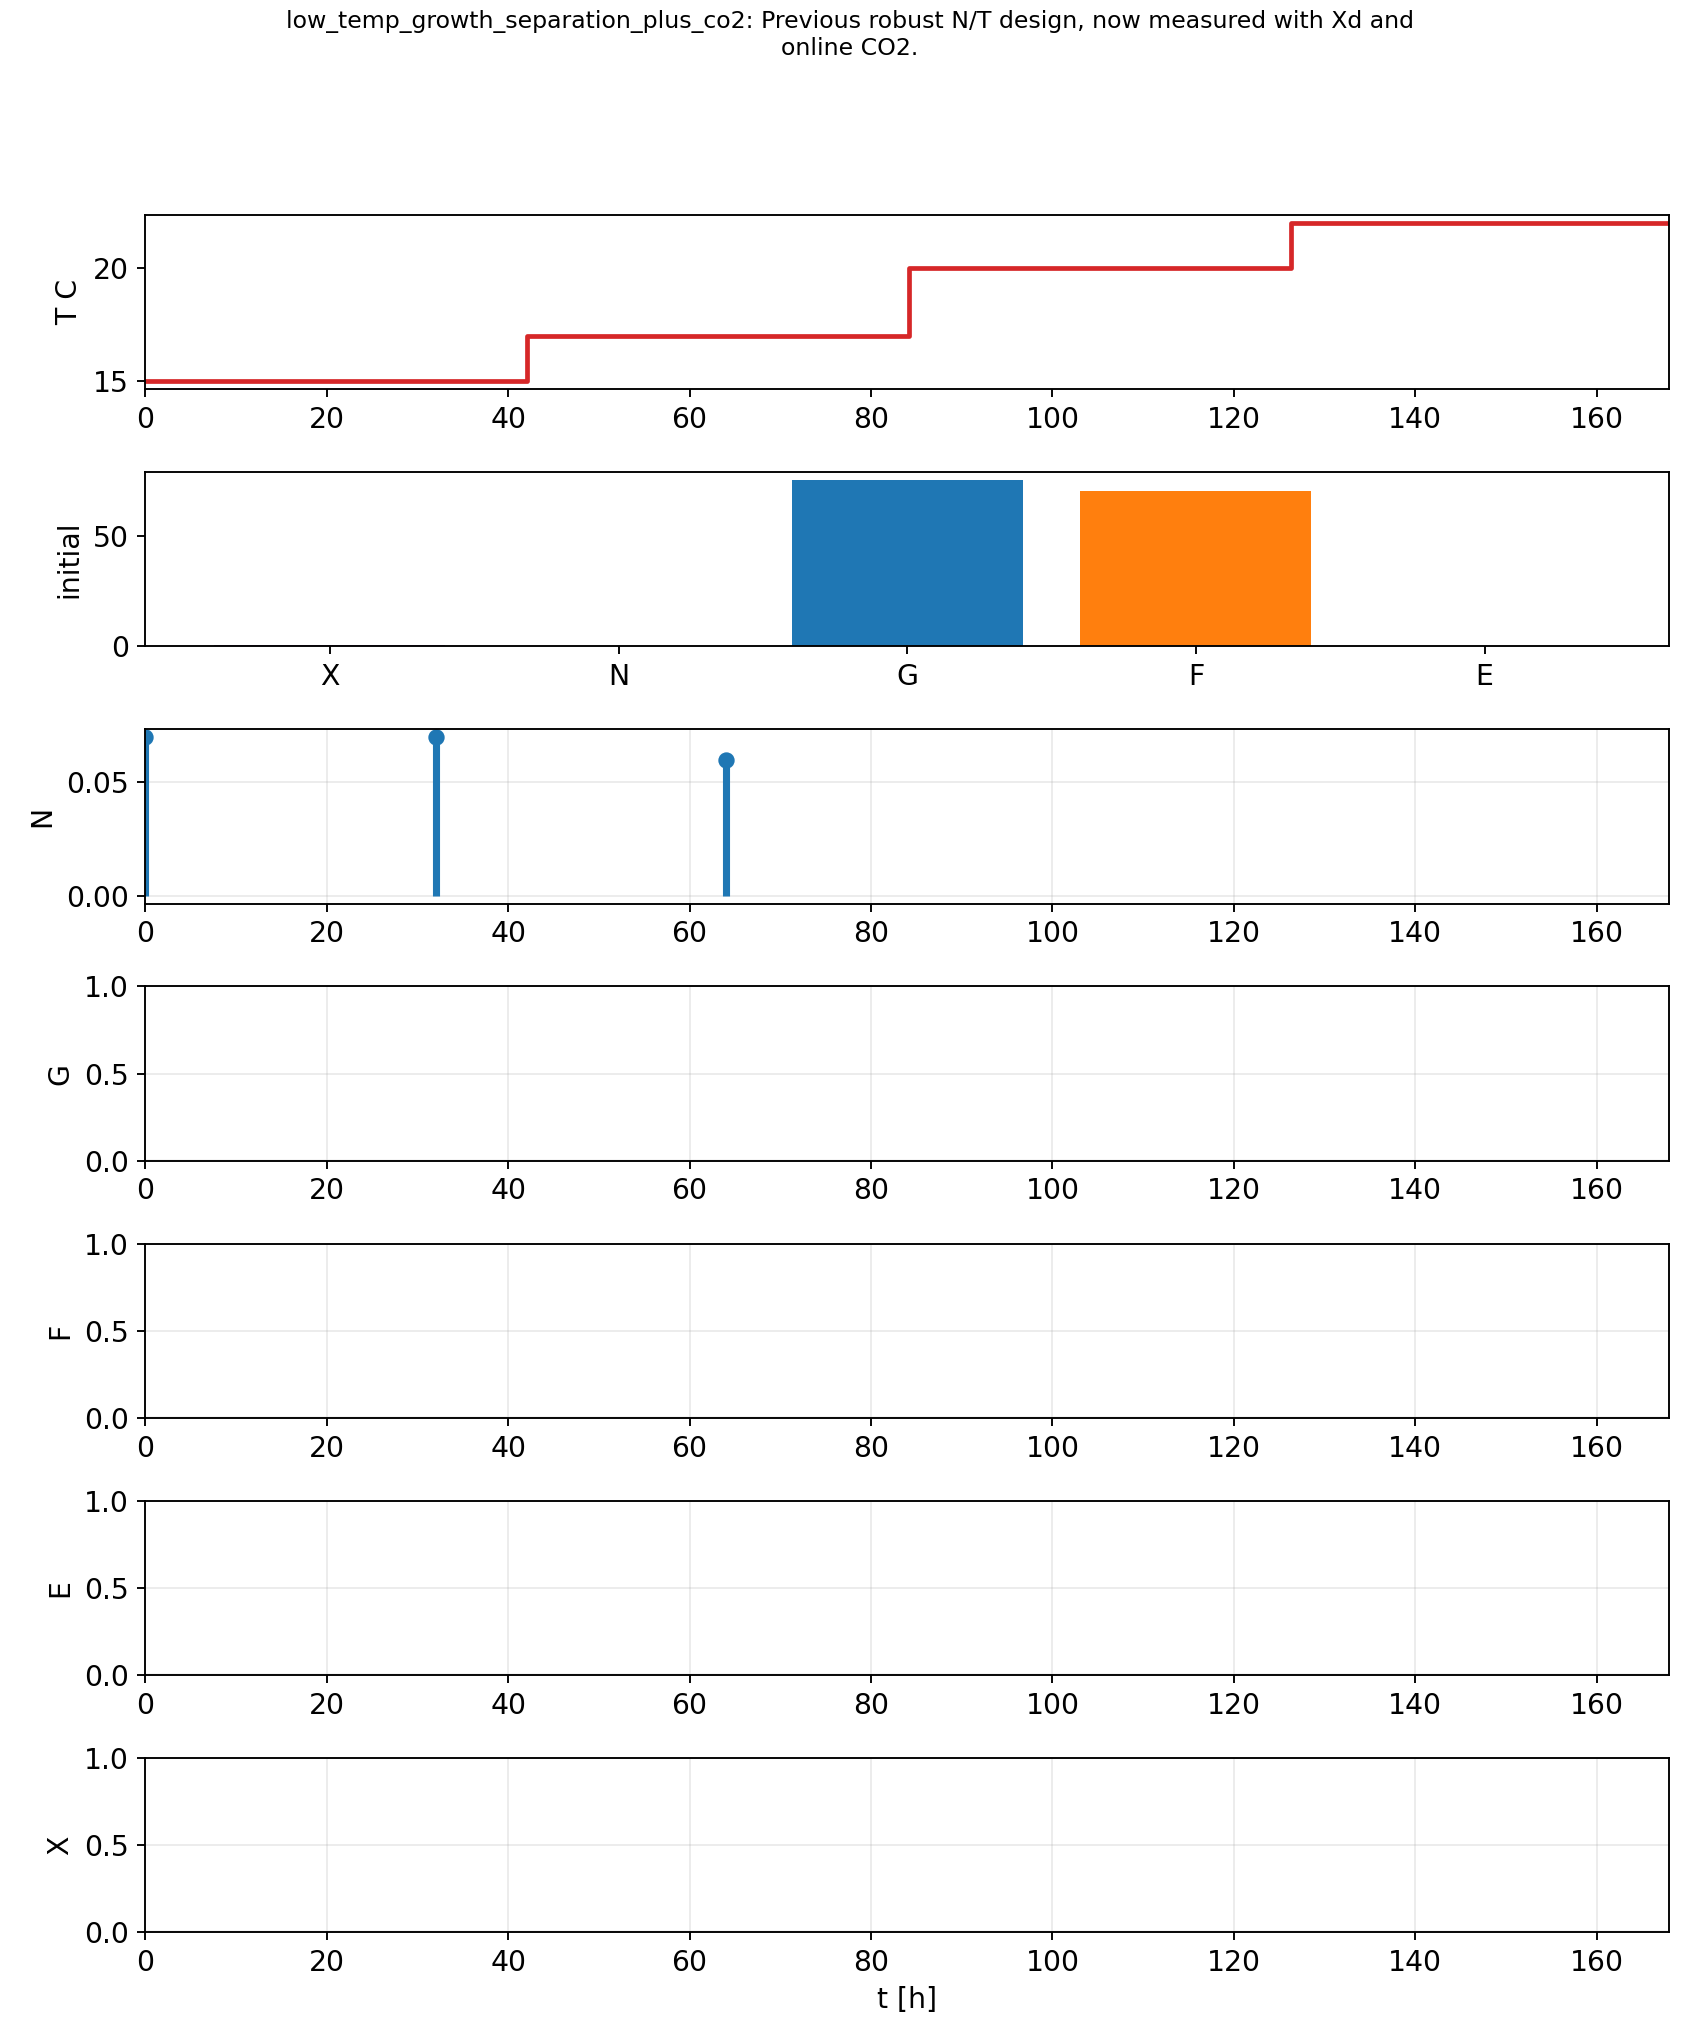

extended_campaign_inputs_ethanol_pulse_death_probe.png


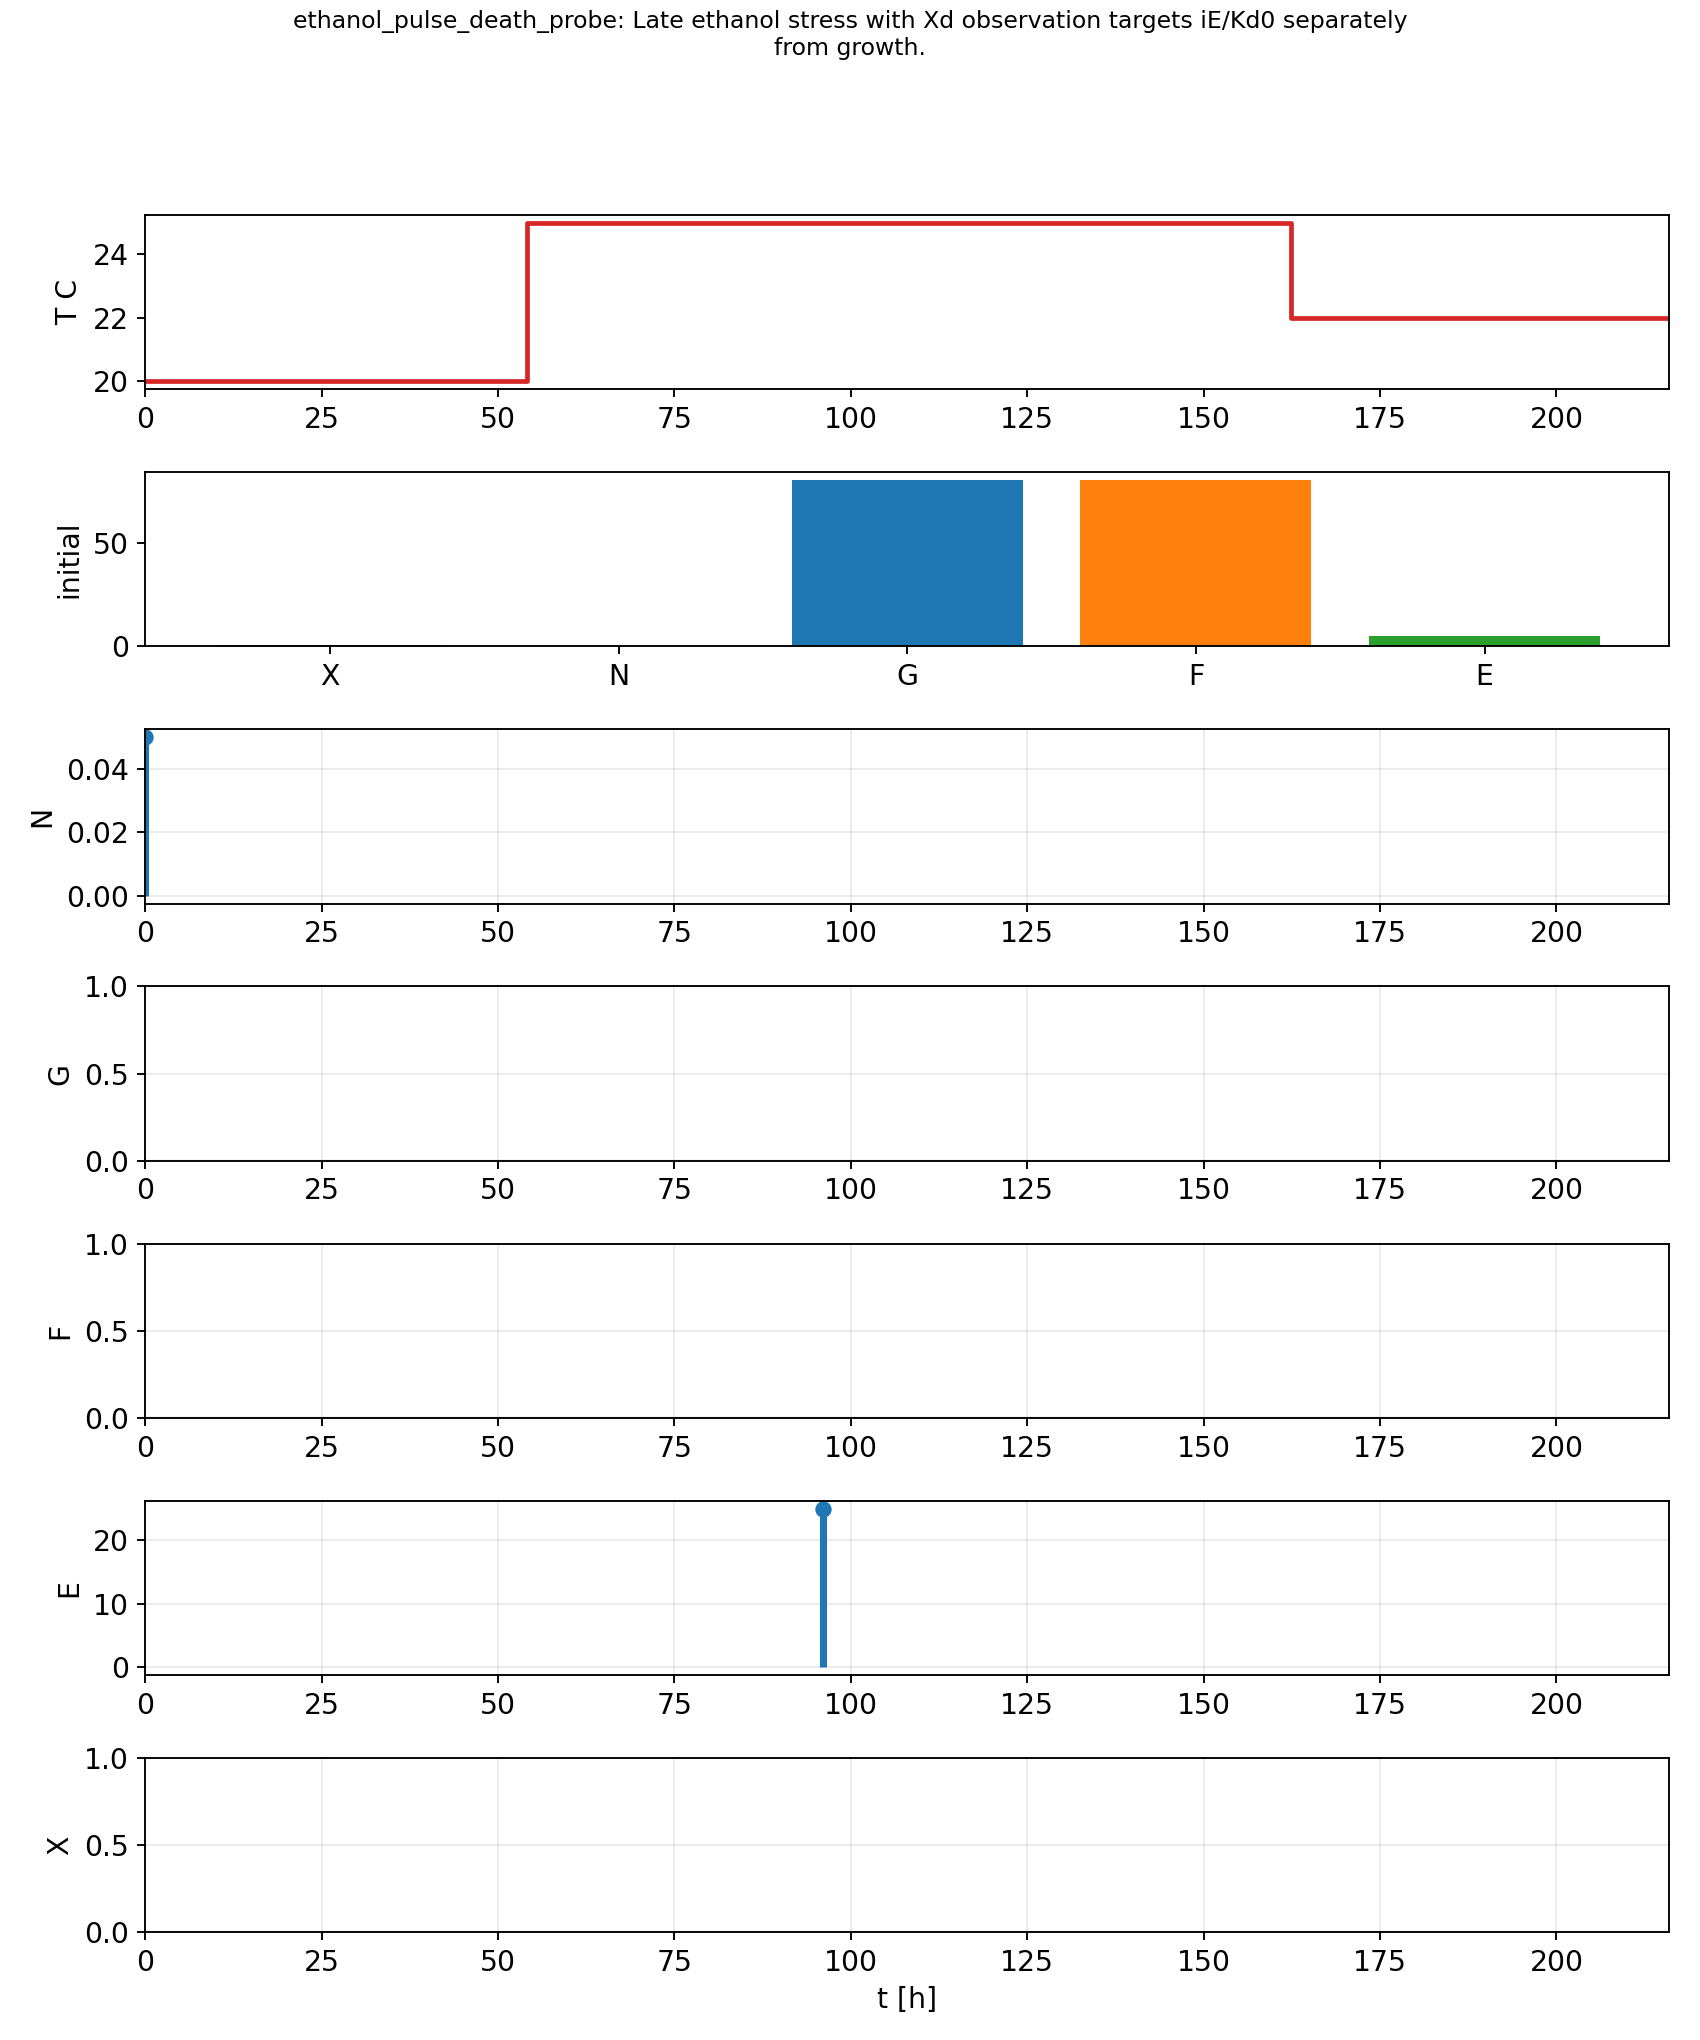

extended_campaign_inputs_ethanol_initial_challenge.png


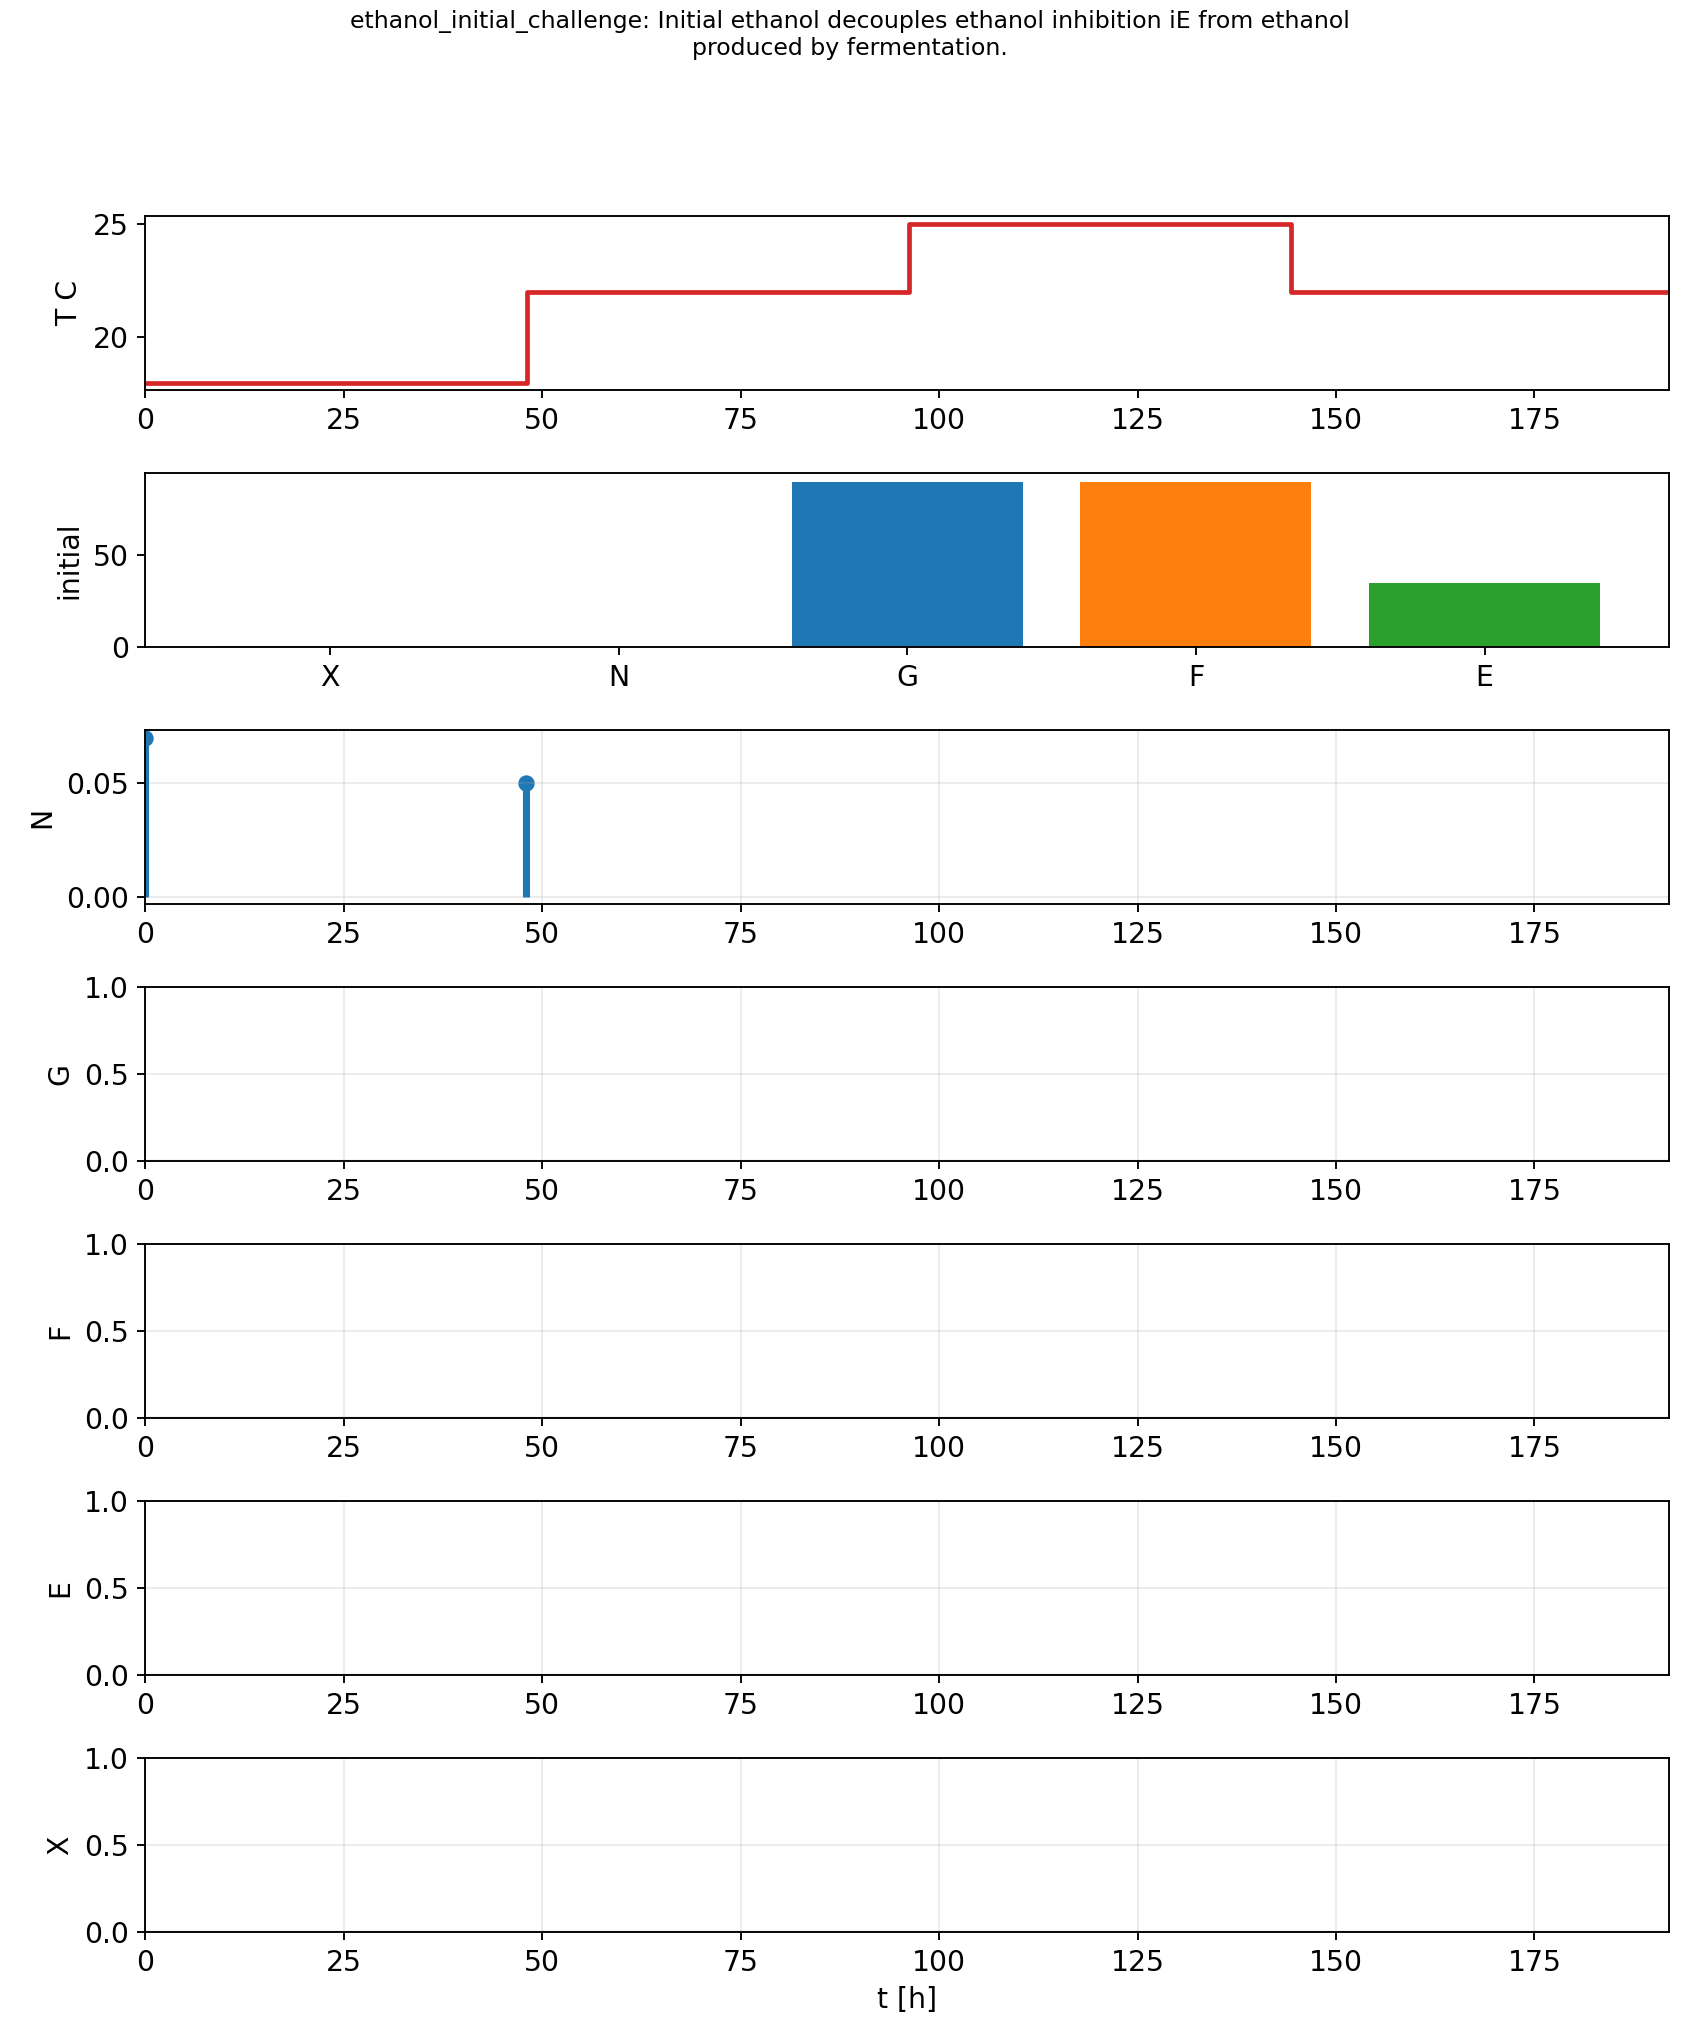

extended_campaign_inputs_glucose_pulse_after_N_depletion.png


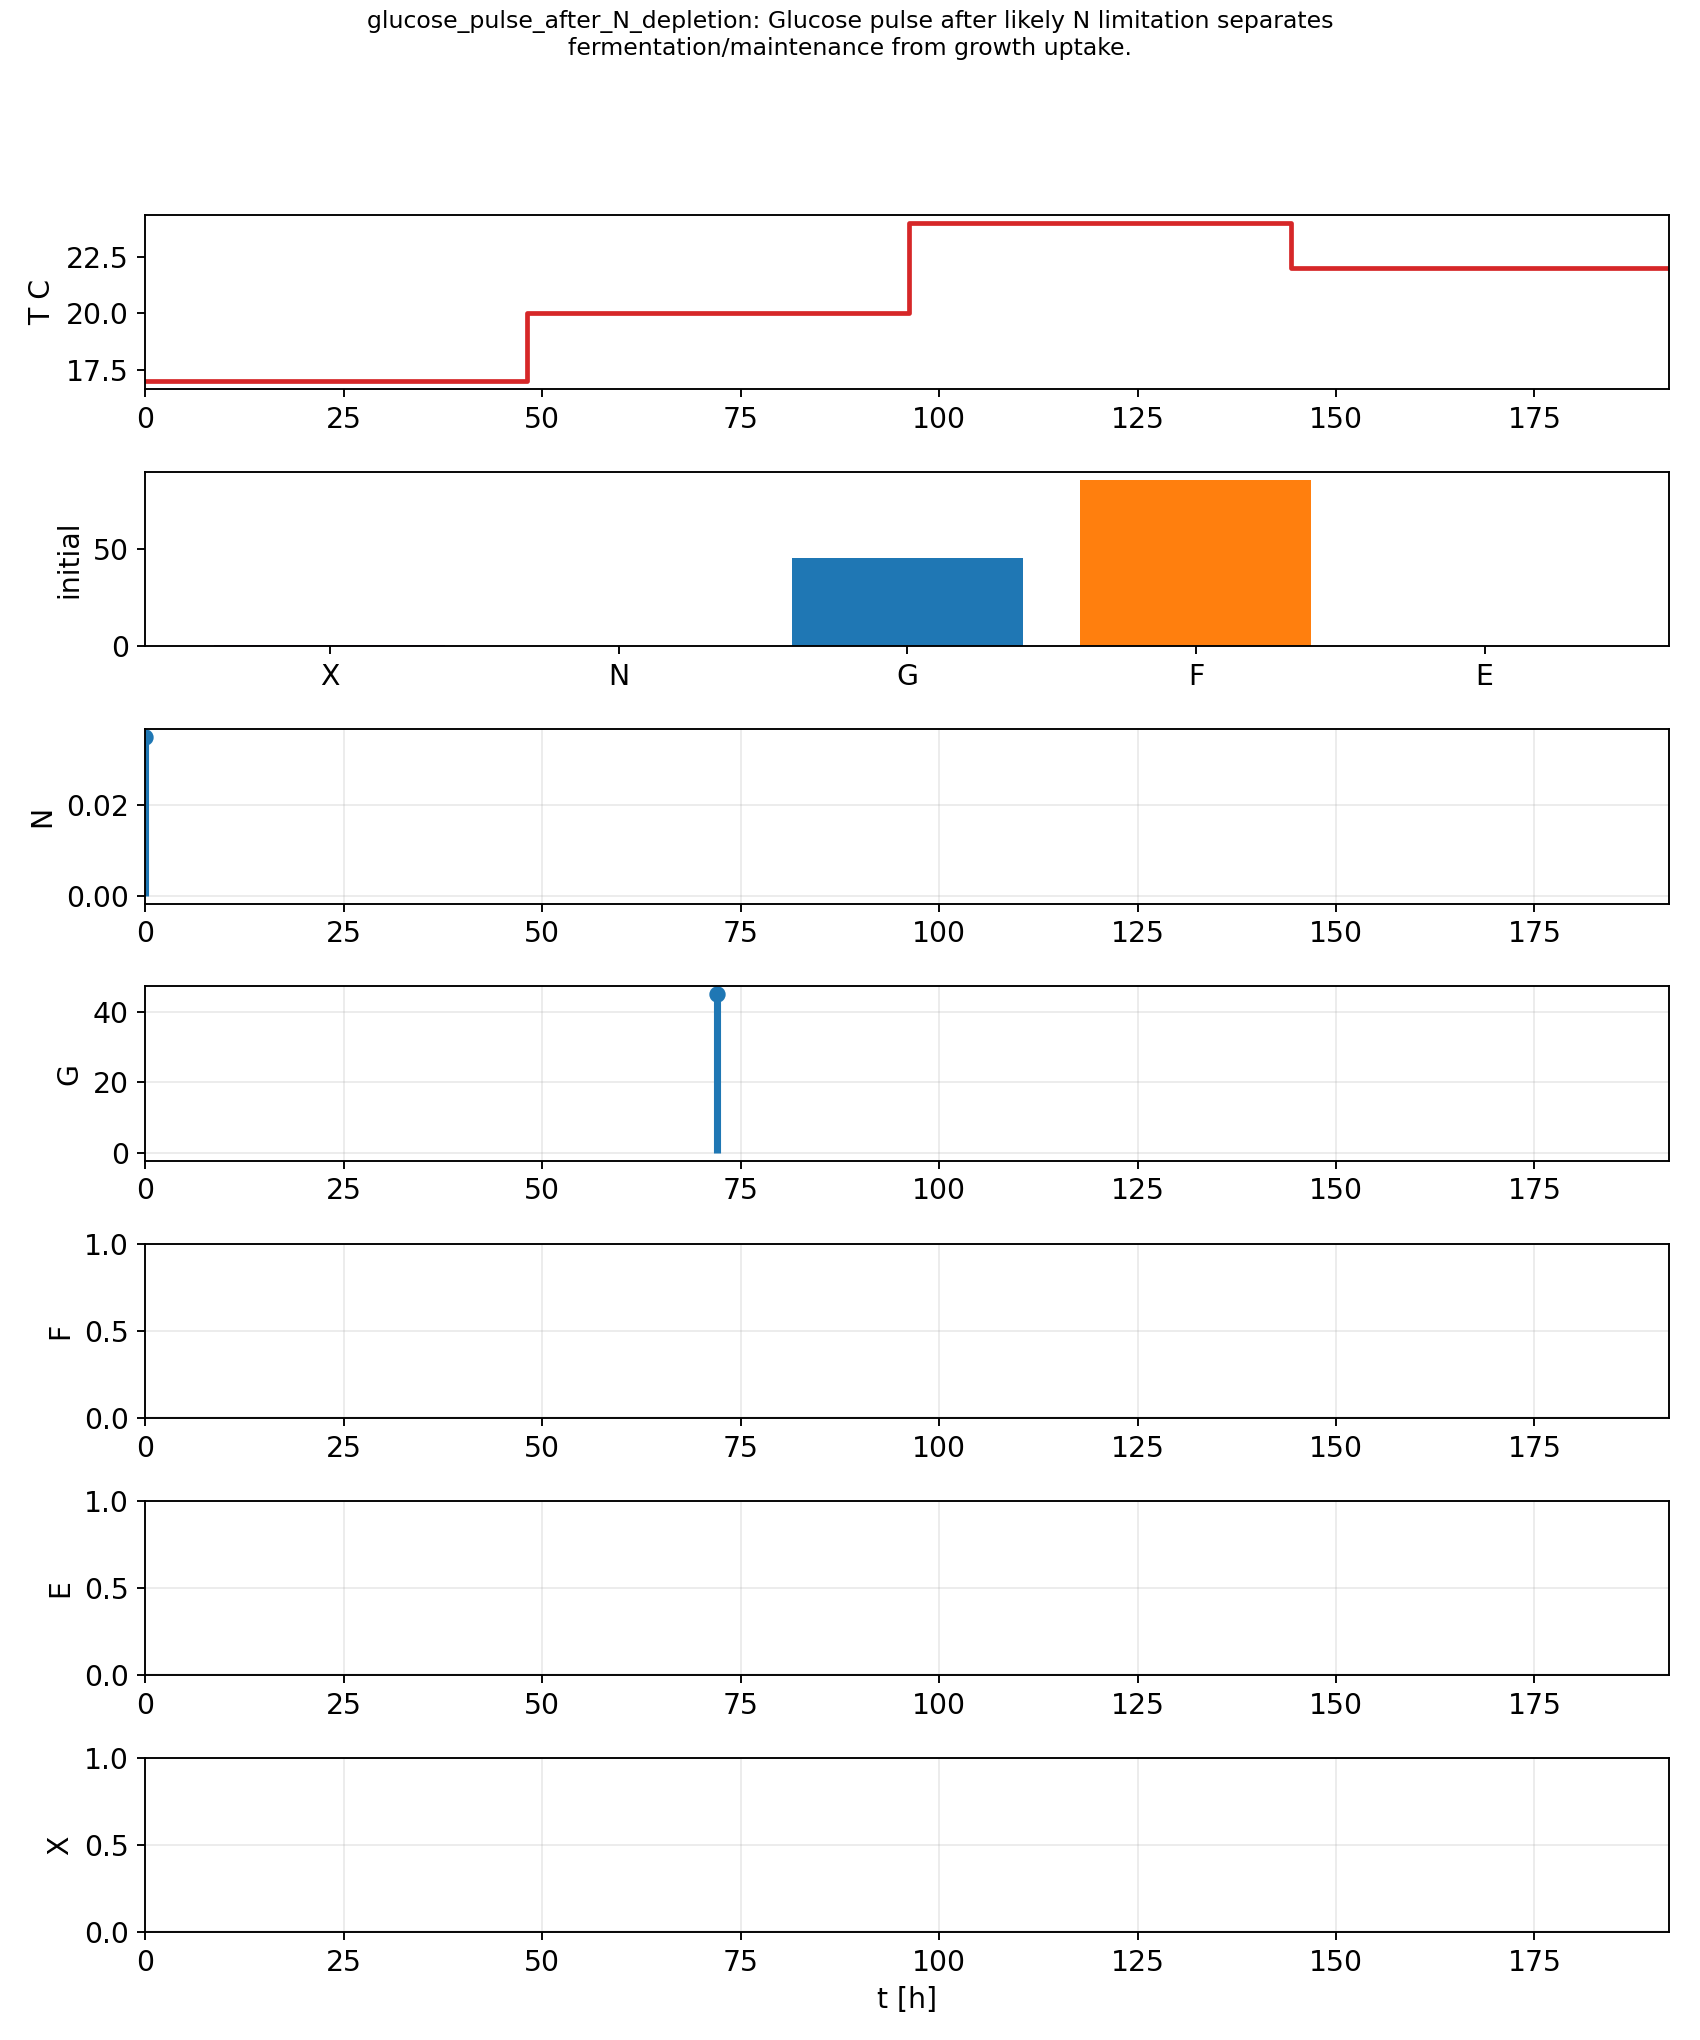

extended_campaign_inputs_viable_biomass_step.png


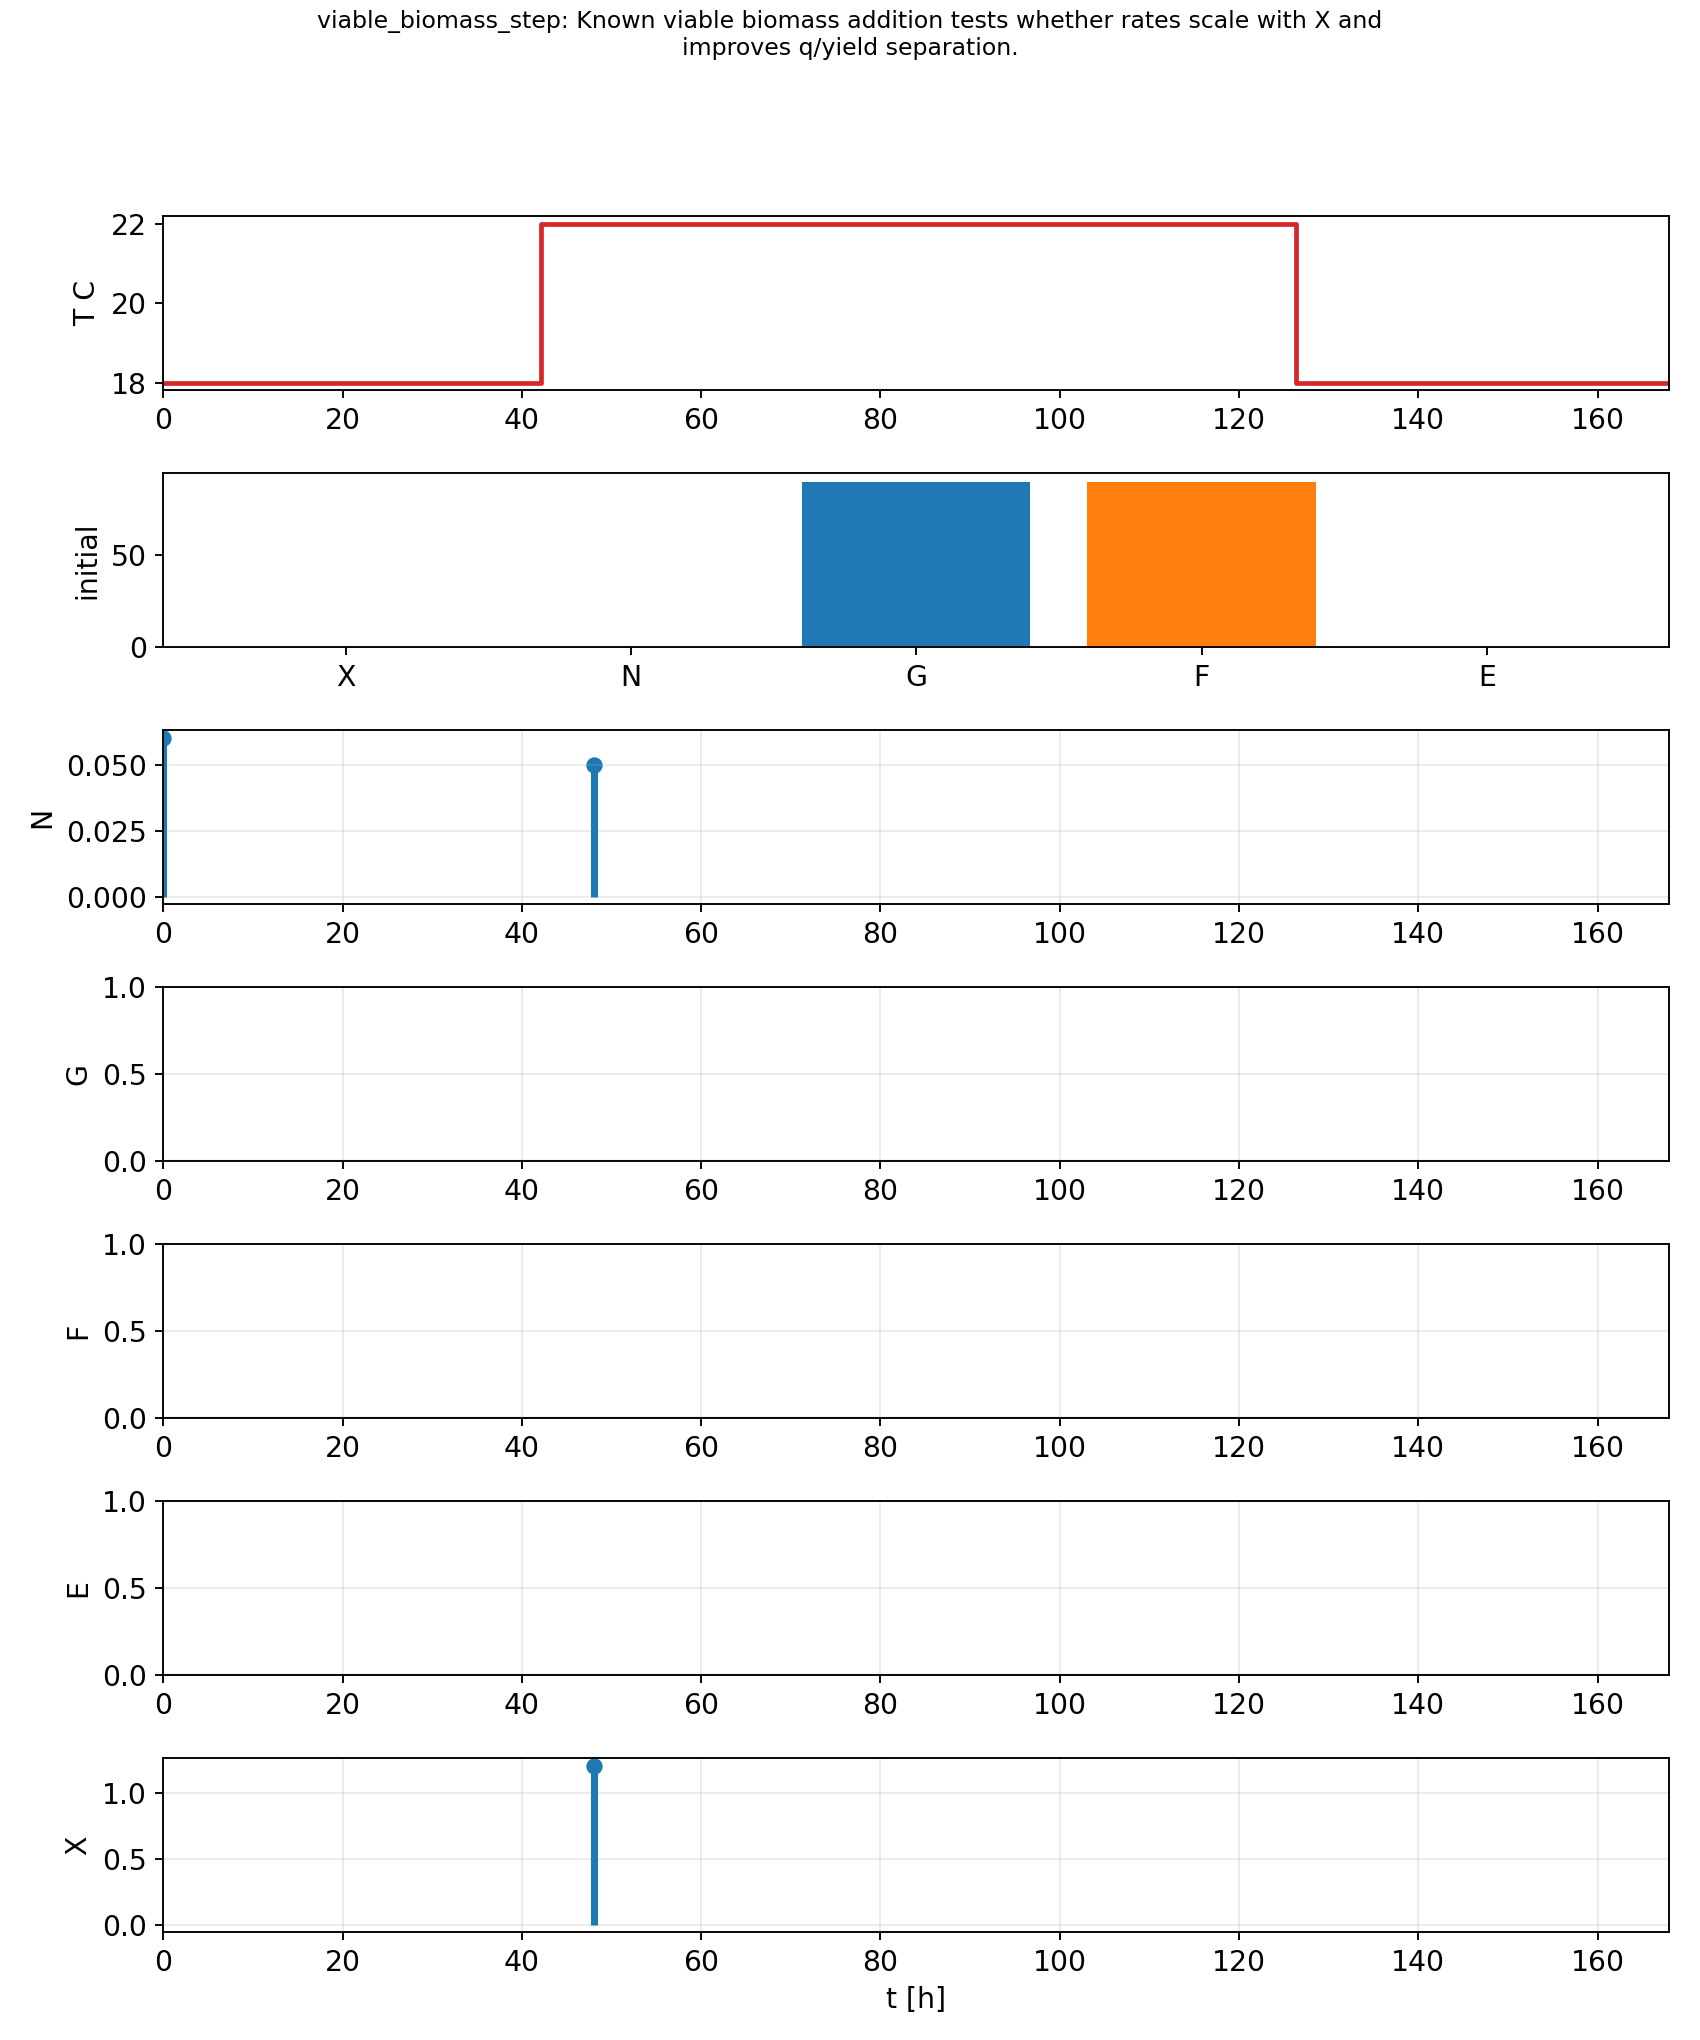

In [9]:
from IPython.display import Image, display

for name in selected["candidate"]:
    path = RESULTS / f"extended_campaign_inputs_{name}.png"
    print(path.name)
    display(Image(filename=str(path)))

## 10. Trayectorias nominales simuladas

Estas simulaciones son nominales, no datos. Sirven para verificar que los dise?os no son absurdos para el modelo actual y para anticipar rangos de medici?n.

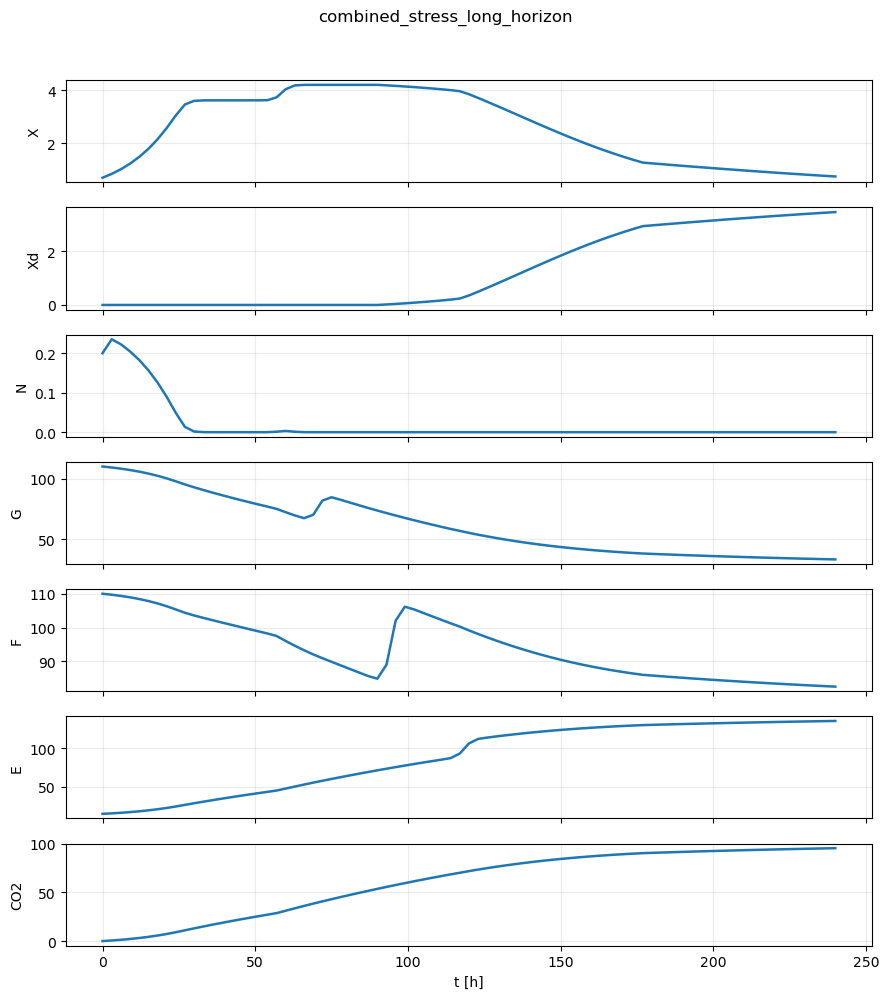

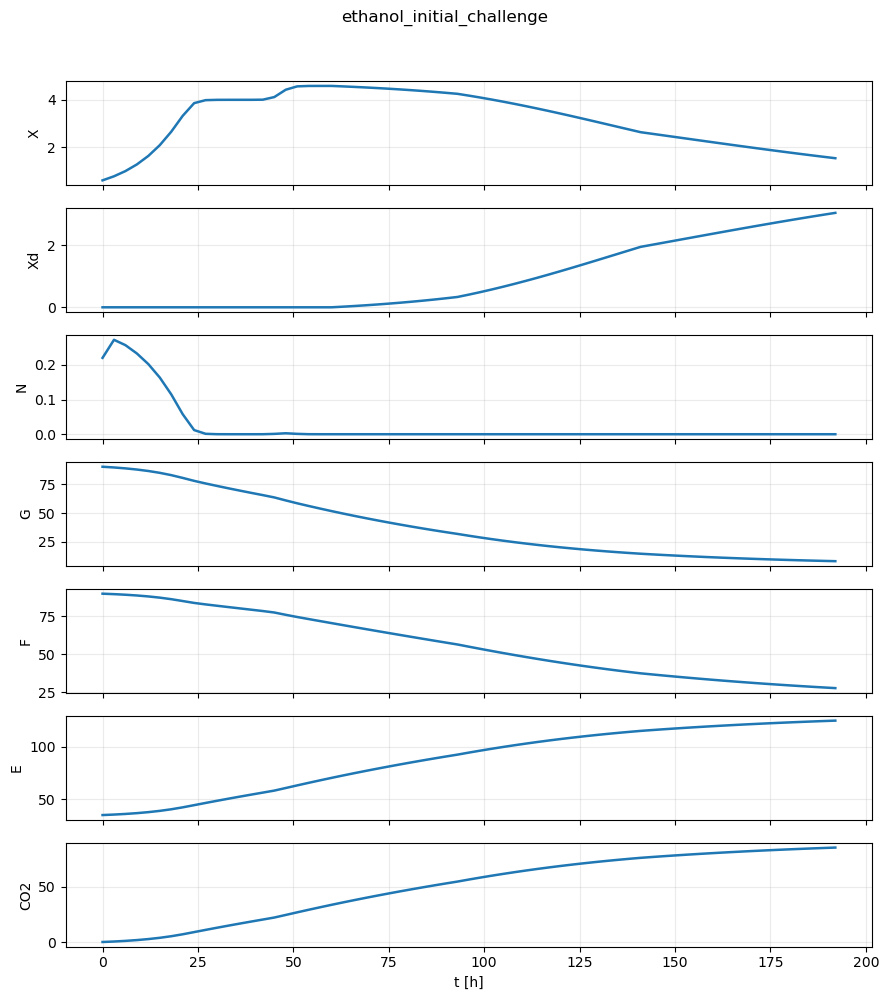

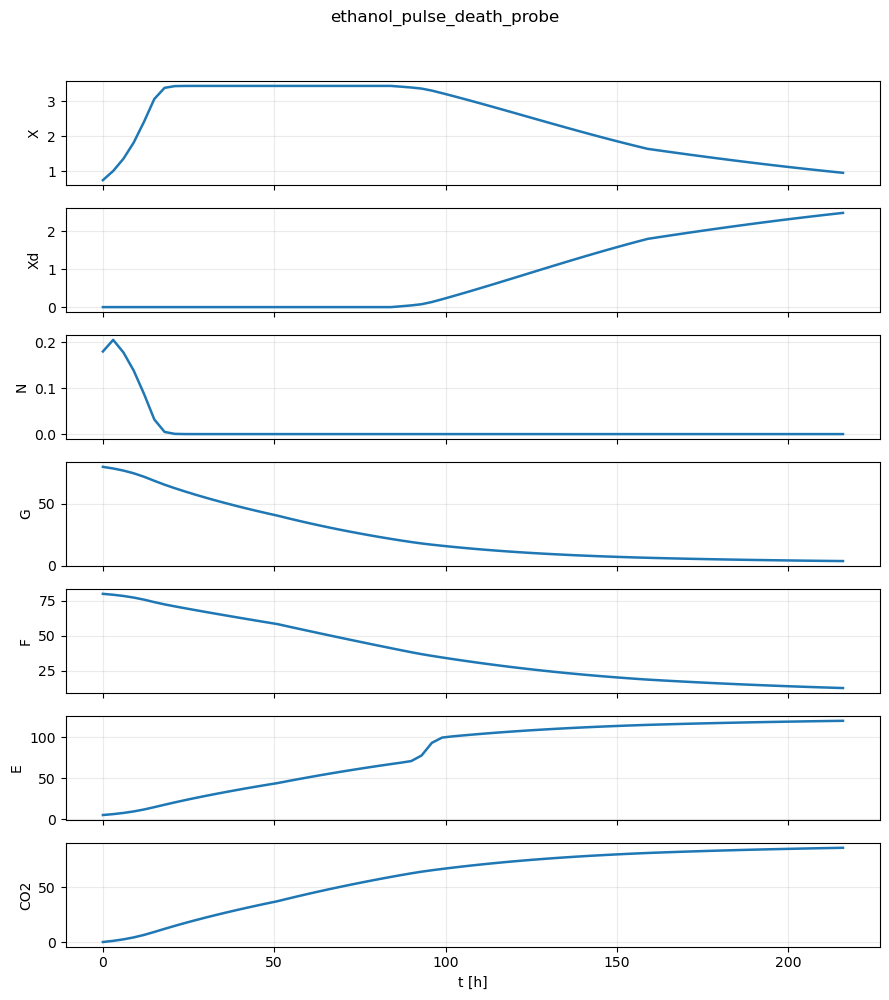

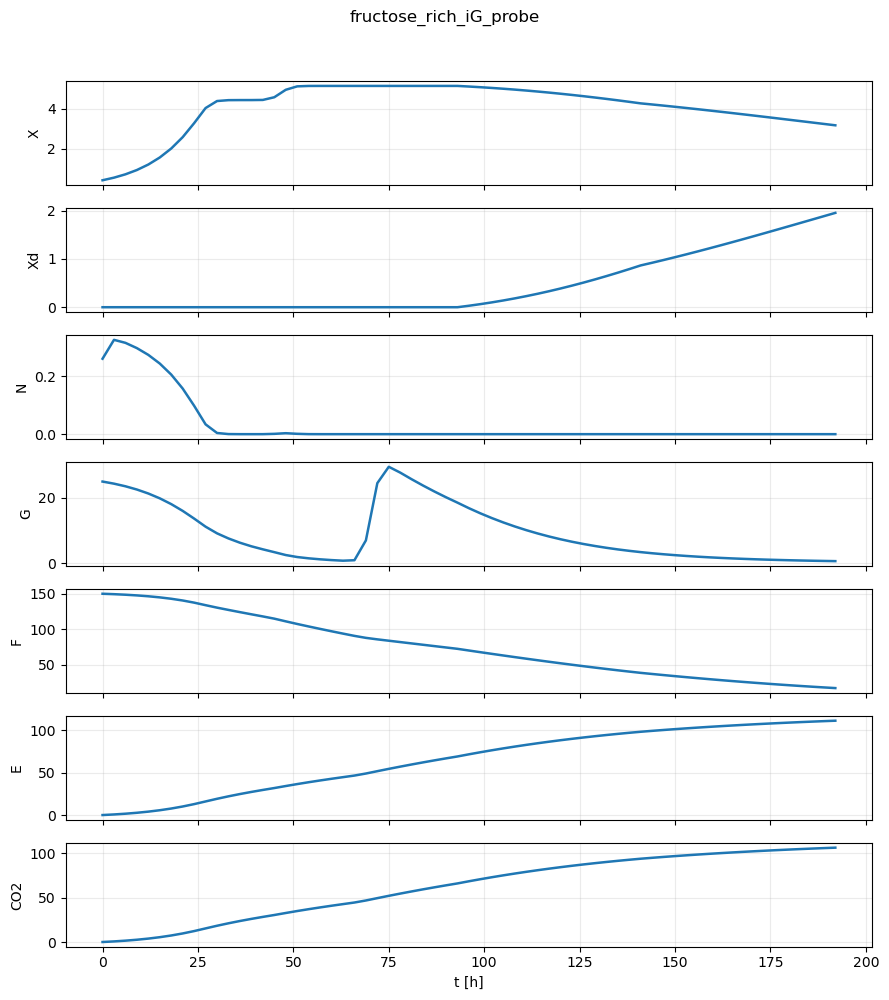

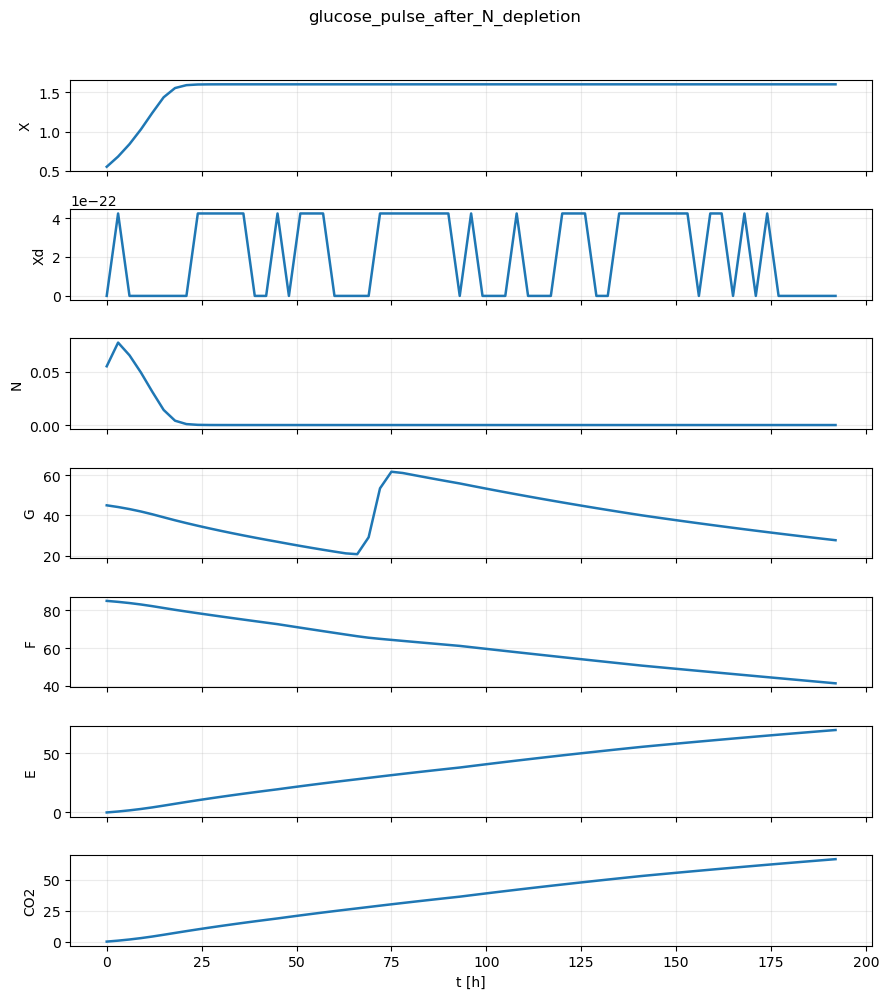

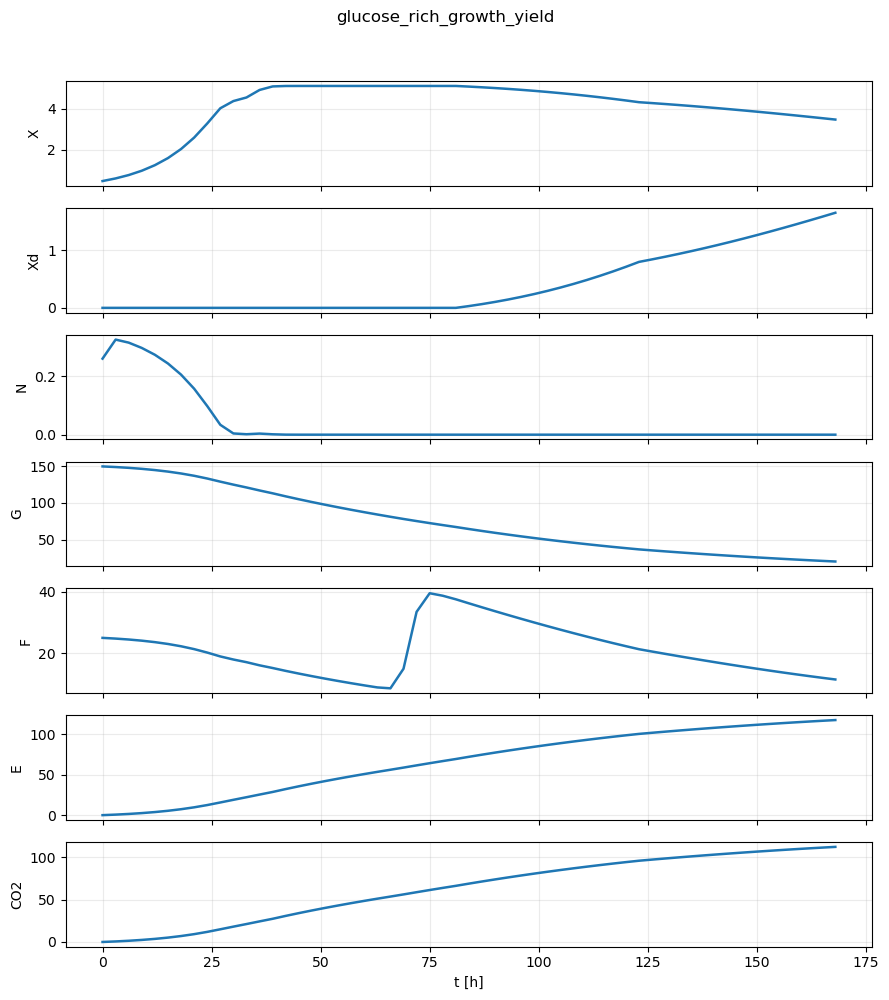

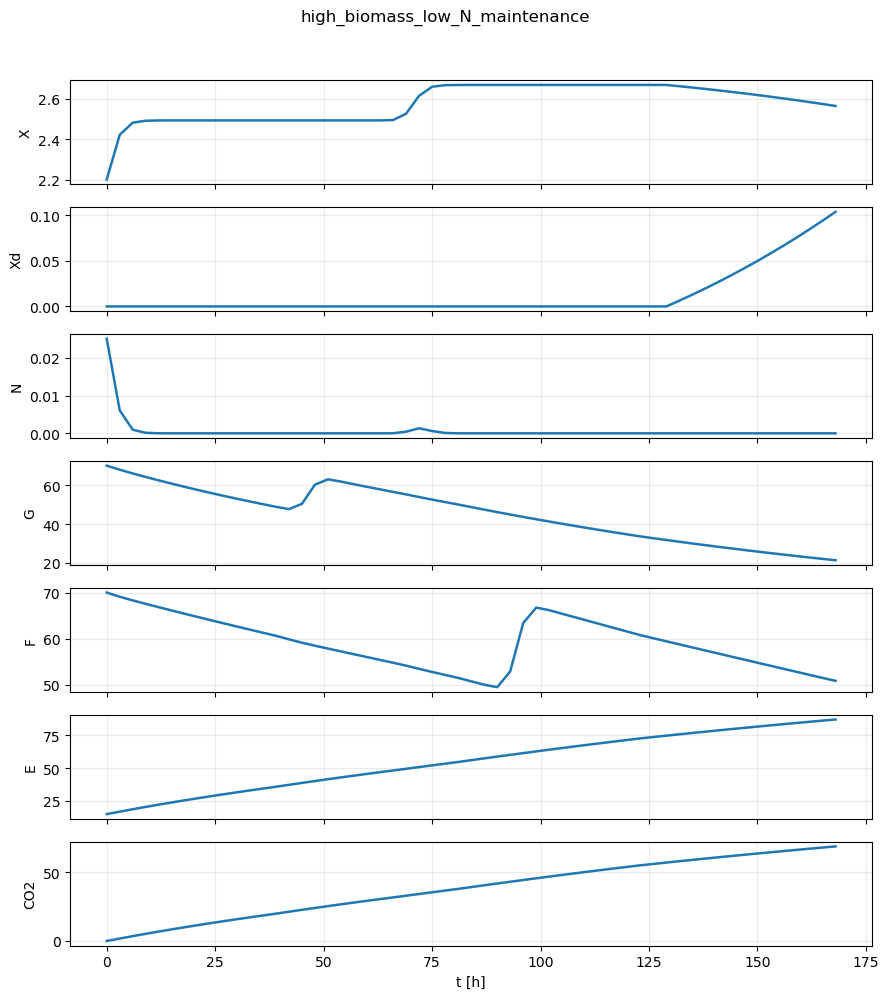

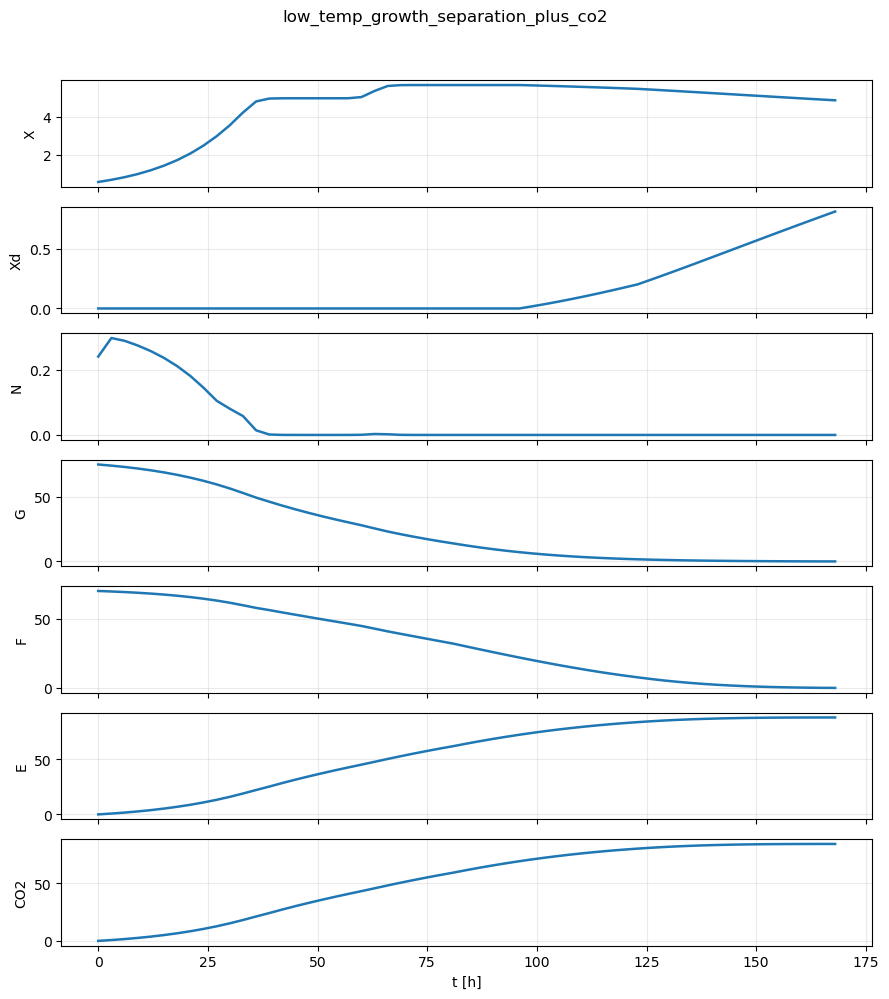

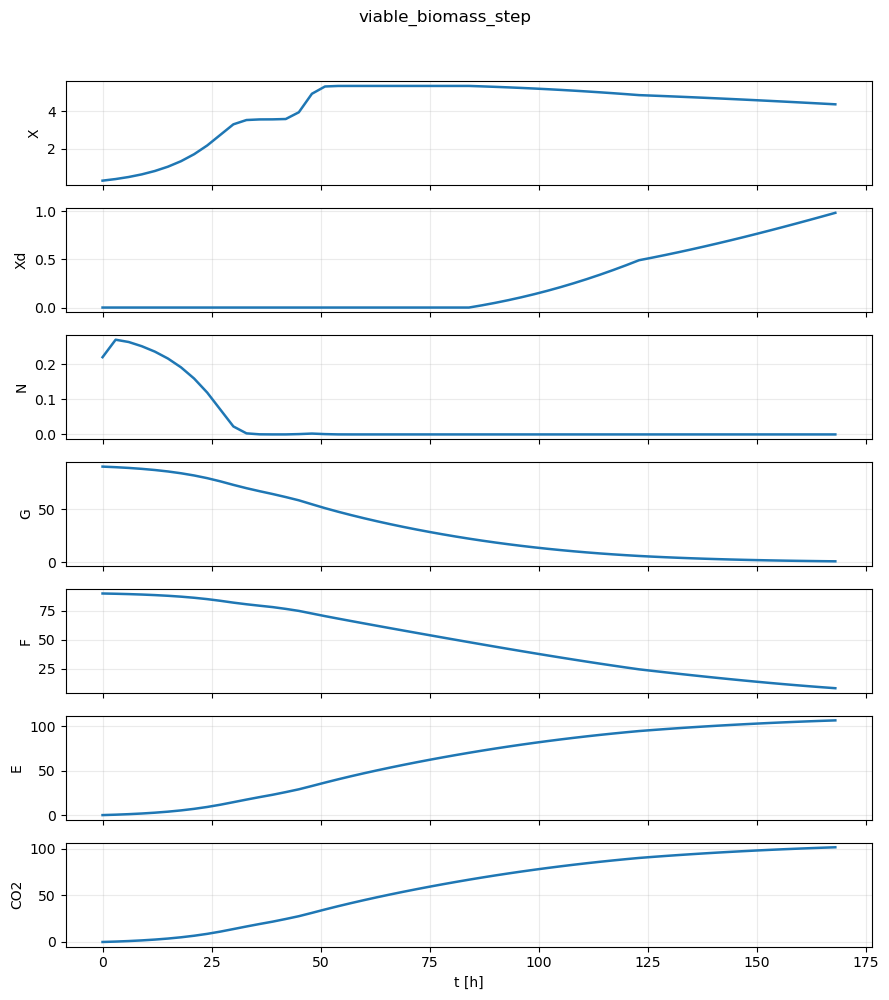

In [10]:
sim = pd.read_csv(RESULTS / "extended_campaign_simulations.csv")
states = ["X", "Xd", "N", "G", "F", "E", "CO2"]

for candidate, group in sim.groupby("candidate"):
    fig, axes = plt.subplots(len(states), 1, figsize=(9, 10), sharex=True)
    for ax, state in zip(axes, states):
        ax.plot(group["t"], group[state], lw=1.8)
        ax.set_ylabel(state)
        ax.grid(True, alpha=0.25)
    axes[-1].set_xlabel("t [h]")
    fig.suptitle(candidate, y=0.995)
    fig.tight_layout(rect=(0, 0, 1, 0.97))
    plt.show()

## 11. Interpretaci?n t?cnica

### `qXG`, `qXF`, `sG`, `sF`

La campa?a usa mostos ricos en glucosa/fructosa y pulsos monoespec?ficos para romper la colinealidad entre crecimiento, fermentaci?n y consumo de az?car. Esto ataca directamente la direcci?n casi nula observada en el modelo de 9 par?metros anterior.

### `sN`, `qN`

El dise?o `yan_saturation_scan` no qued? entre los 9 greedy finales porque, dada la combinaci?n de otros experimentos, su ganancia marginal fue menor. Aun as?, `sN` queda como el par?metro con menor reducci?n relativa en la campa?a seleccionada. Si el objetivo principal fuera nitr?geno, se puede forzar inclusi?n de un dise?o tipo YAN ladder.

### `iE`, `Kd0`

El etanol externo cambia el panorama: `iE` deja de depender solo del etanol producido por el propio modelo. `Xd` convierte muerte celular en una salida observable, por lo que `Kd0` pasa a ser una direcci?n identificable en principio.

### `m0`

Alta biomasa + bajo N genera consumo de az?car con crecimiento limitado. Esta es la condici?n que m?s ayuda a separar mantenimiento de crecimiento/fermentaci?n.

### CO2

CO2 agrega informaci?n temporal densa sobre producci?n fermentativa. En el FIM se downsamplea a 6 h para que el sensor online no domine artificialmente sobre las mediciones manuales.

## 12. Qu? hacer despu?s de ejecutar la campa?a real

Con los datos nuevos, el flujo recomendado es:

1. extender la BDD para incluir `Xd` y `CO2`;
2. recalibrar el modelo extendido con PSO/multi-start y ajuste local;
3. evaluar FIM/Q para `theta15`;
4. correr perfiles likelihood para los par?metros liberados;
5. repetir el chequeo Bayes/Laplace con priors d?biles;
6. decidir el nuevo subconjunto estructural/pr?cticamente identificable.

No conviene liberar los 15 par?metros solo por el resultado FIM simulado. El DOE indica que la campa?a deber?a hacerlos estimables; la decisi?n final depende de los datos observados.


## 13. Refinamiento OED posterior al screening

La primera campa?a fue **model-based en evaluaci?n**, porque cada candidato fue evaluado con la FIM secuencial de `pyomo.contrib.doe`. Sin embargo, no era una optimizaci?n continua de las variables de dise?o; era un screening de una librer?a de experimentos candidatos.

Para cerrar esa brecha se agreg? un segundo runner: `run_extended_campaign_oed_refinement.py`. Este runner usa la FIM de Pyomo DoE como evaluador, pero optimiza externamente el dise?o en dos niveles:

1. **Re-selecci?n dirigida de campa?a** entre candidatos ya evaluados.
2. **Refinamiento local acotado** de setpoints, composici?n inicial y pulsos.

Se prob? `DesignOfExperiments.run_doe()` directamente con variables de dise?o libres, pero en esta instalaci?n el modelo extendido produjo terminaci?n `other` de Ipopt y un `UnboundLocalError` interno de Pyomo DoE al reportar `results_message`. Por eso se usa una ruta m?s robusta: cada propuesta de dise?o se fija y se eval?a con:

\[
F(\xi) = J(\xi)^T W J(\xi)
\]

v?a:

```python
DesignOfExperiments(...).compute_FIM(method="sequential")
```

El criterio de campa?a usado para seleccionar y refinar no es D-opt puro. Se usa un score mixto:

\[
\Phi(\xi) = \log\det F + 10\bar R_{corr} + 20R_{corr}^{worst} + 5R_{s_N} + 2\log\left(\frac{\lambda_{min}}{\lambda_{max}}\right)
\]

donde \(R\) es la reducci?n de varianza aproximada respecto de la FIM hist?rica. La raz?n t?cnica es que el diagn?stico extendido dej? a `sN` como el par?metro corregible m?s d?bil; por eso se fuerza presi?n sobre el peor caso, no solo sobre la informaci?n total.


In [11]:

OED_RESULTS = FERM / "results" / "extended_campaign_oed_refinement"
OED_SCRIPT = FERM / "run_extended_campaign_oed_refinement.py"

RUN_LONG_OED_REFINEMENT = False
if RUN_LONG_OED_REFINEMENT:
    subprocess.run([
        sys.executable, str(OED_SCRIPT),
        "--trials-per-candidate", "2",
        "--passes", "1",
        "--cache-label", "max8000_checked",
    ], cwd=str(ROOT), check=True)

original_selected = pd.read_csv(OED_RESULTS / "oed_reference_original_selected.csv")
targeted_selected = pd.read_csv(OED_RESULTS / "oed_targeted_campaign_selected.csv")
refined_selected = pd.read_csv(OED_RESULTS / "oed_refined_campaign_selected.csv")
refined_protocols = pd.read_csv(OED_RESULTS / "oed_refined_protocols.csv")
refined_pulses = pd.read_csv(OED_RESULTS / "oed_refined_pulses.csv")
refined_reduction = pd.read_csv(OED_RESULTS / "oed_refined_parameter_reduction.csv")
refined_trials = pd.read_csv(OED_RESULTS / "oed_refinement_trials.csv")
refined_metadata = pd.read_json(OED_RESULTS / "oed_refinement_metadata.json", typ="series")

refined_metadata


prior_batches                                           [25026, 25086, 25150, 25170]
campaign_size                                                                      9
step                                                                            0.01
pulse_slots                                                                        3
liquid_interval_h                                                               12.0
co2_interval_h                                                                   6.0
trials_per_candidate                                                               2
passes                                                                             1
seed                                                                        20260607
require_x_pulse                                                                 True
allow_new_pulses                                                                True
solver_max_iter                                                  


### 13.1 Comparaci?n de criterios

El cambio relevante no fue agregar m?s fermentaciones, sino cambiar el criterio de selecci?n. La campa?a original proteg?a cobertura de biomasa viable, pero dejaba `sN` con la menor reducci?n de varianza. El criterio dirigido incluye `yan_saturation_scan` porque genera una escalera de nitr?geno que ataca la saturaci?n de YAN y la separaci?n `sN/qN`.


In [12]:

comparison = pd.DataFrame([
    {
        "stage": "original_candidate_screening",
        "logdet": original_selected.iloc[-1]["campaign_logdet"],
        "condition_number": original_selected.iloc[-1]["campaign_condition_number"],
        "mean_correctable_reduction": original_selected.iloc[-1]["correctable_mean_var_reduction"],
        "worst_correctable_reduction": original_selected.iloc[-1]["correctable_worst_var_reduction"],
    },
    {
        "stage": "targeted_reselection",
        "logdet": targeted_selected.iloc[-1]["logdet"],
        "condition_number": targeted_selected.iloc[-1]["condition_number"],
        "mean_correctable_reduction": targeted_selected.iloc[-1]["correctable_mean_var_reduction"],
        "worst_correctable_reduction": targeted_selected.iloc[-1]["correctable_worst_var_reduction"],
    },
    {
        "stage": "targeted_local_refinement",
        "logdet": refined_selected.iloc[-1]["logdet"],
        "condition_number": refined_selected.iloc[-1]["condition_number"],
        "mean_correctable_reduction": refined_selected.iloc[-1]["correctable_mean_var_reduction"],
        "worst_correctable_reduction": refined_selected.iloc[-1]["correctable_worst_var_reduction"],
    },
])
comparison


,stage,logdet,condition_number,mean_correctable_reduction,worst_correctable_reduction
0,original_candidate_screening,114.720725,87557.85344,0.936081,0.618248
1,targeted_reselection,114.319734,79630.17584,0.947216,0.721737
2,targeted_local_refinement,115.815884,68359.55966,0.954681,0.766022


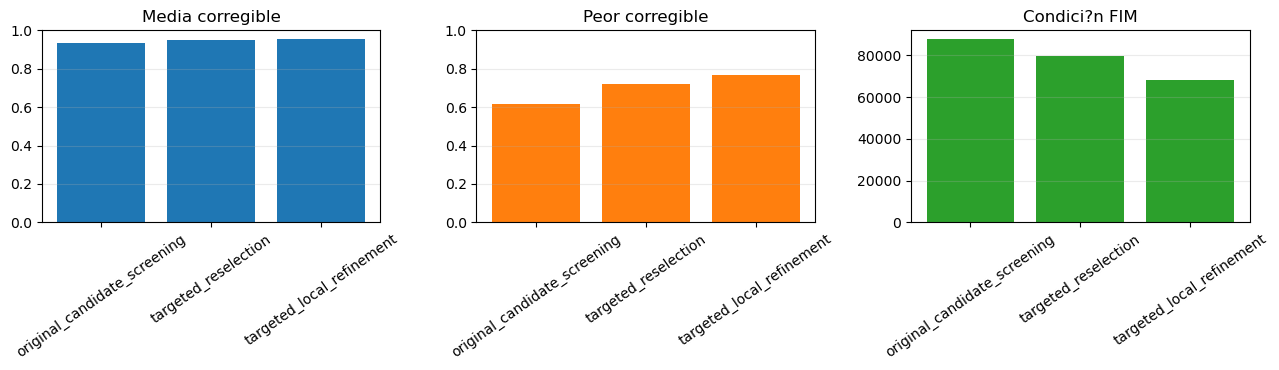

In [13]:

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
axes[0].bar(comparison["stage"], comparison["mean_correctable_reduction"], color="tab:blue")
axes[0].set_title("Media corregible")
axes[0].set_ylim(0, 1.0)
axes[0].tick_params(axis="x", rotation=35)
axes[0].grid(axis="y", alpha=0.25)

axes[1].bar(comparison["stage"], comparison["worst_correctable_reduction"], color="tab:orange")
axes[1].set_title("Peor corregible")
axes[1].set_ylim(0, 1.0)
axes[1].tick_params(axis="x", rotation=35)
axes[1].grid(axis="y", alpha=0.25)

axes[2].bar(comparison["stage"], comparison["condition_number"], color="tab:green")
axes[2].set_title("Condici?n FIM")
axes[2].tick_params(axis="x", rotation=35)
axes[2].grid(axis="y", alpha=0.25)

fig.tight_layout()
plt.show()



### 13.2 Campa?a refinada final

La campa?a final mantiene 9 fermentaciones. La mejora viene de tres decisiones:

- incluir un experimento tipo YAN ladder (`yan_saturation_scan`) para `sN`;
- mantener un experimento con pulso de biomasa viable (`viable_biomass_step`) para no perder separaci?n entre escalamiento por `X`, muerte y `Xd`;
- ajustar localmente setpoints, mosto inicial y pulsos en torno a dise?os f?sicamente razonables.


In [14]:

show_cols = [
    "campaign_order", "candidate", "family", "horizon_h", "temperature_c",
    "targeted_oed_score", "correctable_mean_var_reduction",
    "correctable_worst_var_reduction", "condition_number",
]
refined_selected[show_cols]


,campaign_order,candidate,family,horizon_h,temperature_c,targeted_oed_score,correctable_mean_var_reduction,correctable_worst_var_reduction,condition_number
0,1,glucose_rich_growth_yield,sugar_initial,168.0,"19, 20.5, 23, 20.5",75.415290,0.770197,0.241805,310468.814197
1,2,fructose_rich_iG_probe,sugar_initial,192.0,"19.5, 19, 24, 22",90.706656,0.849704,0.371109,213096.641015
2,3,combined_stress_long_horizon,integrated,240.0,"15, 21, 24.5, 19",100.514297,0.886756,0.408900,124682.190854
3,4,yan_saturation_scan,saturation,144.0,"15, 19, 22.5, 21.5",108.157341,0.918189,0.628972,114576.768342
4,5,low_temp_growth_separation_plus_co2,legacy_plus,168.0,"16, 19.5, 21, 23.5",113.257916,0.935166,0.708428,89764.538908
5,6,glucose_pulse_after_N_depletion,pulse_separation,192.0,"17, 20, 24, 22",115.770884,0.941599,0.725263,69734.519374
6,7,high_biomass_low_N_maintenance,maintenance,168.0,"16, 18, 20, 18",118.040559,0.943623,0.726137,65023.437441
7,8,ethanol_initial_challenge,ethanol,192.0,"18.5, 22.5, 23.5, 22.5",120.121920,0.948420,0.739469,65016.096998
8,9,viable_biomass_step,biomass_input,168.0,"16.5, 21.5, 22.5, 18.5",122.248180,0.954681,0.766022,68359.559660


In [15]:

protocol_cols = [
    "campaign_order", "candidate", "temperature_c",
    "X0", "N0", "G0", "F0", "E0", "Xd0",
]
refined_protocols[protocol_cols]


,campaign_order,candidate,temperature_c,X0,N0,G0,F0,E0,Xd0
0,1,glucose_rich_growth_yield,"19, 20.5, 23, 20.5",0.498833,0.230457,164.503397,19.231500,0.282786,0.0
1,2,fructose_rich_iG_probe,"19.5, 19, 24, 22",0.395325,0.234590,21.427118,154.664546,0.000000,0.0
2,3,combined_stress_long_horizon,"15, 21, 24.5, 19",0.743710,0.187893,125.864674,127.816499,5.188020,0.0
3,4,yan_saturation_scan,"15, 19, 22.5, 21.5",0.325106,0.052729,77.033792,110.294811,0.000000,0.0
4,5,low_temp_growth_separation_plus_co2,"16, 19.5, 21, 23.5",0.417553,0.214006,82.692196,59.903864,1.215988,0.0
5,6,glucose_pulse_after_N_depletion,"17, 20, 24, 22",0.550000,0.055000,45.000000,85.000000,0.000000,0.0
6,7,high_biomass_low_N_maintenance,"16, 18, 20, 18",2.200000,0.025000,70.000000,70.000000,15.000000,0.0
7,8,ethanol_initial_challenge,"18.5, 22.5, 23.5, 22.5",0.609428,0.228275,97.299740,82.847284,34.588812,0.0
8,9,viable_biomass_step,"16.5, 21.5, 22.5, 18.5",0.285713,0.258249,74.261327,99.622884,2.807832,0.0


In [16]:

refined_pulses.sort_values(["candidate", "channel", "time_h"])


,candidate,family,channel,time_h,amount
11,combined_stress_long_horizon,integrated,E,115.0,24.334701
10,combined_stress_long_horizon,integrated,F,87.0,25.396383
9,combined_stress_long_horizon,integrated,G,71.0,40.286760
7,combined_stress_long_horizon,integrated,N,8.0,0.044645
8,combined_stress_long_horizon,integrated,N,66.0,0.075002
23,ethanol_initial_challenge,ethanol,N,7.0,0.090956
24,ethanol_initial_challenge,ethanol,N,31.0,0.029712
6,fructose_rich_iG_probe,sugar_initial,G,72.0,46.561741
4,fructose_rich_iG_probe,sugar_initial,N,0.0,0.107496
5,fructose_rich_iG_probe,sugar_initial,N,49.0,0.077914


In [17]:

refined_reduction.sort_values("campaign_var_reduction", ascending=True)


,parameter,group,campaign_var_ratio,campaign_var_reduction
1,sN,currently_fixed_target,0.233978,0.766022
2,qN,accepted_current,0.081445,0.918555
0,mu0,accepted_current,0.058212,0.941788
8,sF,currently_fixed_target,0.042509,0.957491
4,qXF,currently_fixed_target,0.018031,0.981969
3,qXG,currently_fixed_target,0.017894,0.982106
14,m0,currently_fixed_target,0.017530,0.982470
9,qEG,accepted_current,0.017106,0.982894
12,iE,currently_fixed_target,0.016074,0.983926
6,sG,currently_fixed_target,0.015539,0.984461


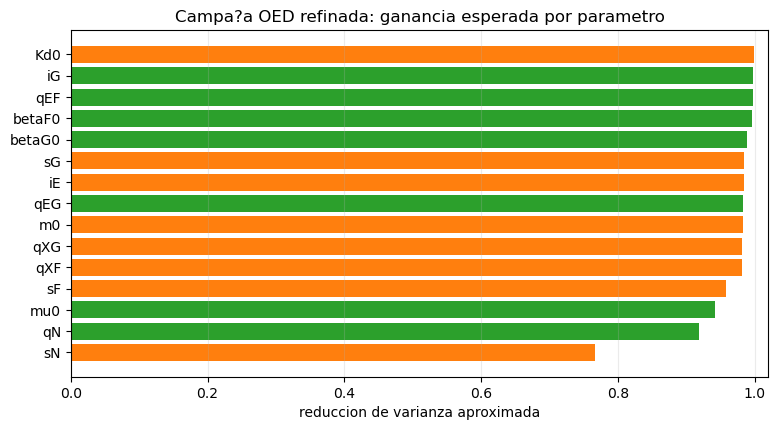

In [18]:

fig, ax = plt.subplots(figsize=(9, 4.5))
plot_df = refined_reduction.sort_values("campaign_var_reduction")
colors = ["tab:green" if g == "accepted_current" else "tab:orange" for g in plot_df["group"]]
ax.barh(plot_df["parameter"], plot_df["campaign_var_reduction"], color=colors)
ax.set_xlabel("reduccion de varianza aproximada")
ax.set_xlim(0, 1.02)
ax.grid(axis="x", alpha=0.25)
ax.set_title("Campa?a OED refinada: ganancia esperada por parametro")
plt.show()



### 13.3 Ensayos de refinamiento local

Cada trial modific? variables continuas dentro de cotas operacionales. Un trial se acepta solo si mejora el score de campa?a completo, no solo la FIM del experimento aislado. Adem?s, el runner rechaza propuestas con warnings de solver durante `compute_FIM()`.


In [19]:

trial_cols = [
    "candidate", "trial", "status", "fim_source", "accepted_best_so_far",
    "targeted_oed_score", "correctable_worst_var_reduction", "error",
]
refined_trials[trial_cols]


,candidate,trial,status,fim_source,accepted_best_so_far,targeted_oed_score,correctable_worst_var_reduction,error
0,glucose_rich_growth_yield,1,ok,computed,True,119.815702,0.728043,NaN
1,glucose_rich_growth_yield,2,ok,computed,False,119.593727,0.716776,NaN
2,fructose_rich_iG_probe,1,ok,computed,True,119.820840,0.728601,NaN
3,fructose_rich_iG_probe,2,ok,computed,False,119.246252,0.737611,NaN
4,combined_stress_long_horizon,1,ok,computed,True,119.959292,0.736690,NaN
5,combined_stress_long_horizon,2,ok,computed,True,120.576471,0.733066,NaN
6,yan_saturation_scan,1,ok,computed,True,121.001249,0.745471,NaN
7,yan_saturation_scan,2,ok,computed,False,119.755225,0.704856,NaN
8,low_temp_growth_separation_plus_co2,1,failed,failed,False,NaN,NaN,RuntimeError: Model from experiment did not so...
9,low_temp_growth_separation_plus_co2,2,ok,computed,True,121.146992,0.749032,NaN



### 13.4 Inputs de la campa?a final

Los gr?ficos siguientes son los inputs manipulables: perfil de temperatura, composici?n inicial y pulsos. Los pulsos se interpretan como adiciones gaussianas de ancho 3 h en el modelo; operacionalmente se pueden implementar como adiciones discretas alrededor del tiempo indicado.


oed_refined_inputs_glucose_rich_growth_yield.png


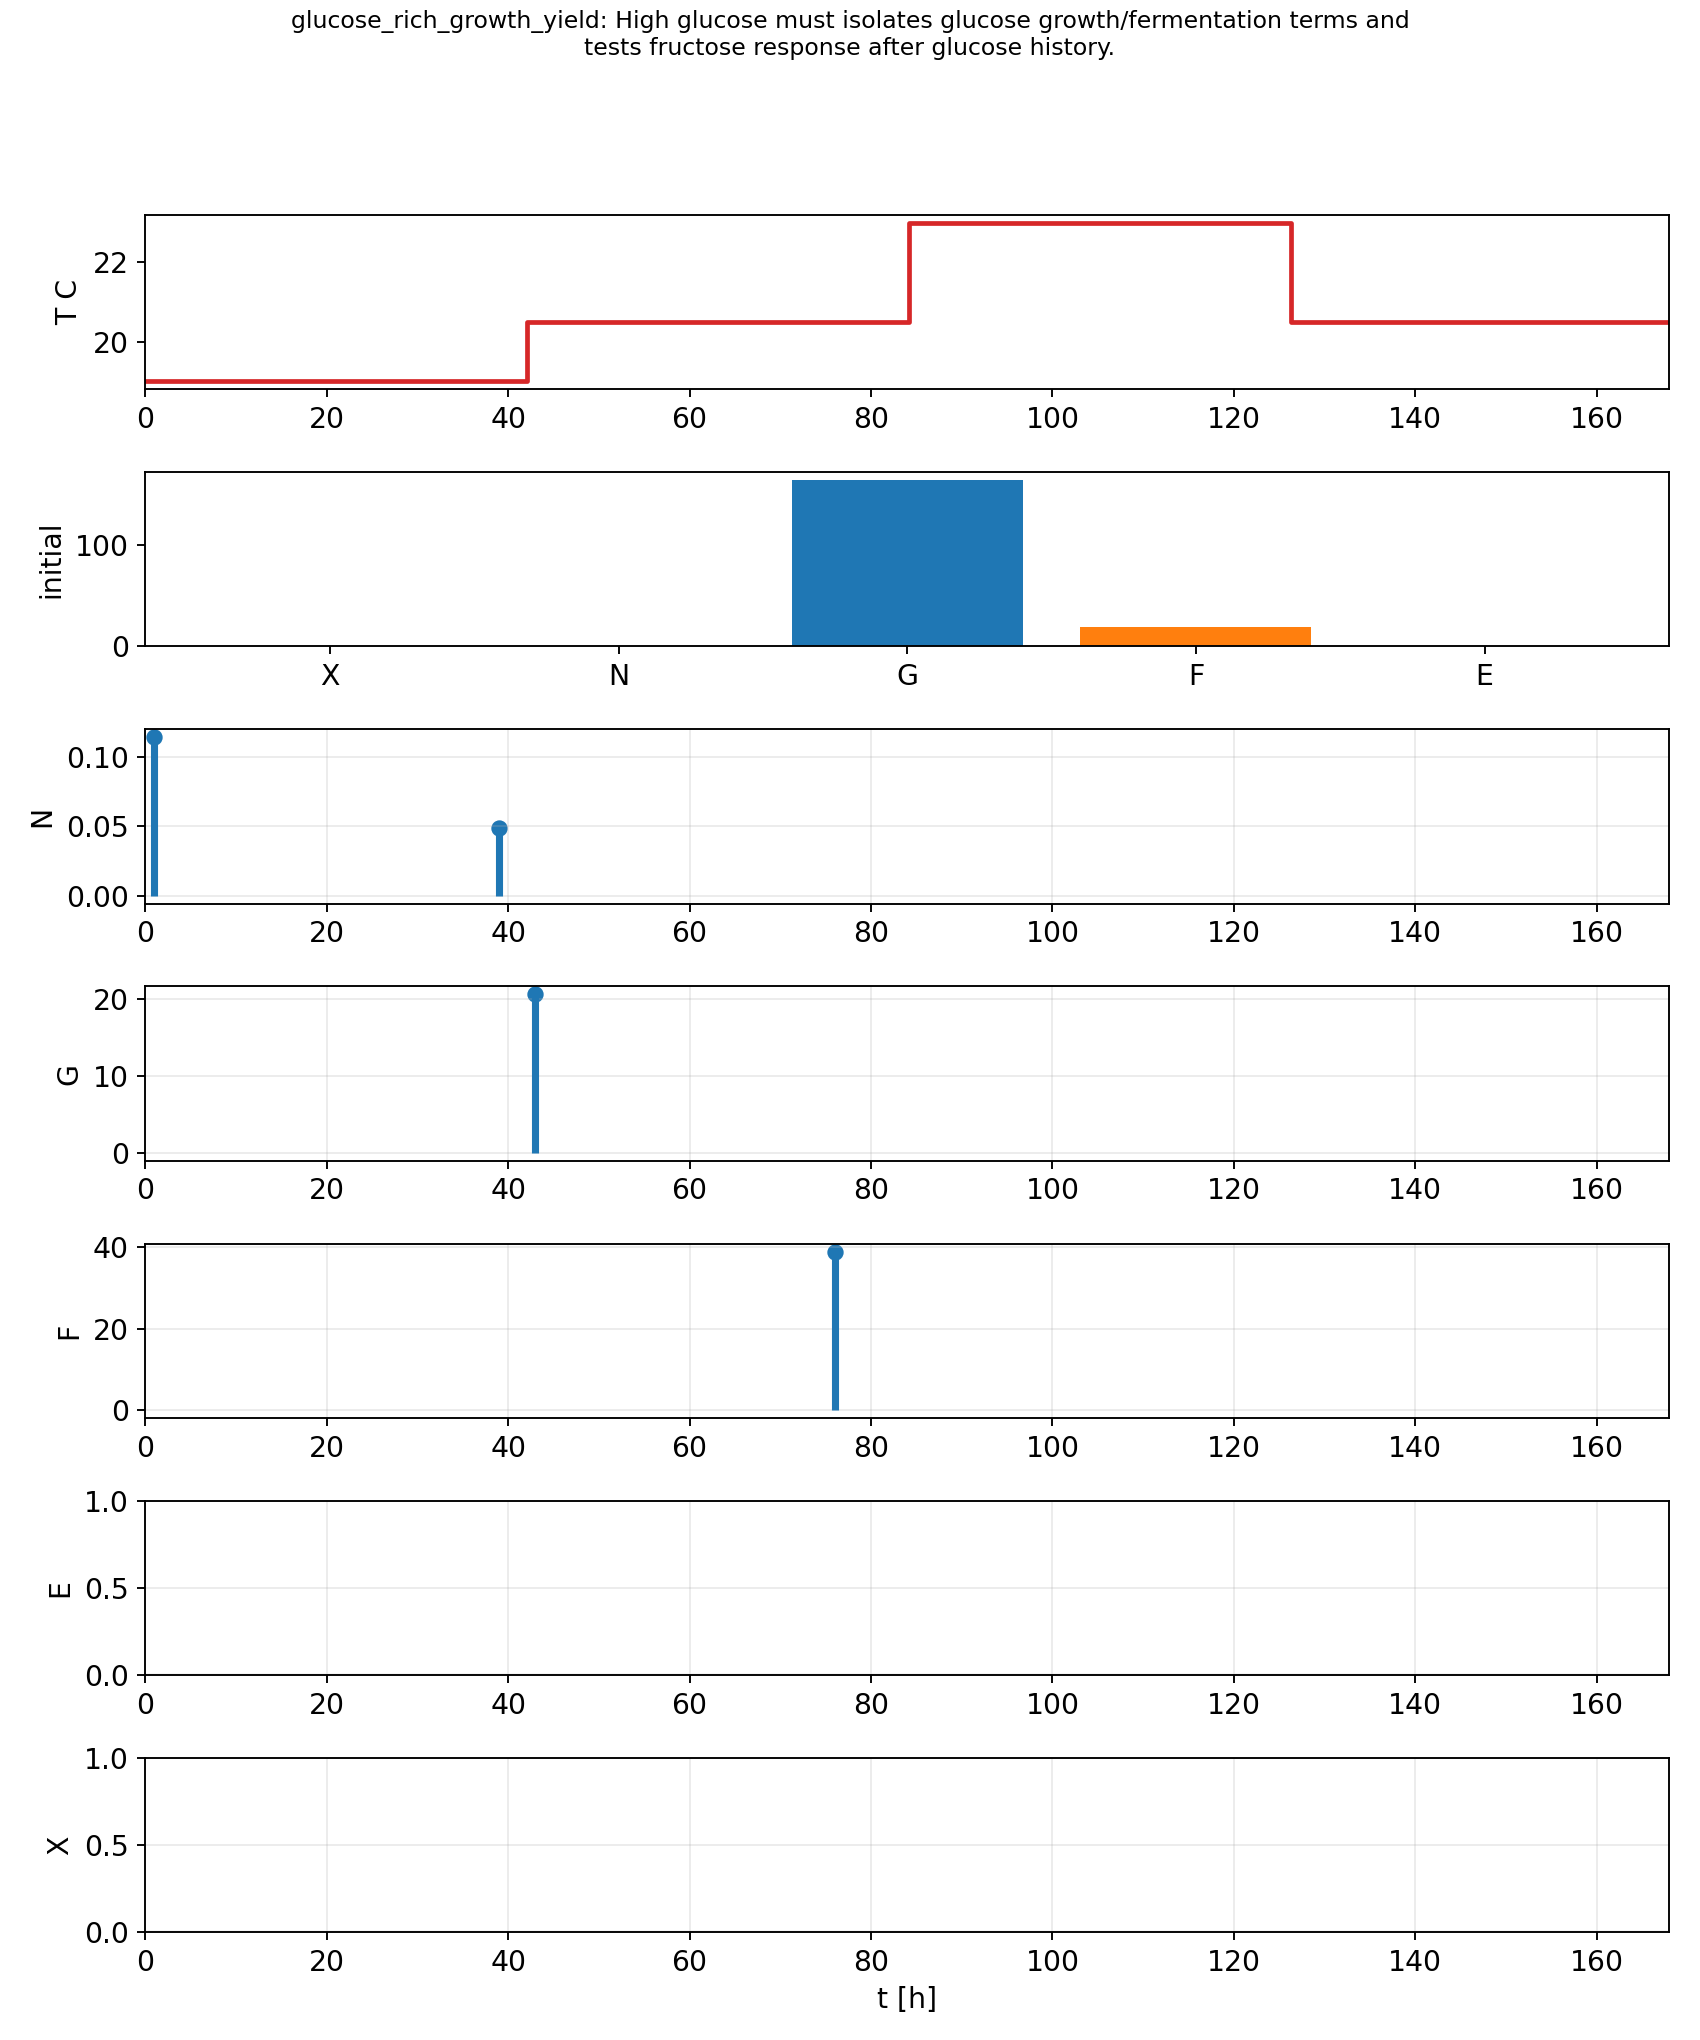

oed_refined_inputs_fructose_rich_iG_probe.png


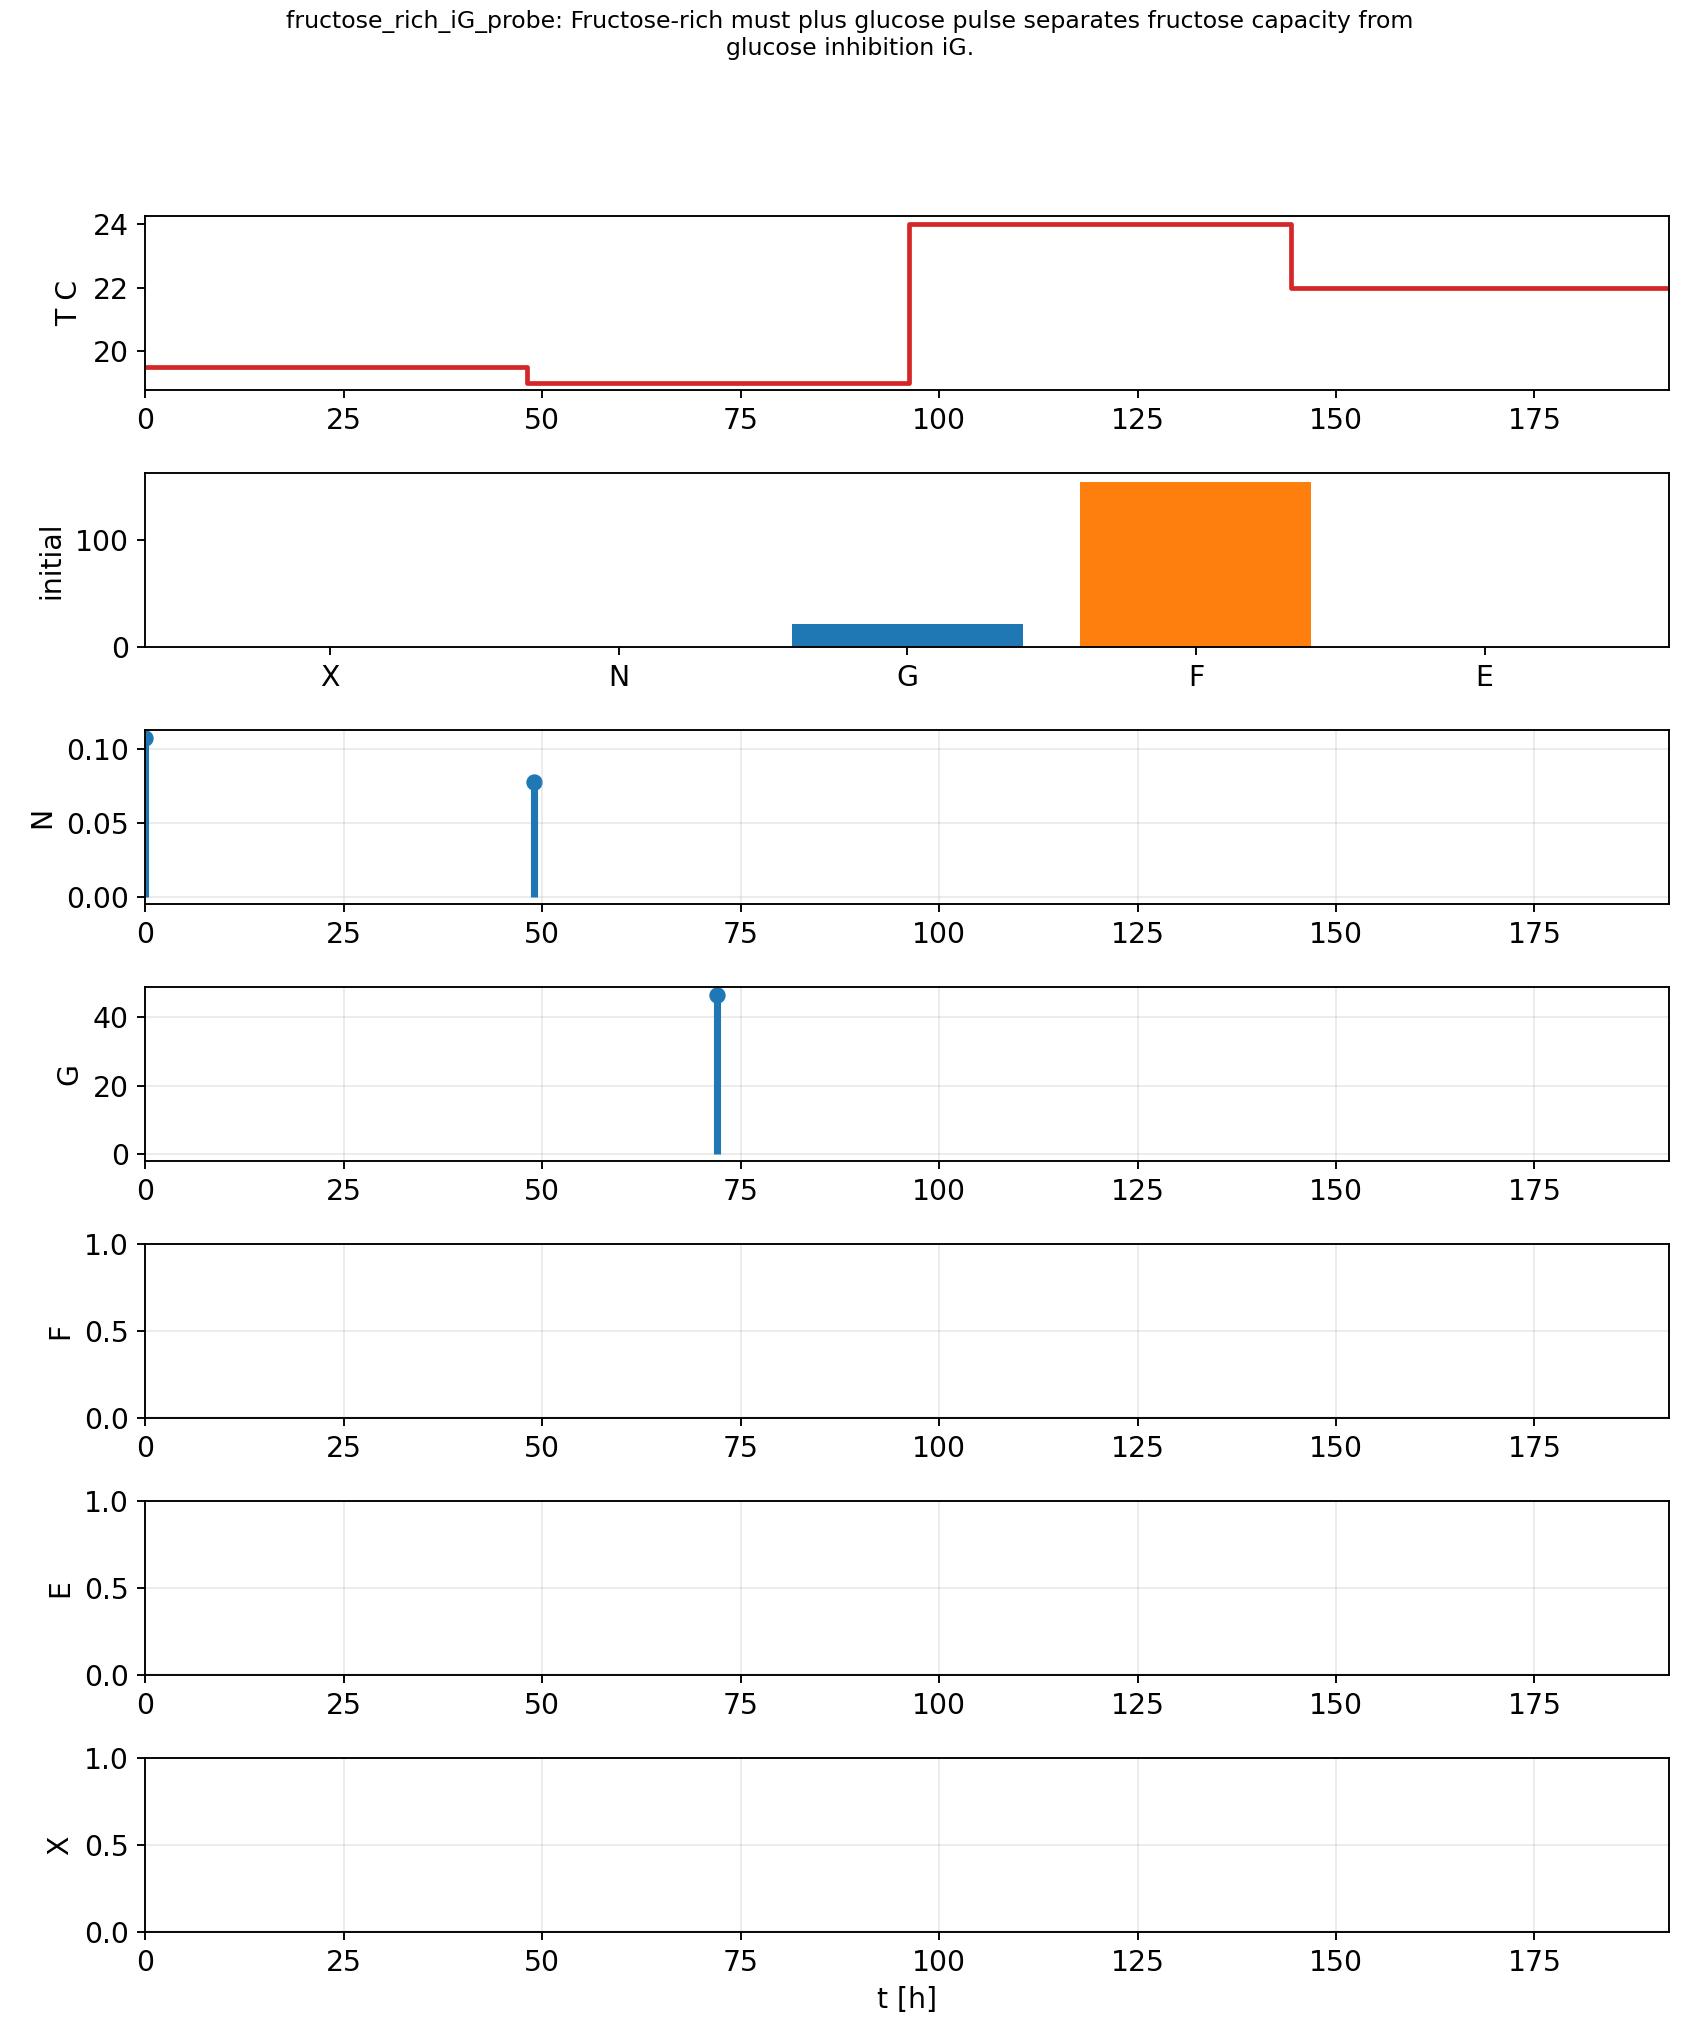

oed_refined_inputs_combined_stress_long_horizon.png


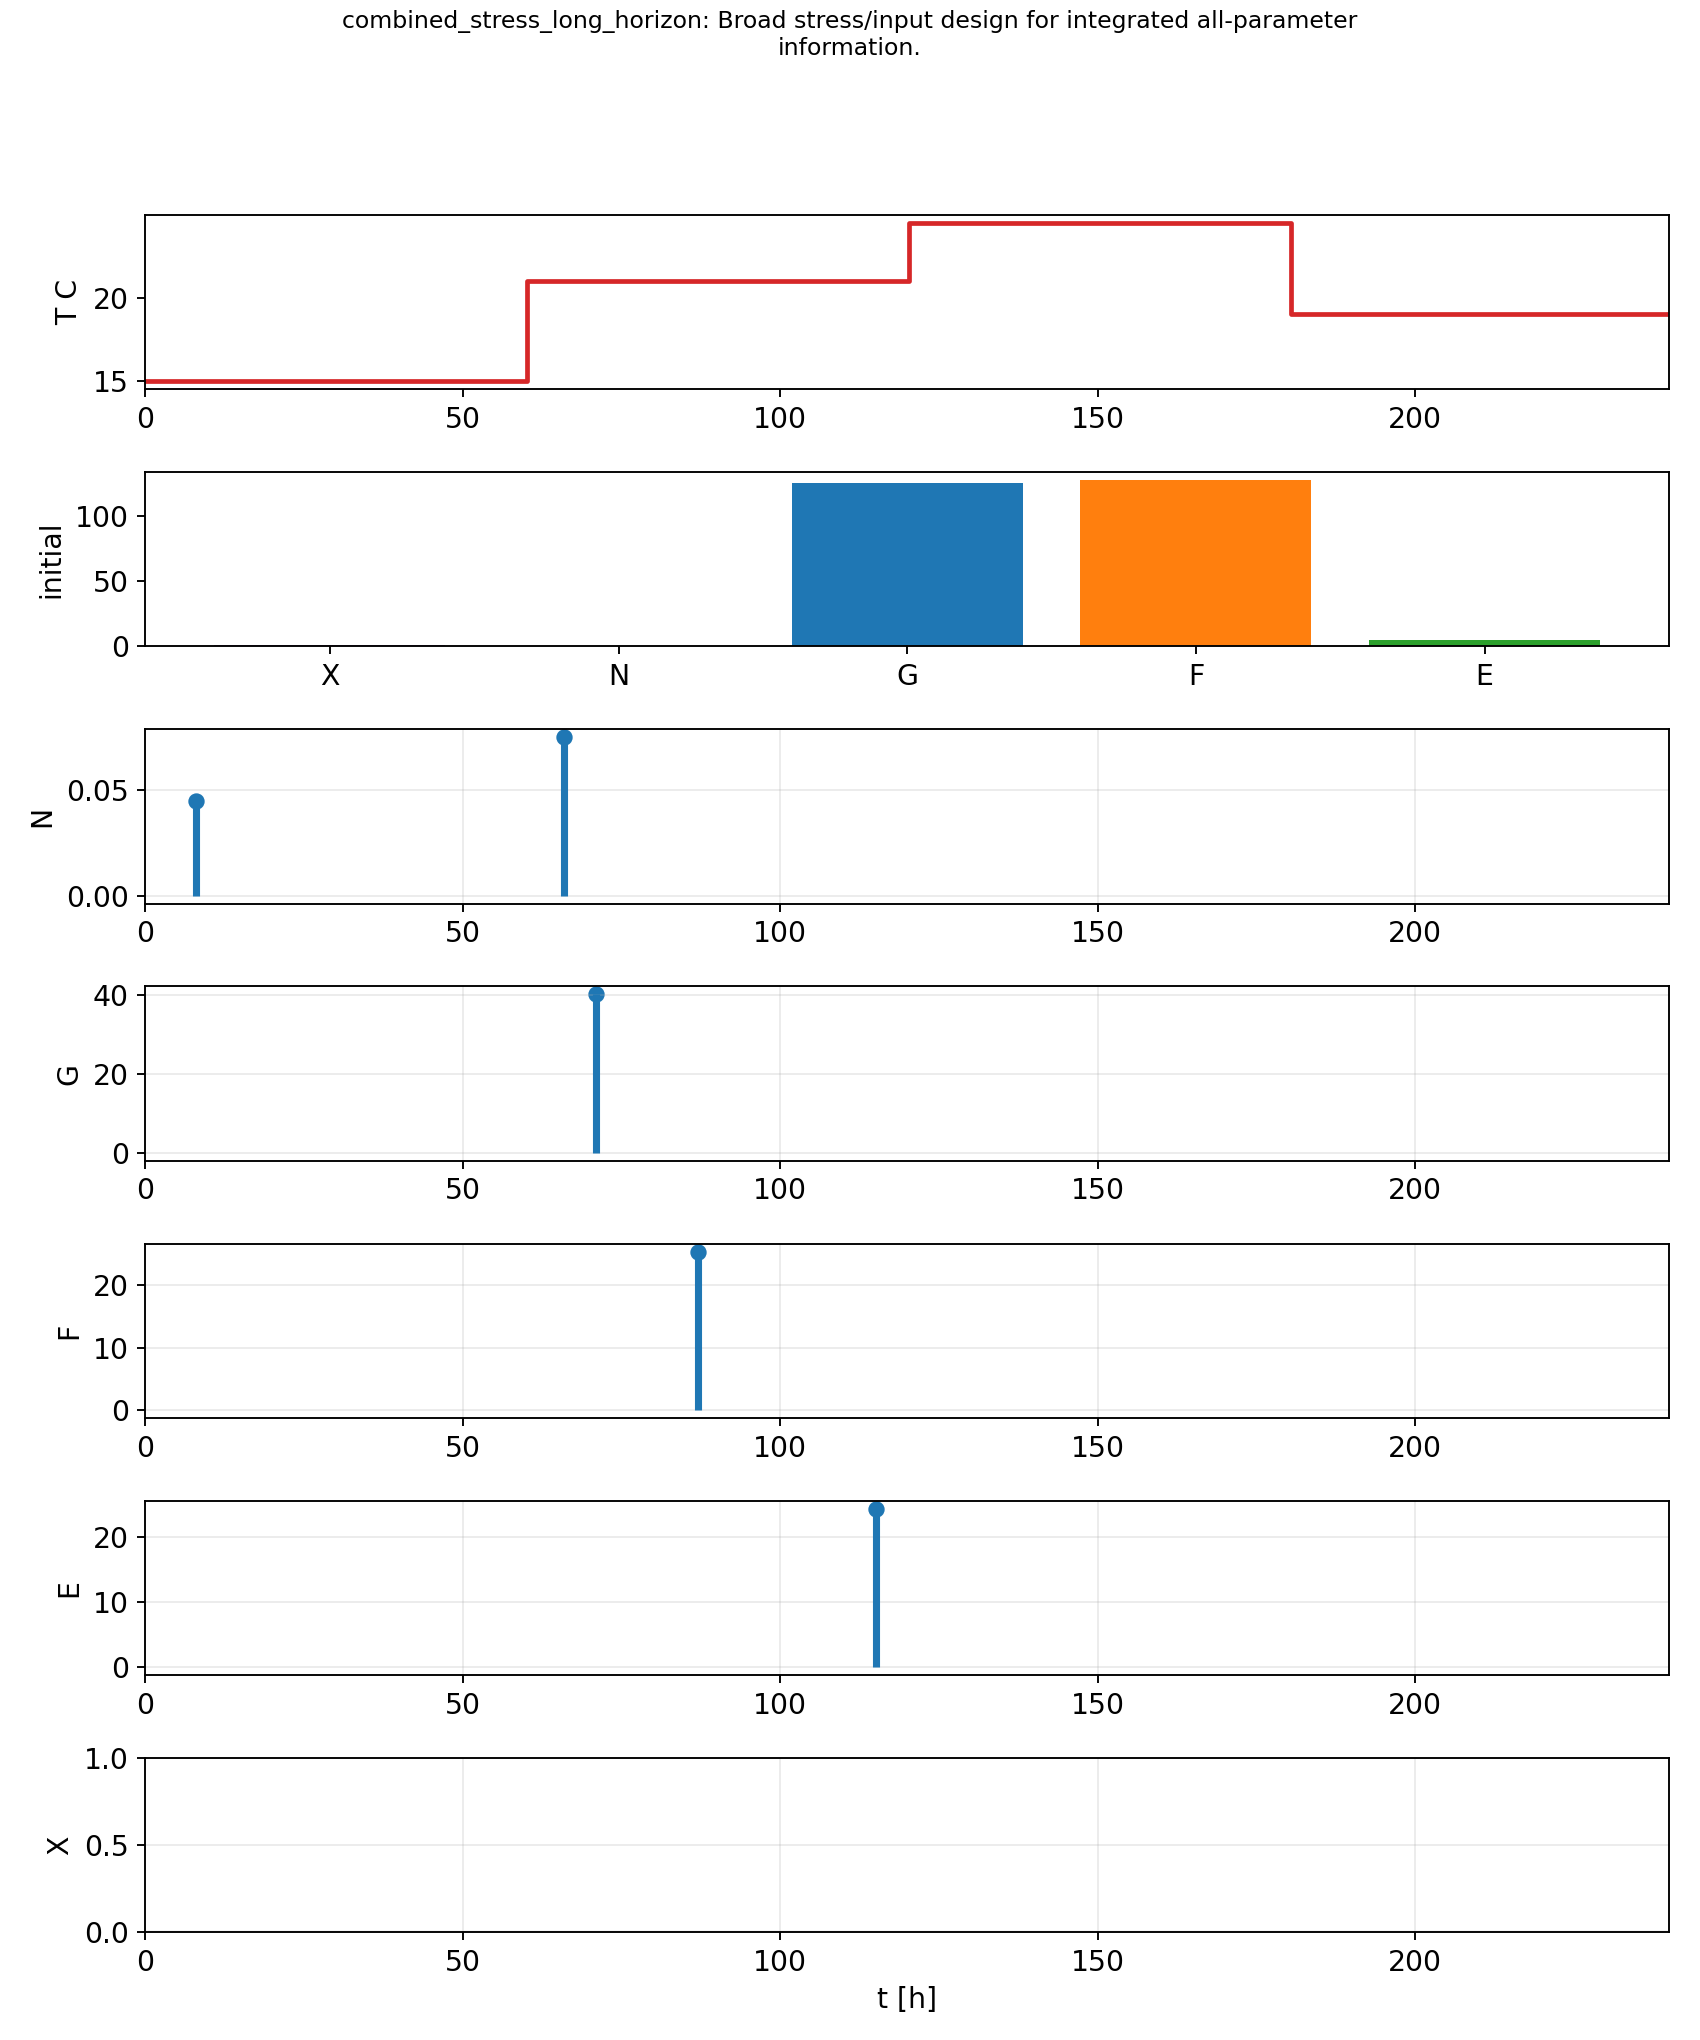

oed_refined_inputs_yan_saturation_scan.png


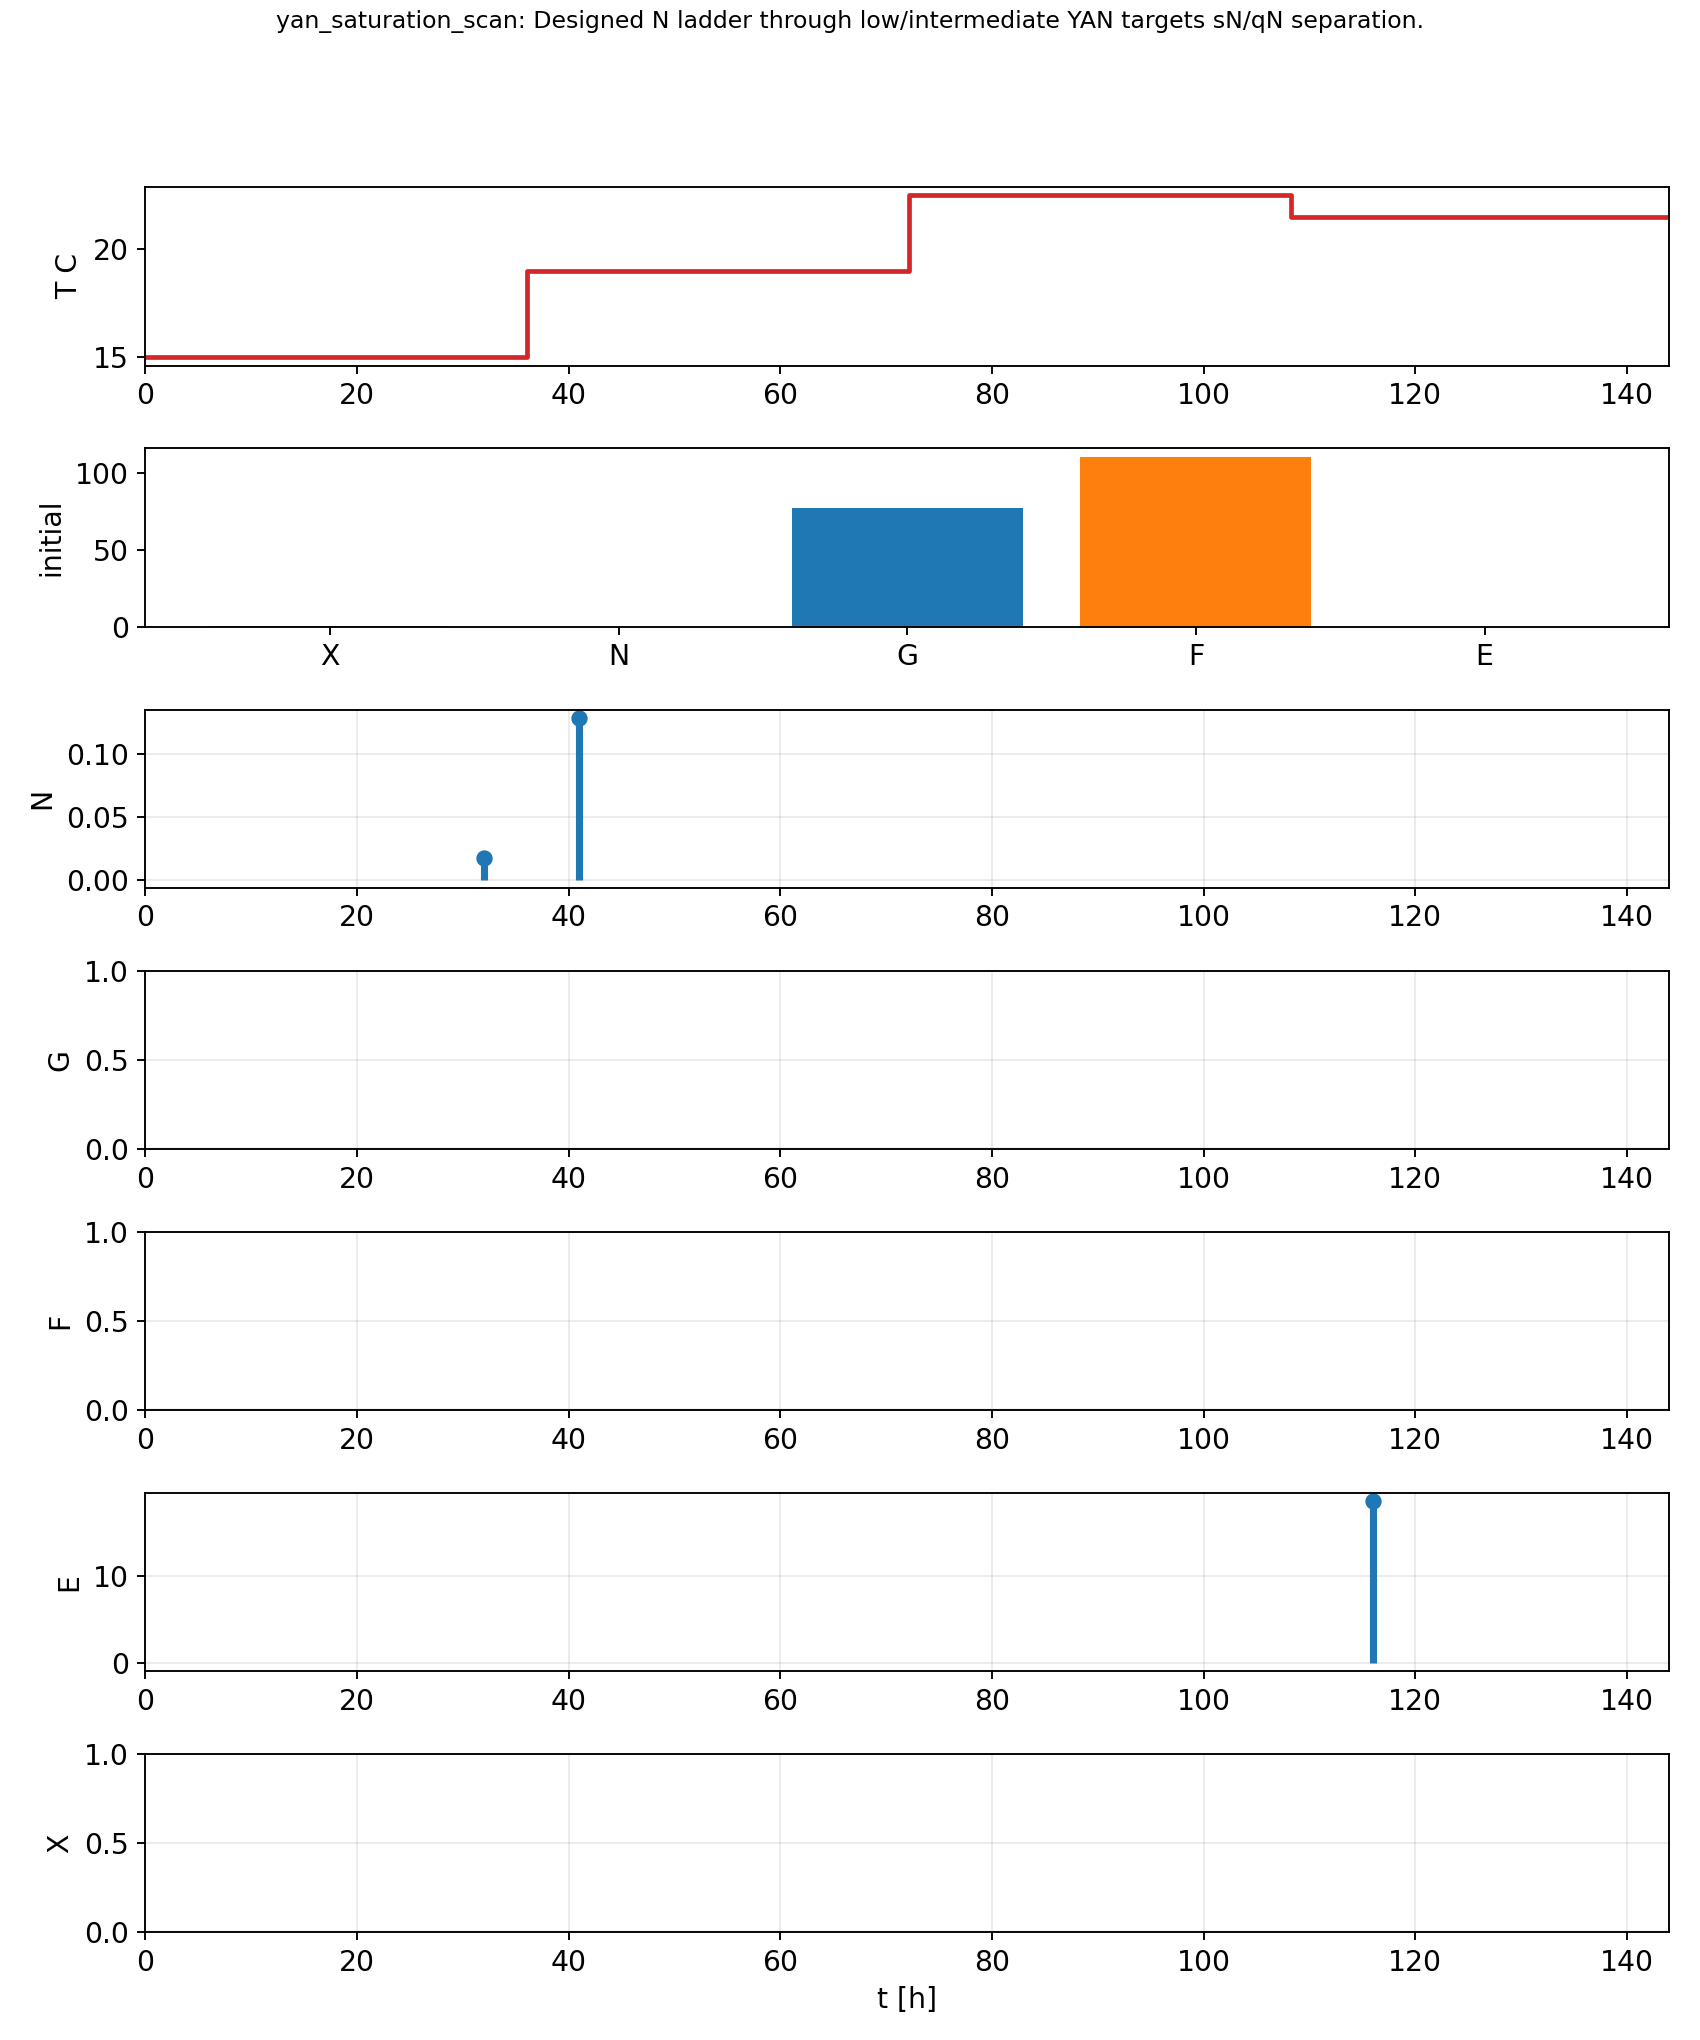

oed_refined_inputs_low_temp_growth_separation_plus_co2.png


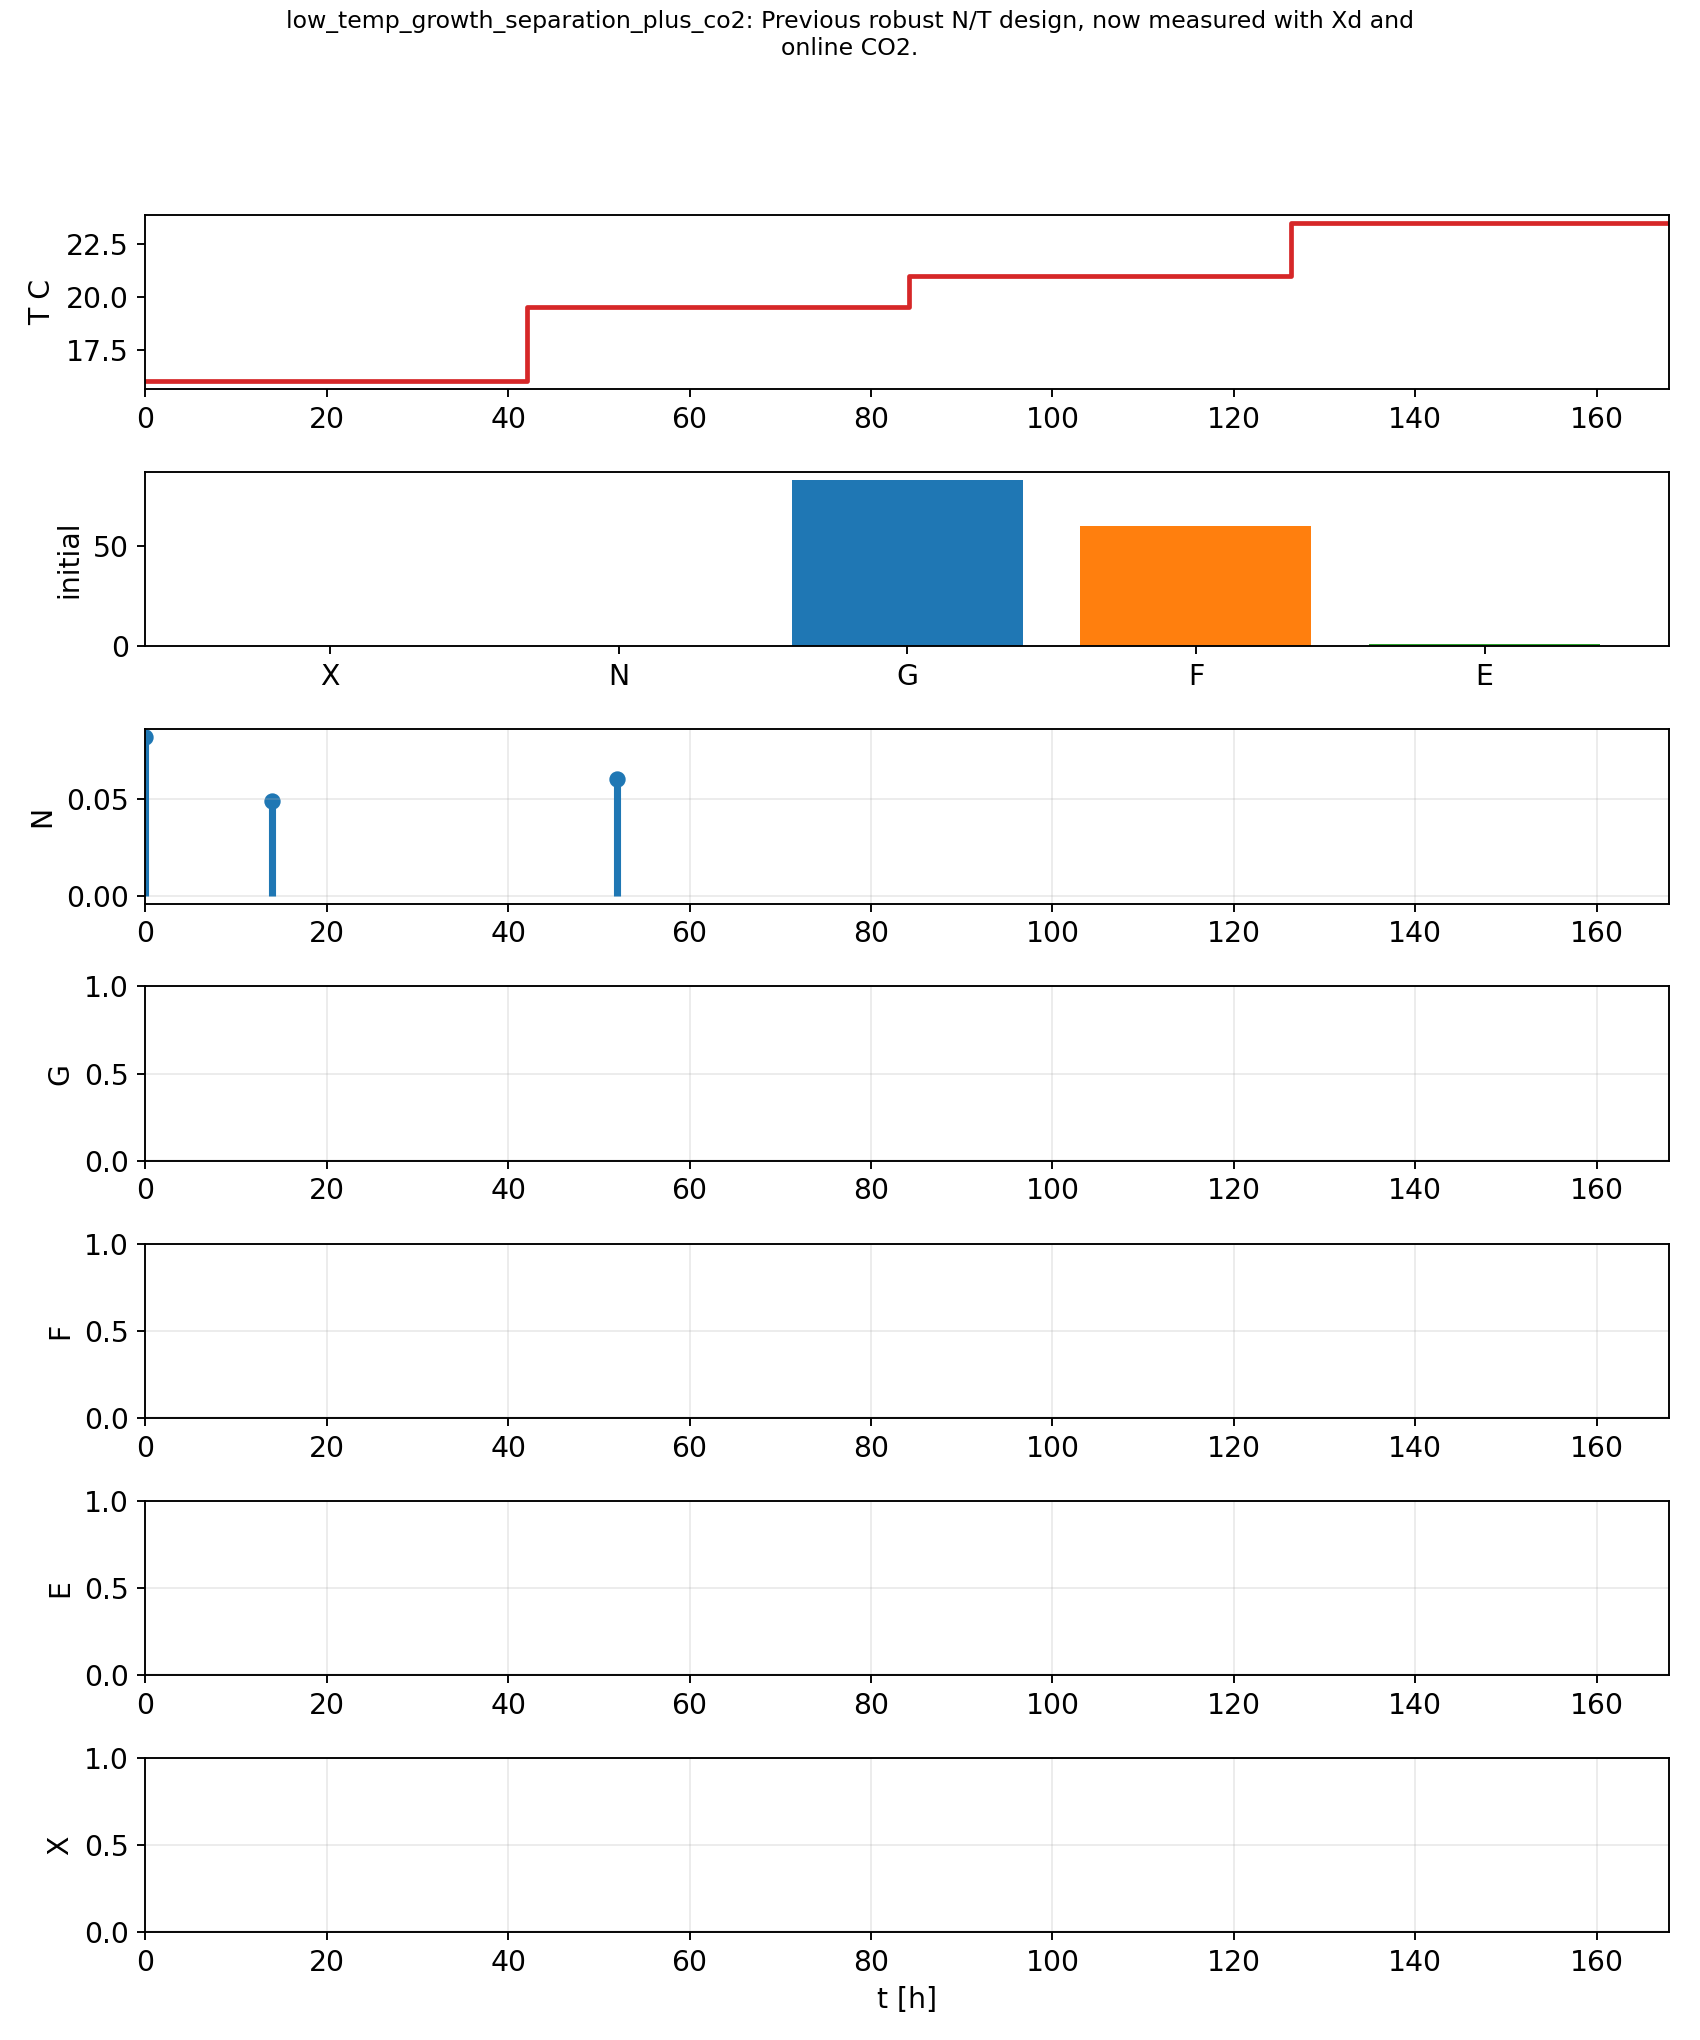

oed_refined_inputs_glucose_pulse_after_N_depletion.png


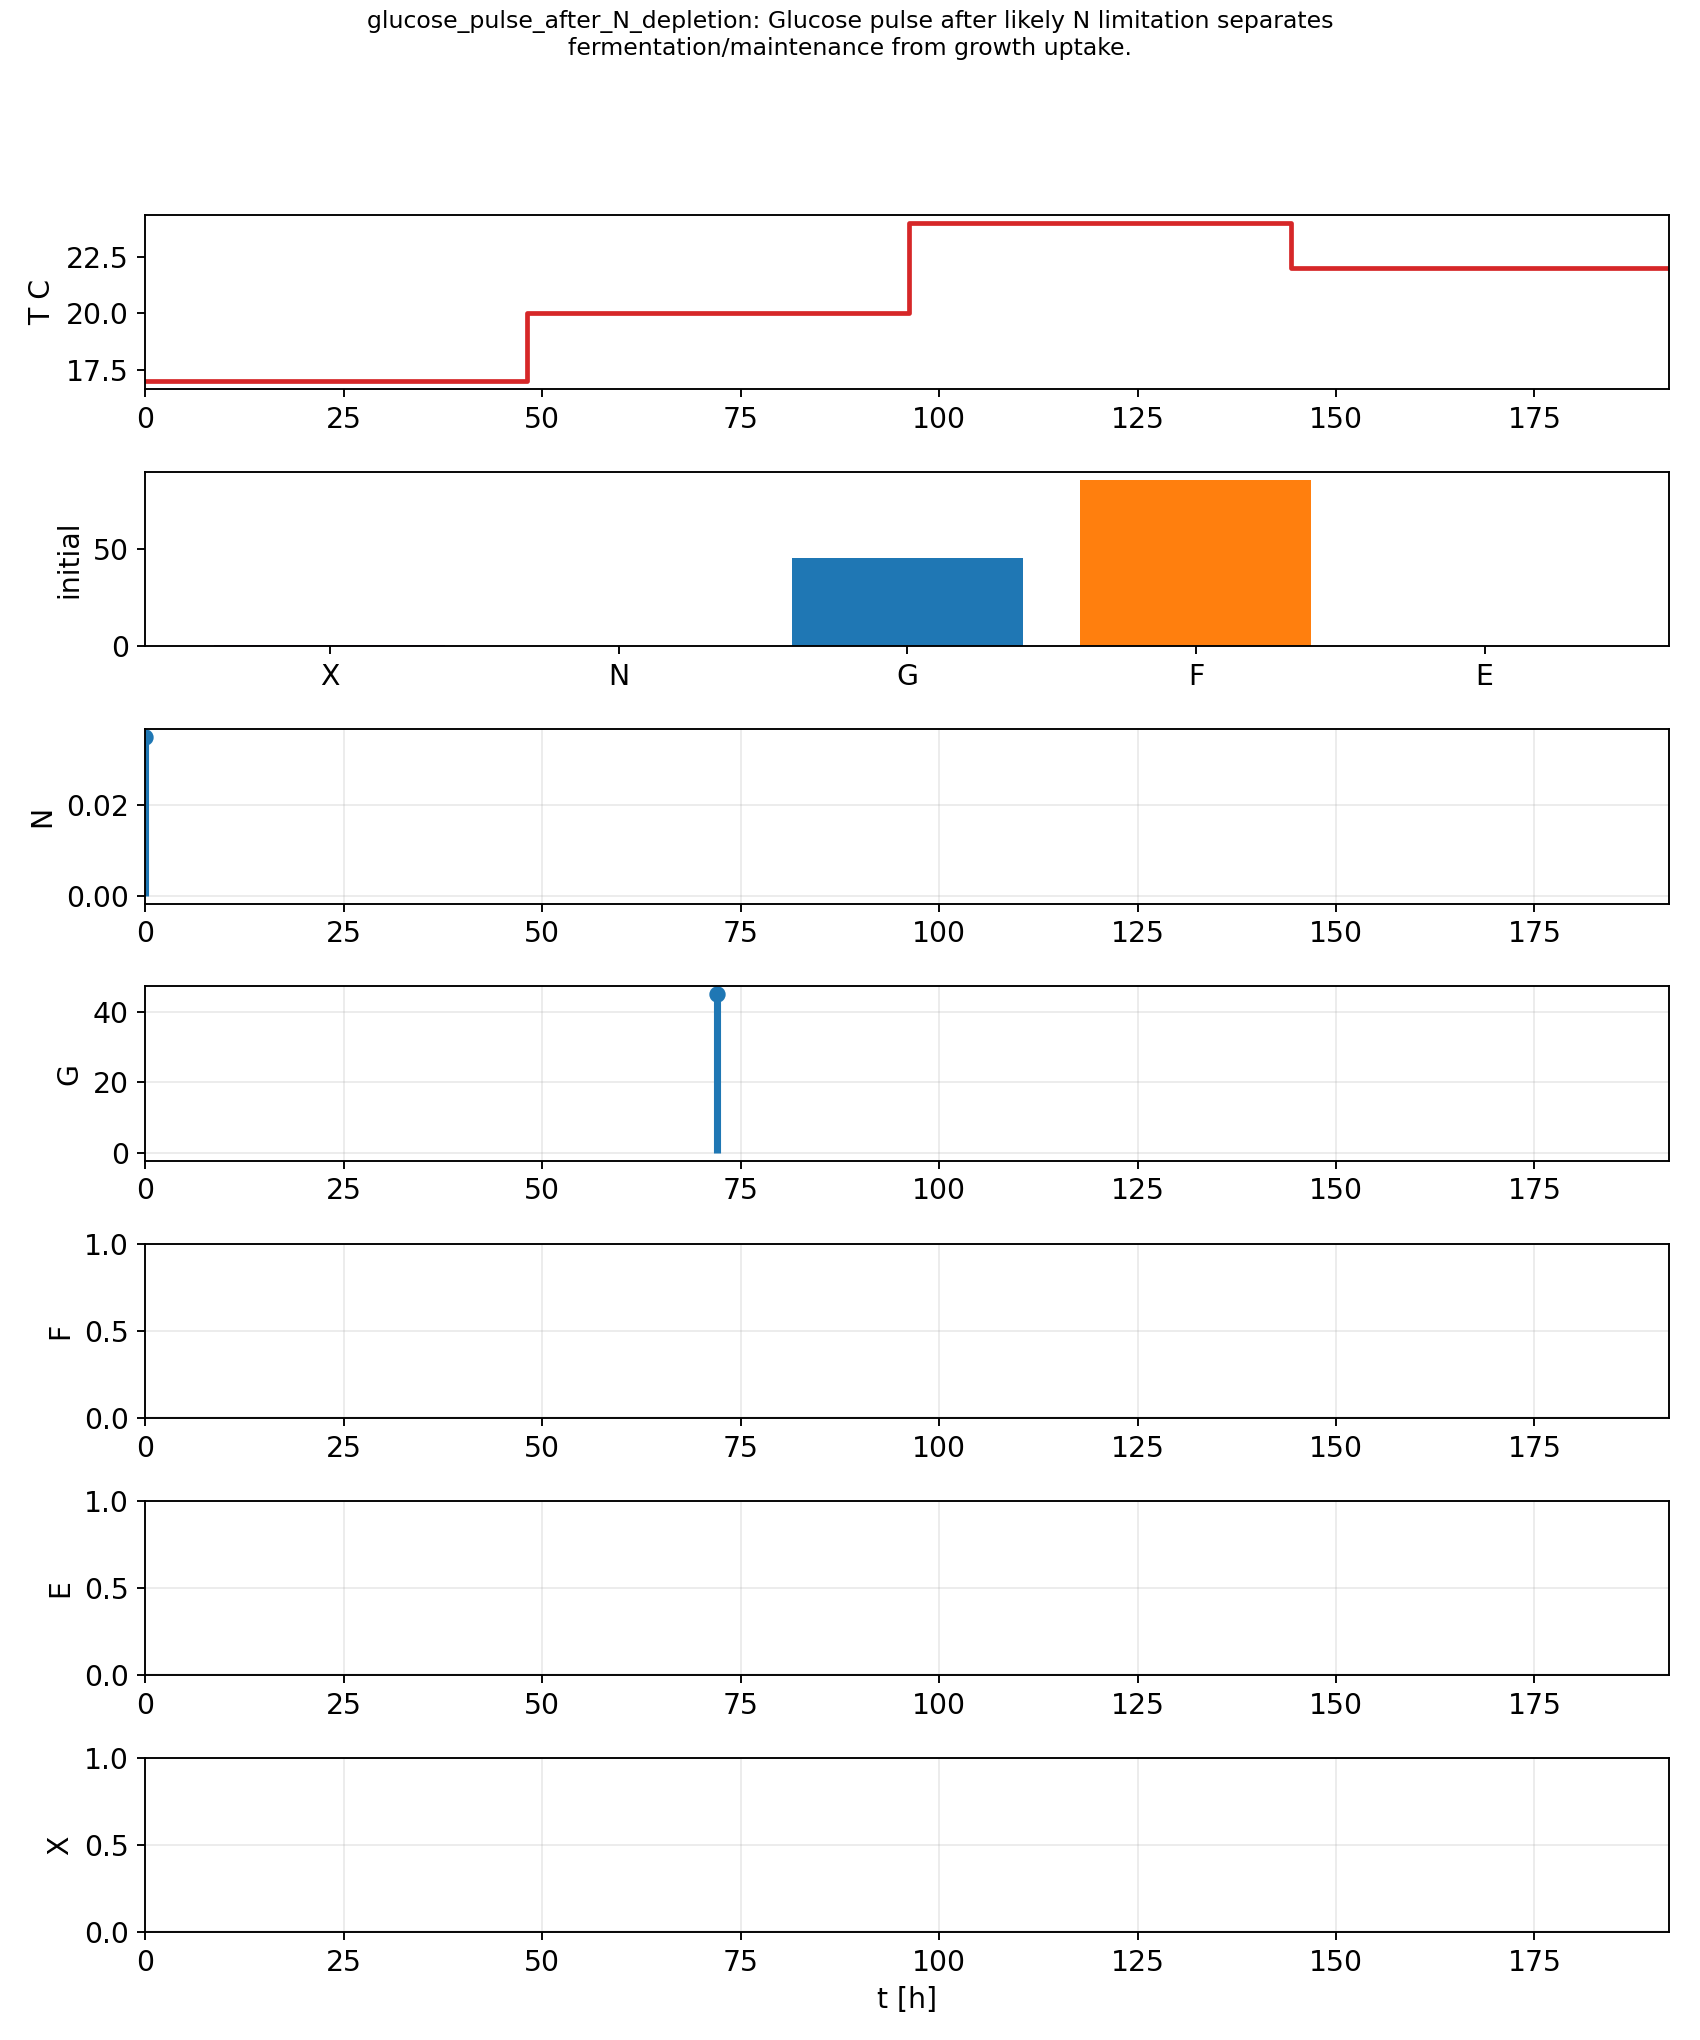

oed_refined_inputs_high_biomass_low_N_maintenance.png


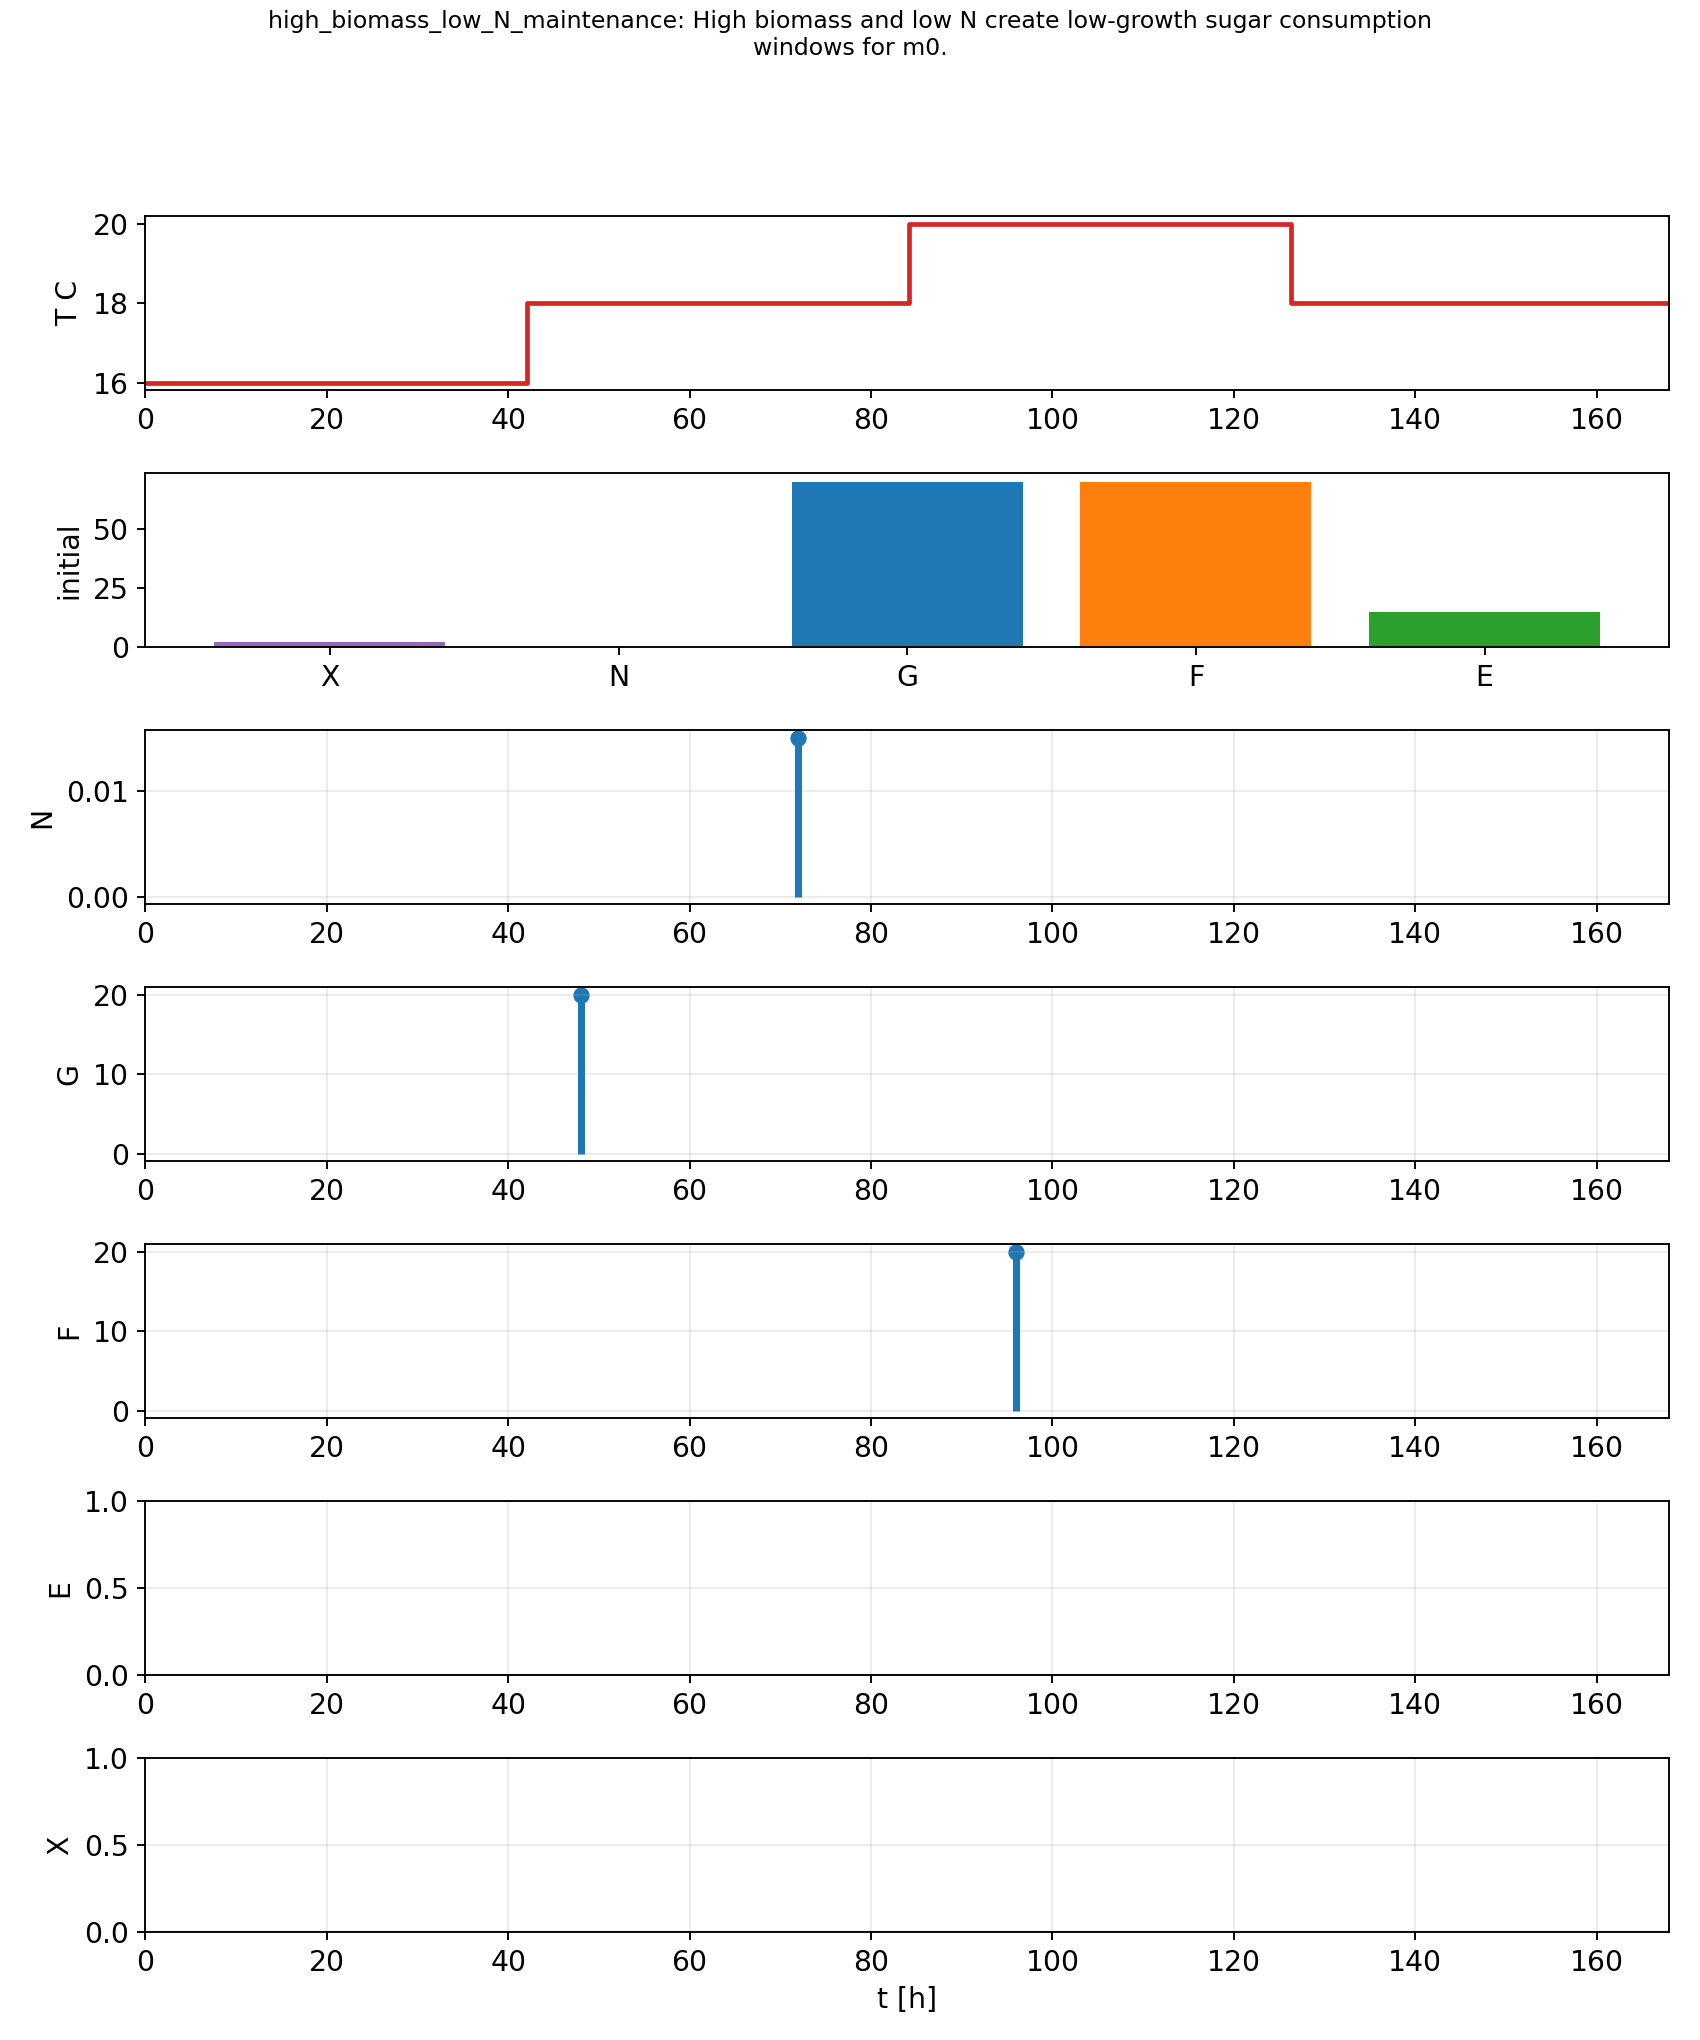

oed_refined_inputs_ethanol_initial_challenge.png


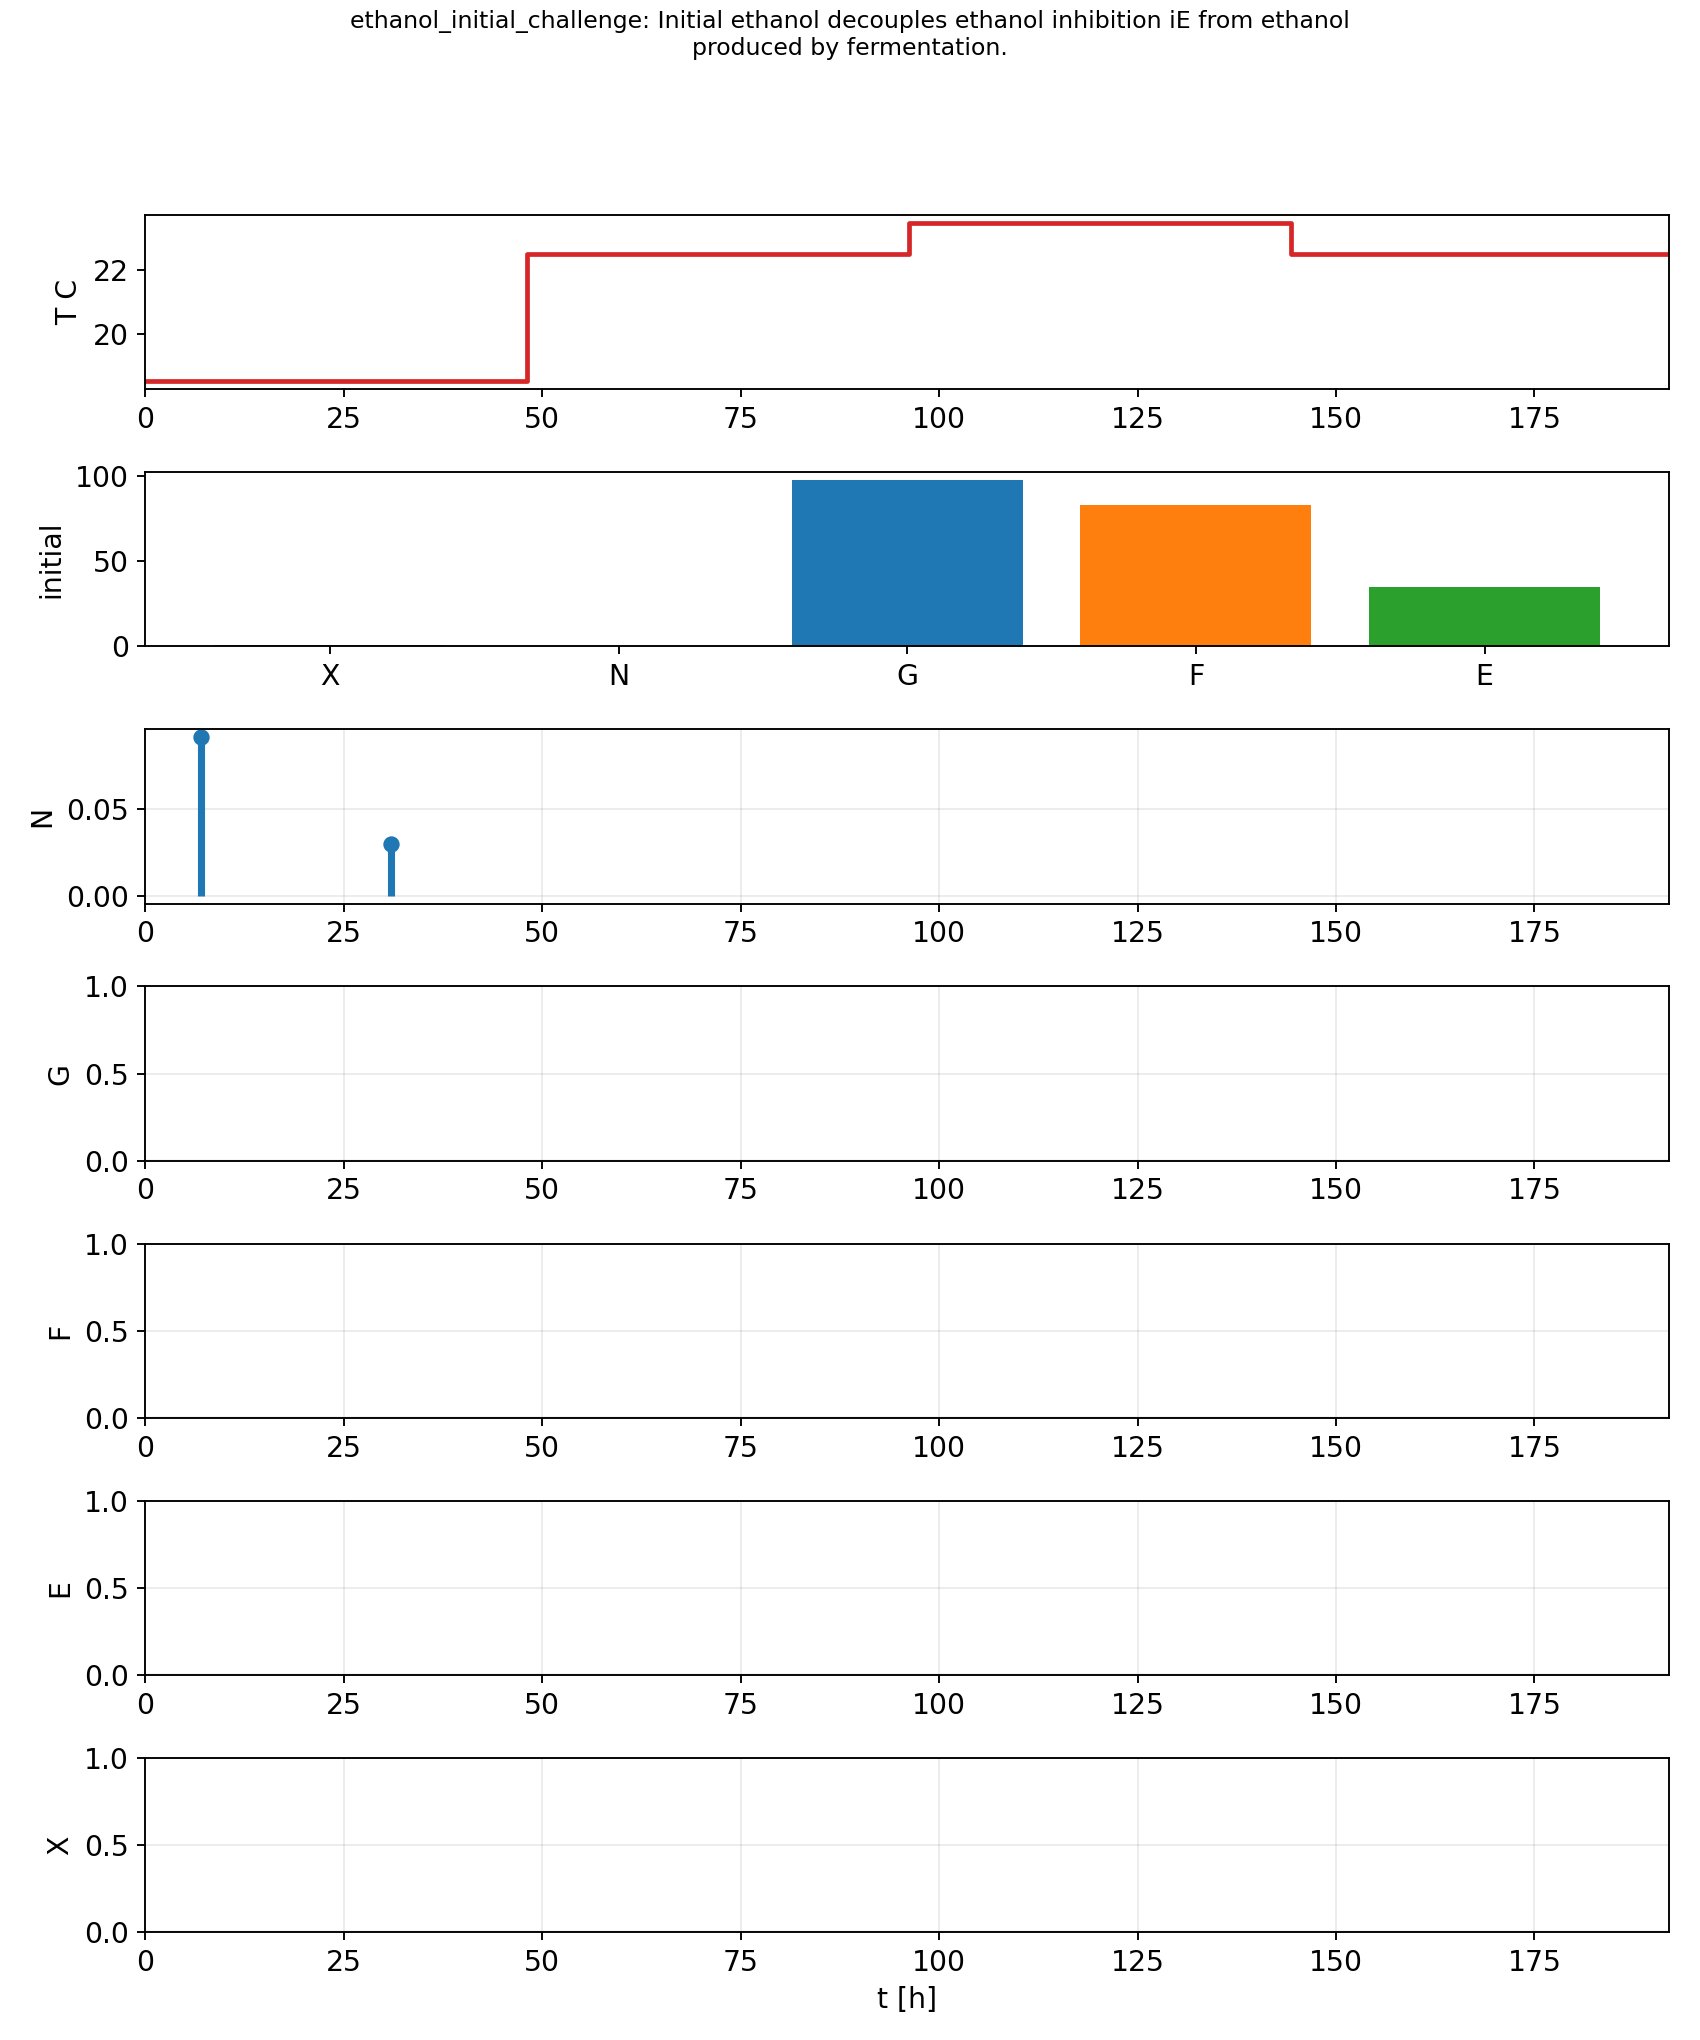

oed_refined_inputs_viable_biomass_step.png


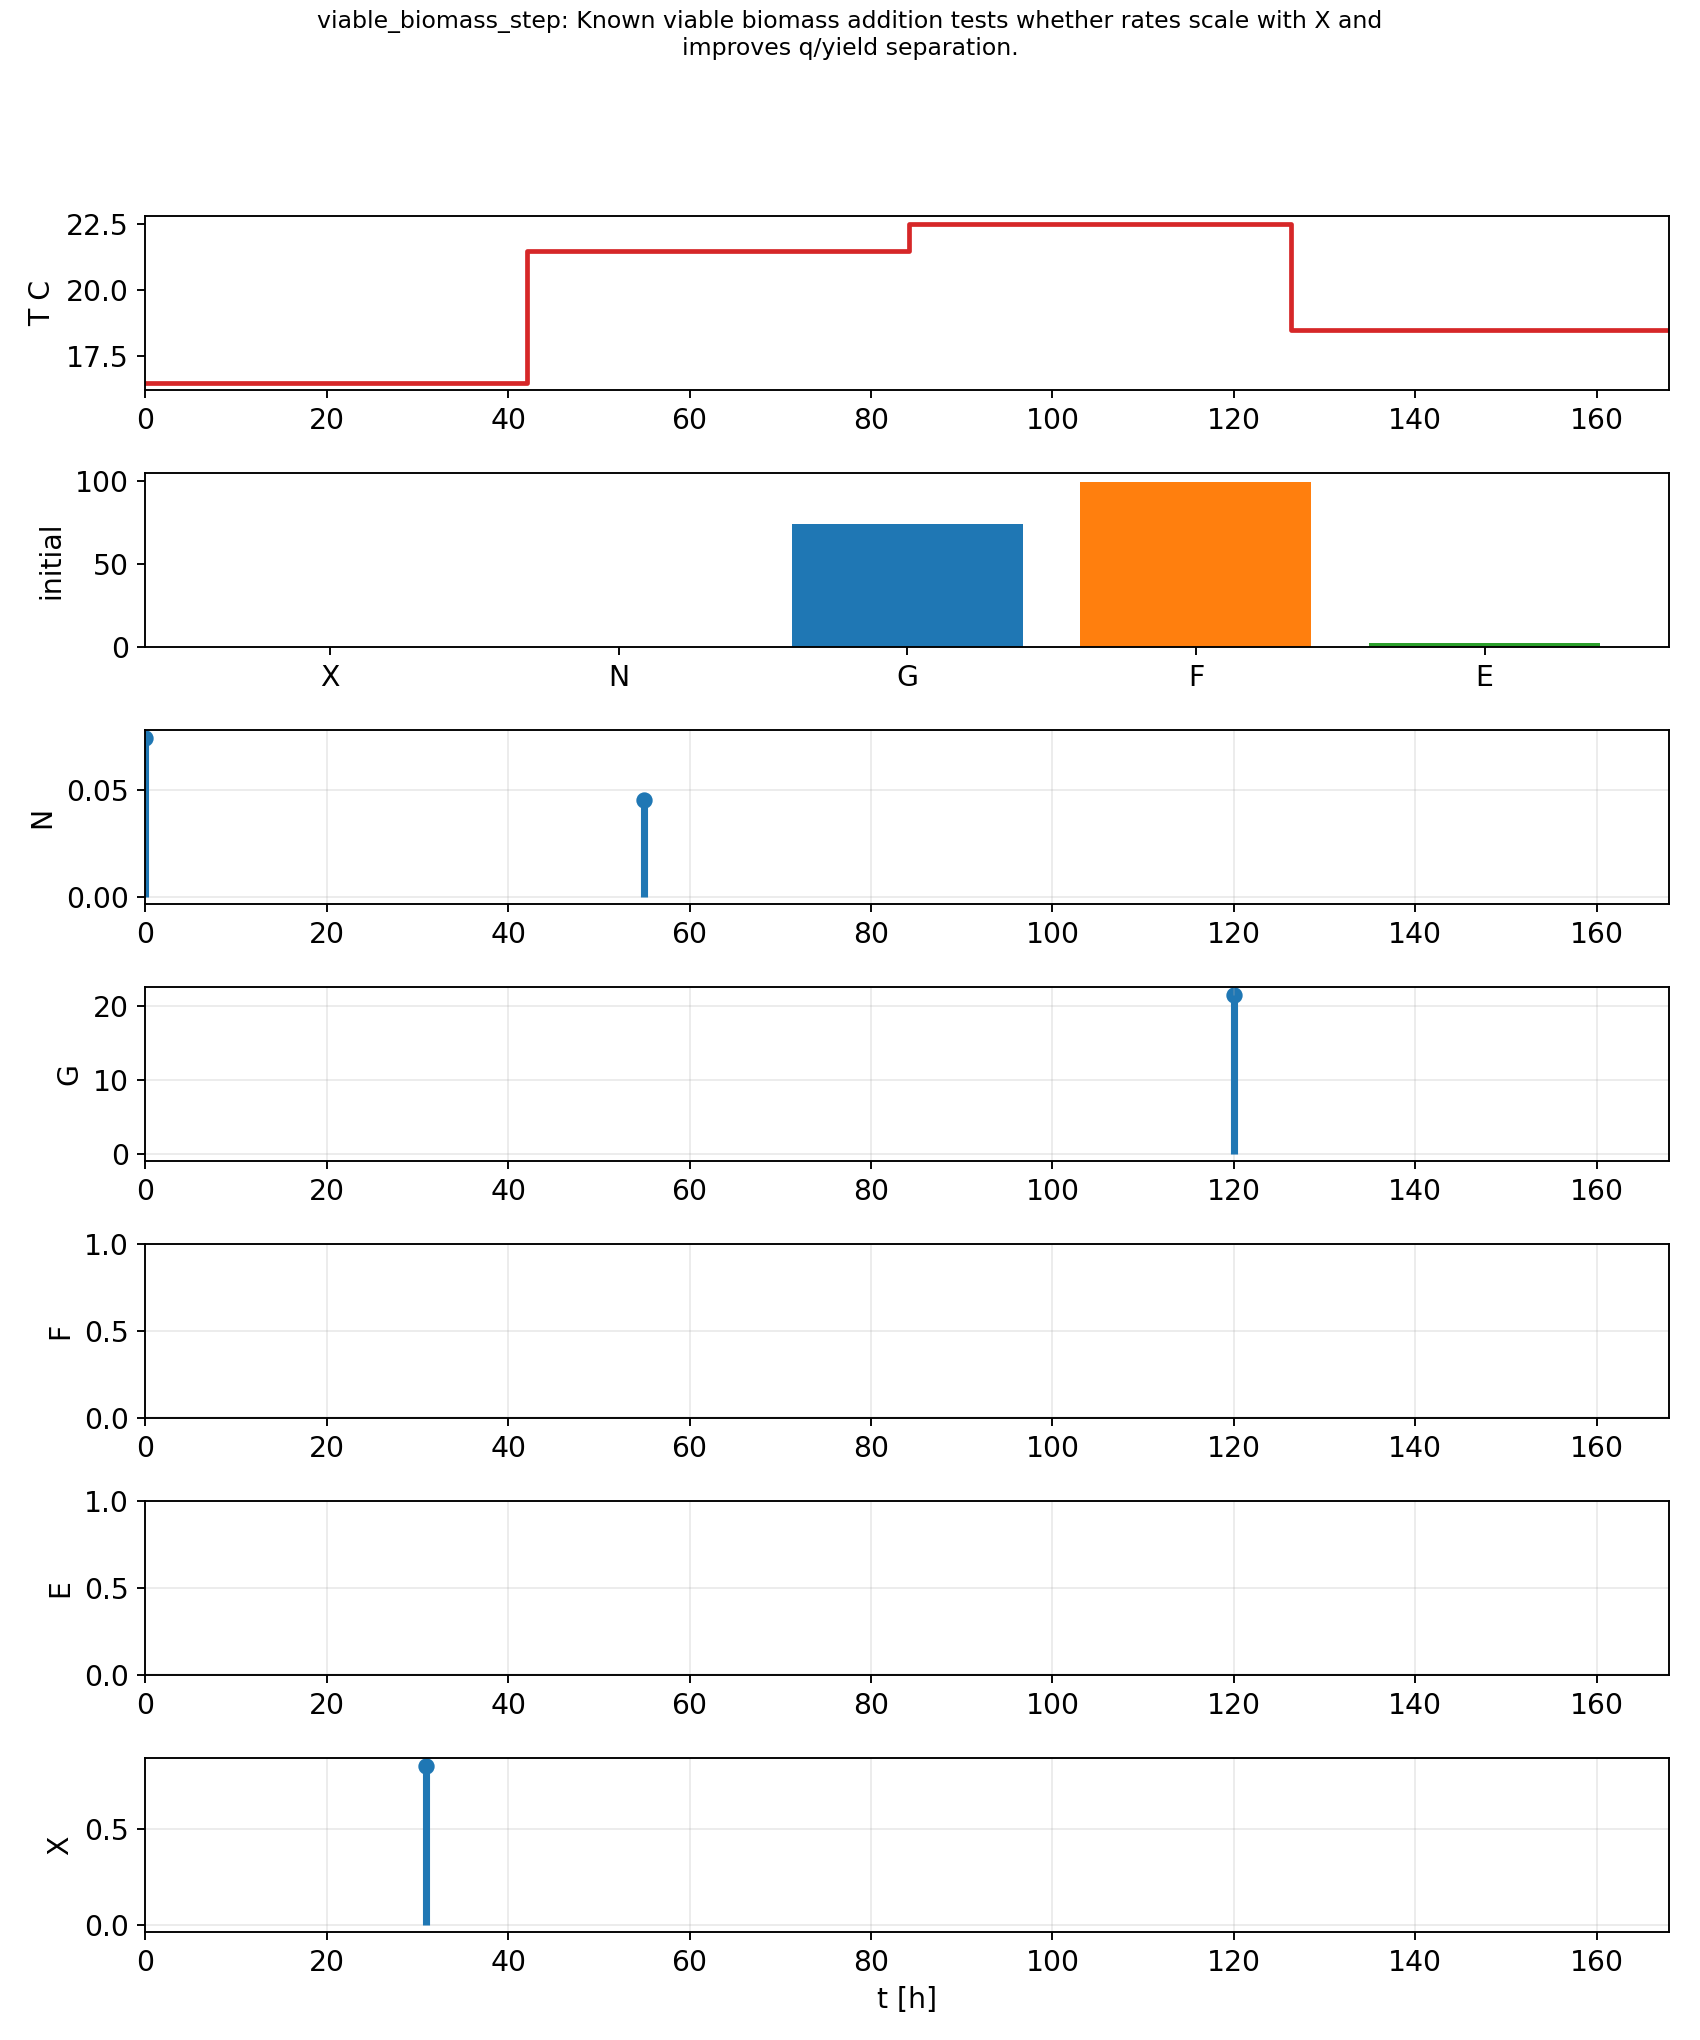

In [20]:

from IPython.display import Image, display

for name in refined_selected["candidate"]:
    path = OED_RESULTS / f"oed_refined_inputs_{name}.png"
    print(path.name)
    display(Image(filename=str(path)))



### 13.5 Simulaci?n nominal final

Estas curvas no son ajuste a datos; son trayectorias nominales con el modelo actual. Su rol es descartar dise?os absurdos antes de llevarlos a laboratorio y anticipar rangos de medici?n para `X`, `Xd`, `N`, `G`, `F`, `E` y `CO2`.


In [21]:

refined_sim = pd.read_csv(OED_RESULTS / "oed_refined_simulations.csv")
states = ["X", "Xd", "N", "G", "F", "E", "CO2"]

print(refined_sim.groupby("candidate")["termination"].unique())
refined_sim.groupby("candidate")[states].agg(["min", "max"]).round(4)


candidate
combined_stress_long_horizon           [optimal]
ethanol_initial_challenge              [optimal]
fructose_rich_iG_probe                 [optimal]
glucose_pulse_after_N_depletion        [optimal]
glucose_rich_growth_yield              [optimal]
high_biomass_low_N_maintenance         [optimal]
low_temp_growth_separation_plus_co2    [optimal]
viable_biomass_step                    [optimal]
yan_saturation_scan                    [optimal]
Name: termination, dtype: object


X           Xd            N          \
                                        min     max  min     max  min     max   
candidate                                                                       
combined_stress_long_horizon         0.7437  4.3390  0.0  3.5694 -0.0  0.1879   
ethanol_initial_challenge            0.6094  4.6887  0.0  3.2149 -0.0  0.2538   
fructose_rich_iG_probe               0.3953  5.3053  0.0  2.2739 -0.0  0.3256   
glucose_pulse_after_N_depletion      0.5500  1.6021  0.0  0.0000 -0.0  0.0772   
glucose_rich_growth_yield            0.4988  5.0962  0.0  1.6023 -0.0  0.3208   
high_biomass_low_N_maintenance       2.2000  2.6676  0.0  0.1040 -0.0  0.0250   
low_temp_growth_separation_plus_co2  0.4176  5.1669  0.0  0.9768  0.0  0.2842   
viable_biomass_step                  0.2857  5.5240  0.0  1.1731  0.0  0.3229   
yan_saturation_scan                  0.3251  2.5422  0.0  0.1336 -0.0  0.0527   

                                           G                   F            \
                                         min       max       min       max   
candidate                                                                    
combined_stress_long_horizon         52.8820  125.8647  104.7098  128.9162   
ethanol_initial_challenge             9.8921   97.2997   22.7459   82.8473   
fructose_rich_iG_probe                0.3484   39.9833   22.0281  154.6645   
glucose_pulse_after_N_depletion      20.7615   61.6604   41.3470   85.0000   
glucose_rich_growth_yield            46.3668  164.5034    5.4122   41.2553   
high_biomass_low_N_maintenance       21.3684   70.0000   49.4459   70.0000   
low_temp_growth_separation_plus_co2   0.1273   82.6922    0.1222   59.9039   
viable_biomass_step                   3.5679   74.2613   10.8292   99.6229   
yan_saturation_scan                  17.0745   77.0338   67.7329  110.2948   

                                           E            CO2            
                                         min       max  min       max  
candidate                                                              
combined_stress_long_horizon          5.1880  136.2891  0.0  101.9924  
ethanol_initial_challenge            34.5888  127.2147  0.0   88.4842  
fructose_rich_iG_probe                0.0000  116.2321  0.0  111.0349  
glucose_pulse_after_N_depletion       0.0000   69.5060  0.0   66.3980  
glucose_rich_growth_yield             0.2828  118.9258  0.0  113.3380  
high_biomass_low_N_maintenance       15.0000   86.9061  0.0   68.6908  
low_temp_growth_separation_plus_co2   1.2160   89.1669  0.0   84.0182  
viable_biomass_step                   2.8078  112.2626  0.0  104.5606  
yan_saturation_scan                   0.0000   84.6101  0.0   63.1557

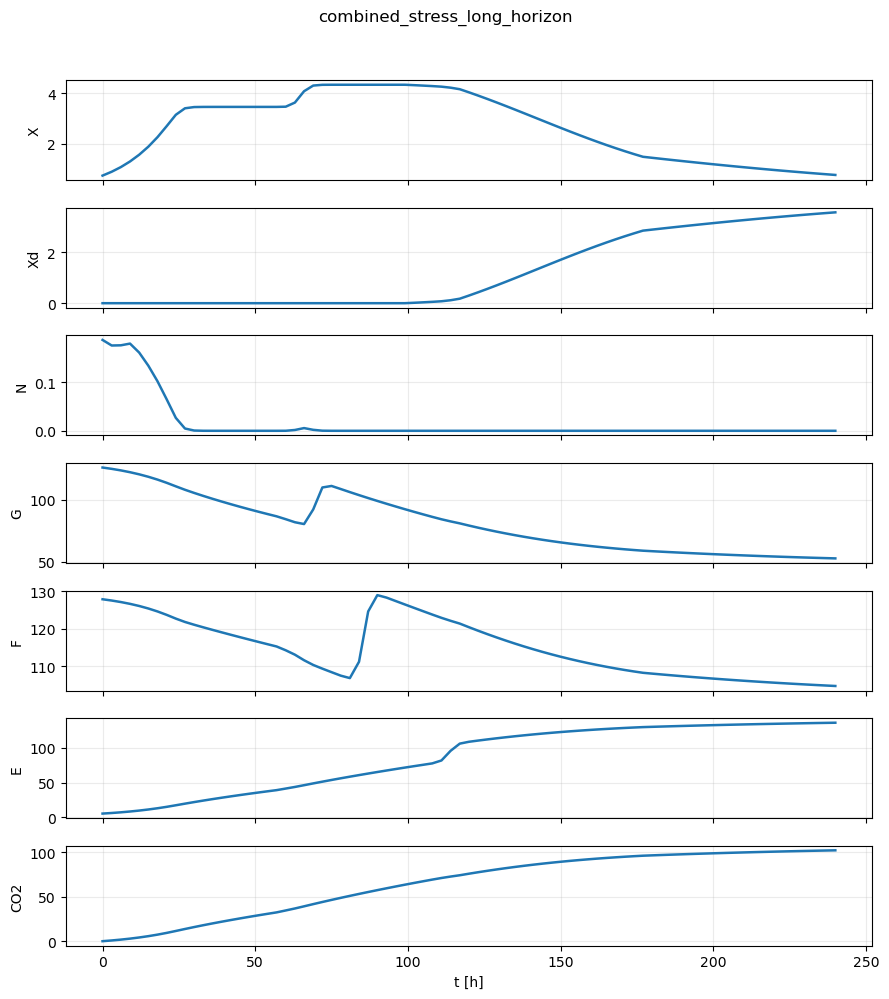

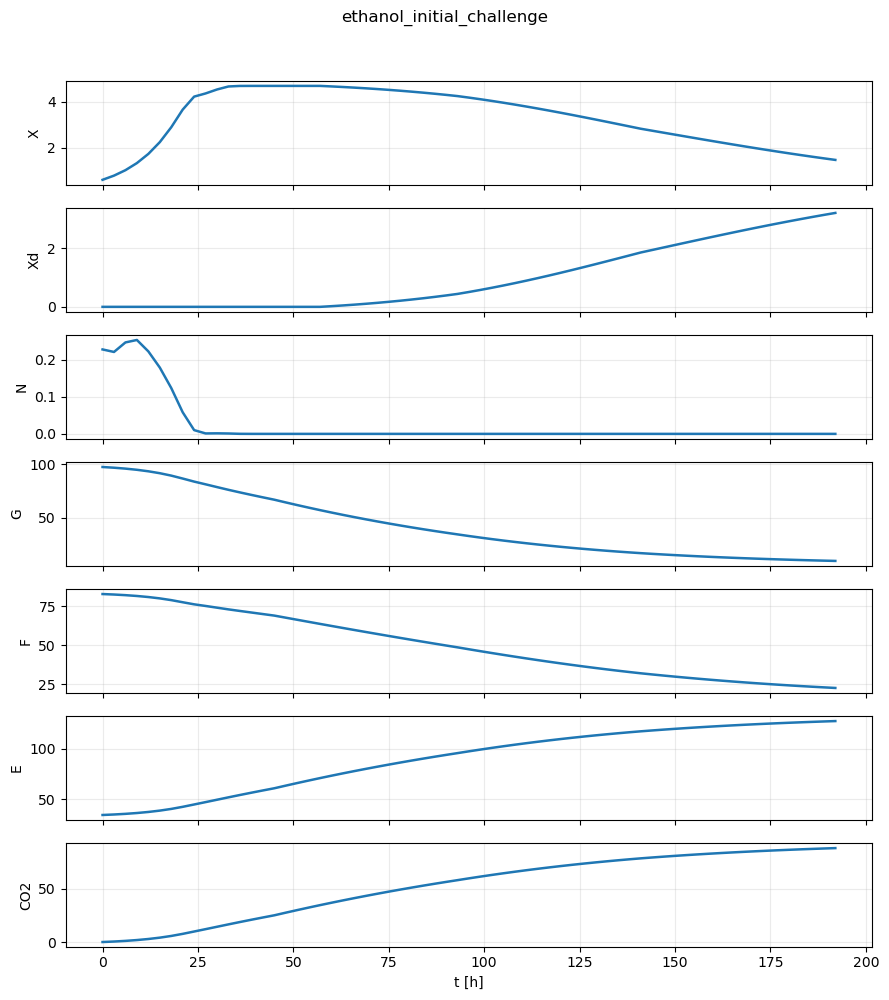

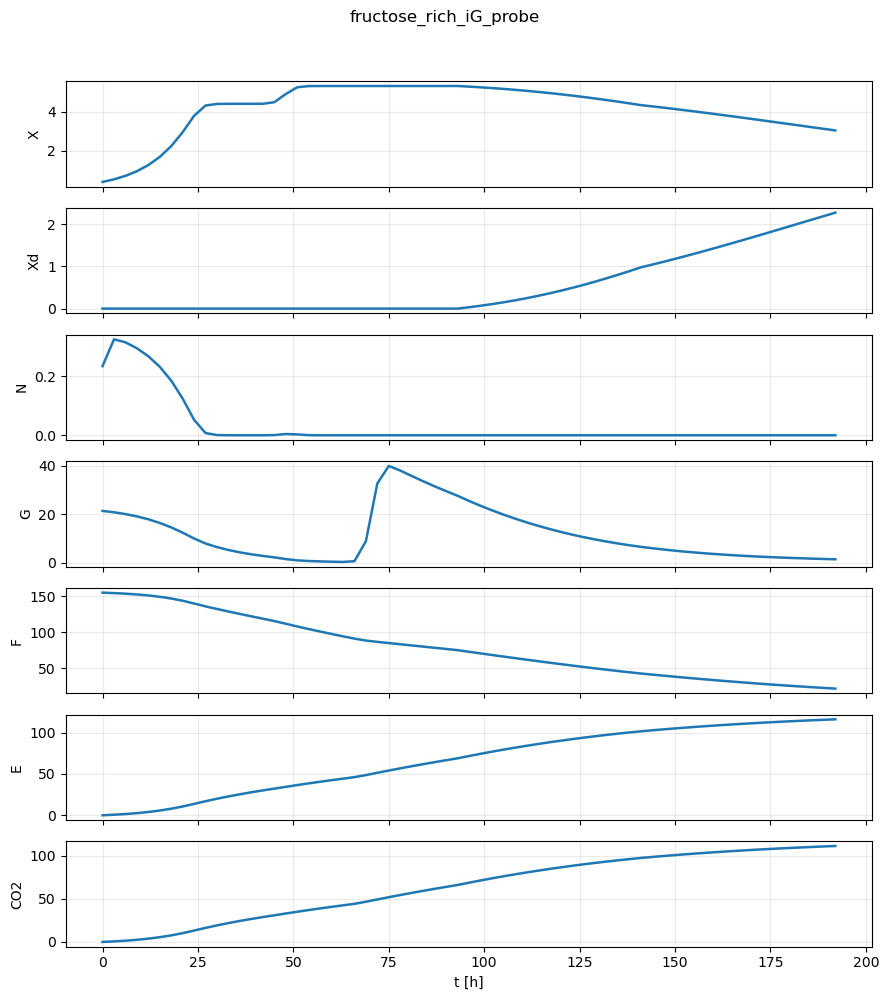

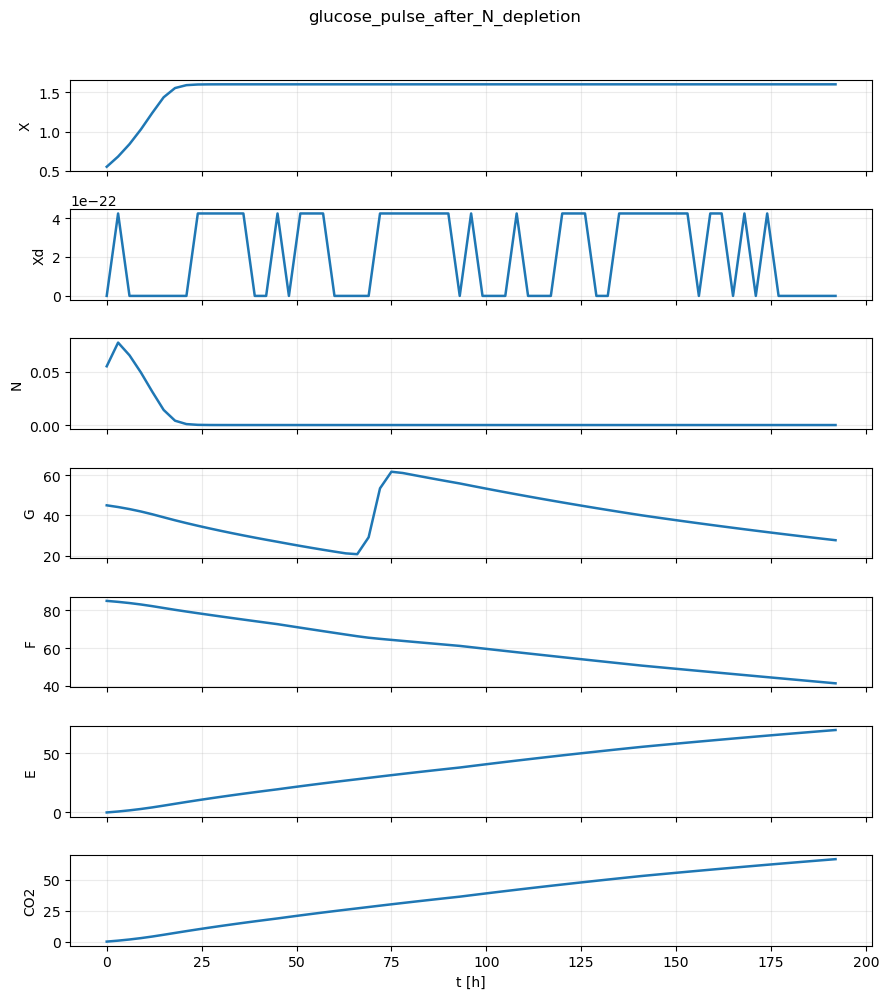

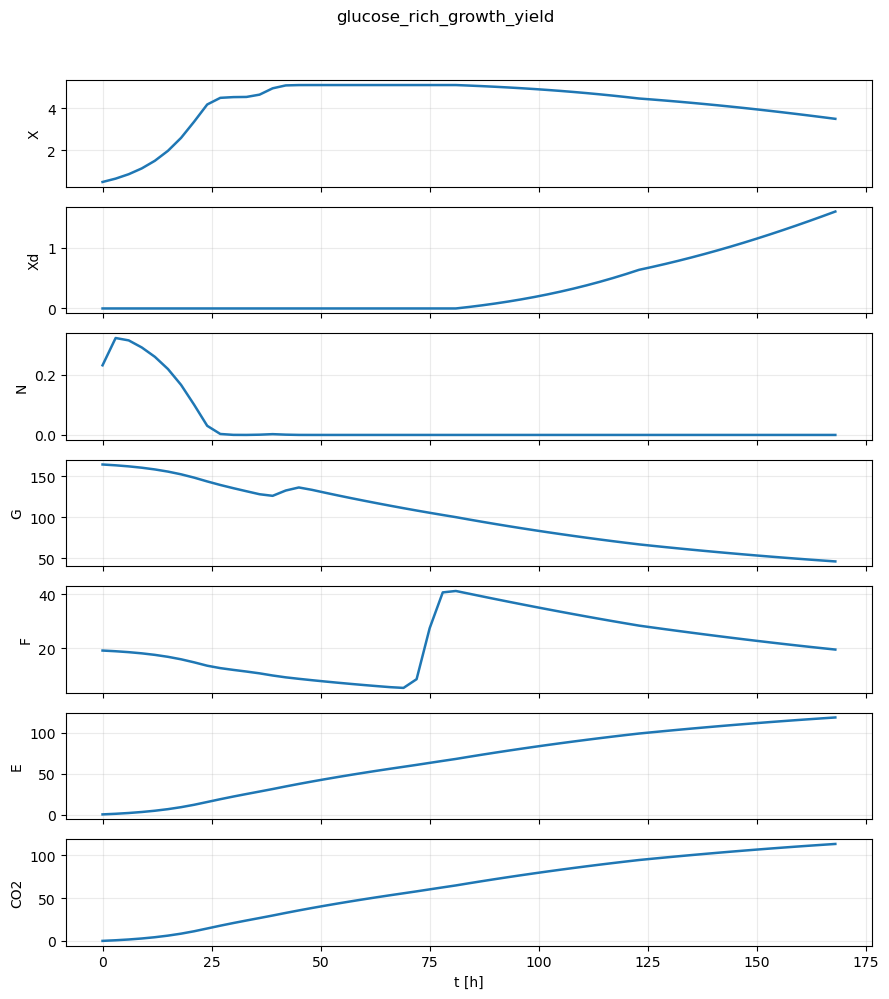

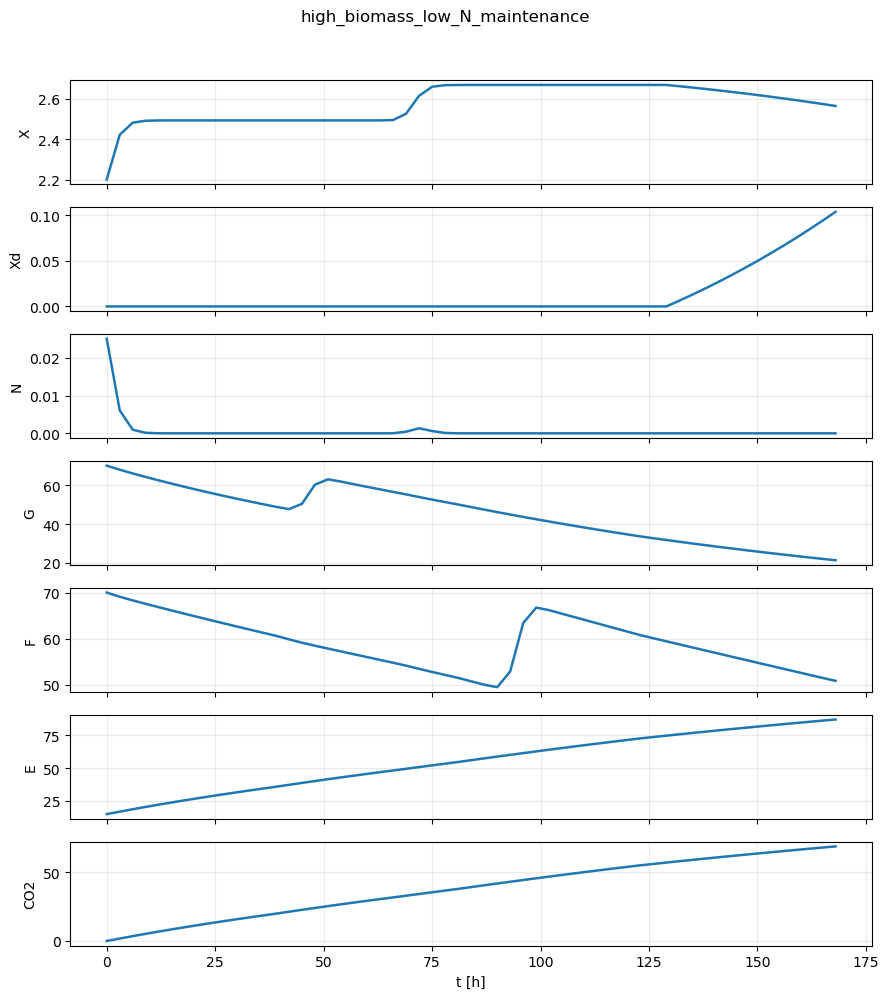

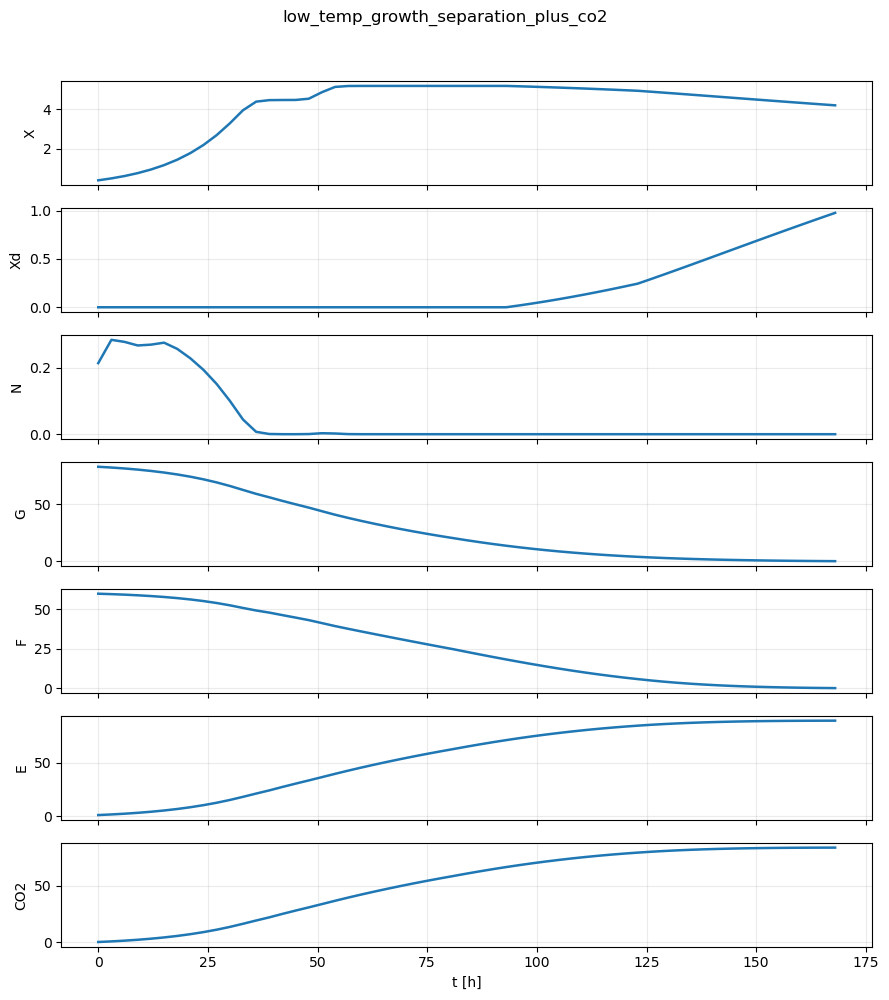

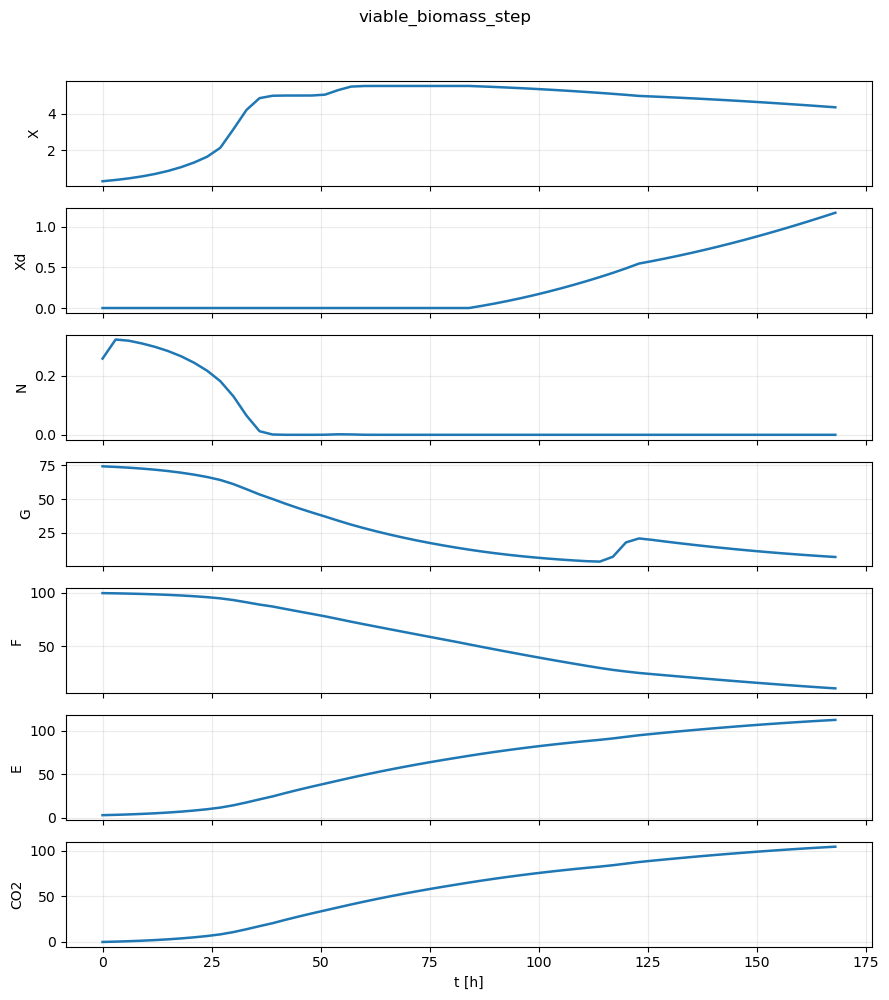

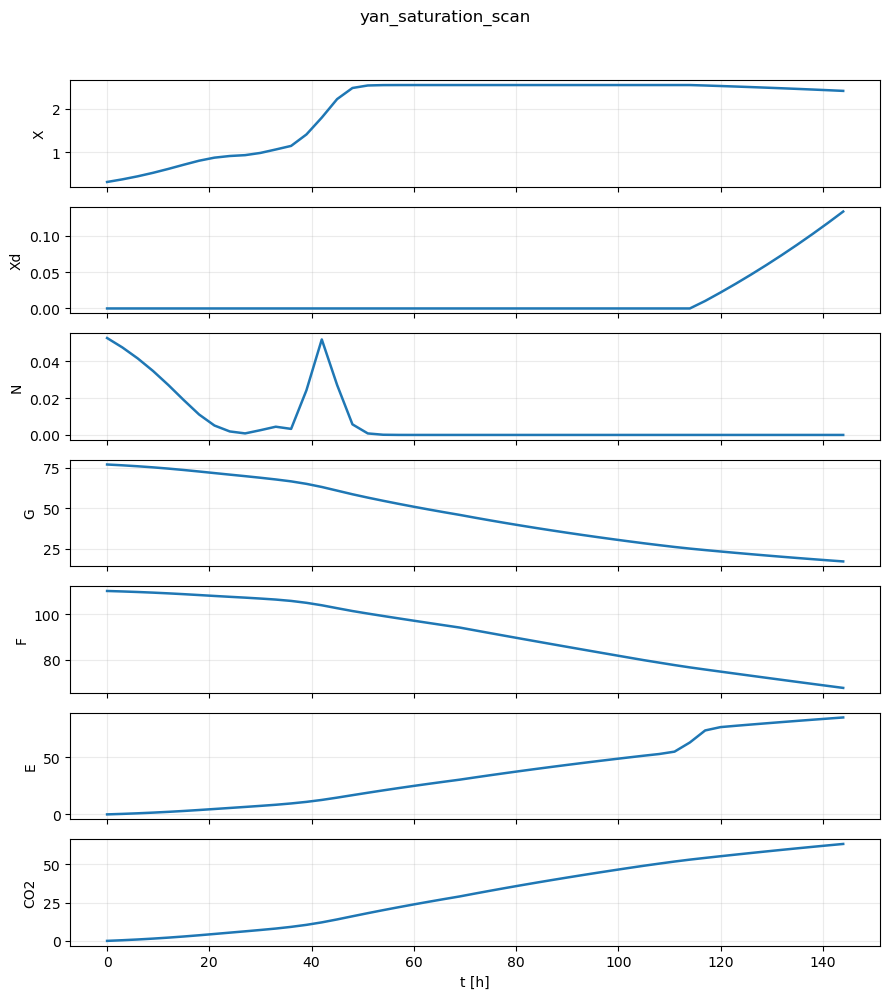

In [22]:

for candidate, group in refined_sim.groupby("candidate"):
    fig, axes = plt.subplots(len(states), 1, figsize=(9, 10), sharex=True)
    for ax, state in zip(axes, states):
        ax.plot(group["t"], group[state], lw=1.8)
        ax.set_ylabel(state)
        ax.grid(True, alpha=0.25)
    axes[-1].set_xlabel("t [h]")
    fig.suptitle(candidate, y=0.995)
    fig.tight_layout(rect=(0, 0, 1, 0.97))
    plt.show()



## 14. Decisi?n t?cnica actual

Con esta campa?a, el cuello de botella pr?ctico deja de ser tan severo: el peor par?metro corregible pasa de `sN` con reducci?n aproximada de varianza cercana a 0.62 en la campa?a inicial, a cerca de 0.77 en la campa?a refinada. La condici?n de la FIM tambi?n baja respecto de la campa?a original.

La decisi?n recomendada es ejecutar esta campa?a como dise?o experimental base para el siguiente ciclo. Despu?s de obtener datos reales, el flujo sigue siendo:

1. recalibrar con multi-start/PSO y ajuste local;
2. repetir FIM y ranking de correlaciones;
3. correr perfil likelihood sobre los par?metros liberables;
4. confirmar con aproximaci?n Bayes/Laplace o muestreo posterior si el perfil queda ambiguo.

La FIM predice estimabilidad local; no reemplaza el perfil likelihood con datos reales.
